# Setup

In [3]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

from src.utils import *
from src.config import np, plt, sp
import src.simulations as sim

a, p = sp.symbols('a p', real=True) # arrival and access probabilities symbols

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

thr = sp.factor(pi01*p + pi11*p*(1-p))



# L_up

q0, q1 = sp.symbols('q0 q1', real=True)

# 1. Definições auxiliares do Slotted ALOHA (2 nós)
s0 = p               # Sucesso do nó 1 se nó 2 está vazio
s1 = p * (1 - p)     # Sucesso do nó 1 se nó 2 está cheio
s_neighbor = p * (1 - p)  # Sucesso do nó 2 se nó 1 está cheio (simetria)

# 2. Montando o sistema de equações
# q0 = s0 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# Se não houve chegada 'a' no nó 1, o pacote atual continua.
# Se não houve sucesso 's0', ele permanece no buffer.
eq1 = sp.Eq(q0, s0 + (1 - a) * (1 - p) * ((1 - a) * q0 + a * q1))

# q1 = s1 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# No estado 1, o vizinho pode ter sucesso (s_neighbor) e não chegar pacote novo para ele (1-a)
cont_prob_1 = (1 - a) * (1 - p * (1 - p))
trans_to_q0 = p * (1 - p) * (1 - a)
eq2 = sp.Eq(q1, p * (1 - p) + cont_prob_1 * (trans_to_q0 * q0 + (1 - trans_to_q0) * q1))

# 3. Resolvendo o sistema
solucao = sp.solve((eq1, eq2), (q0, q1))

# Simplificando os resultados
q0_expr = sp.simplify(solucao[q0])
q1_expr = sp.simplify(solucao[q1])

L_up_expr = sp.simplify(pi10*q0_expr + pi11*q1_expr)


# PAoI e AAoI

PAoI_expr = sp.simplify( (L_up_expr + 1) / thr)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
print(sp.simplify_logic(-2*a**2 + a**3 + a**2*p - p*a**3))
print("\\frac {", str(sp.simplify(-2*a**2 + a**3 + a**2*p - p*a**3)).replace("**", "^").replace("*", "").replace("/", "}{"), "}")

-a**3*p + a**3 + a**2*p - 2*a**2
\frac { a^2(-ap + a + p - 2) }


In [74]:
print(str(sp.factor((2*a**2 - a**3 + 4*a*p - 7*a**2*p + 3*a**3*p + 2*p**2 - 10*a*p**2 + 12*a**2*p**2 - 4*a**3*p**2 - 2*p**3 + 6*a*p**3 - 6*a**2*p**3 + 2*a**3*p**3)*pi10)))

-a*p*(a - 2)*(a - 1)*(p - 1)


In [138]:
c = 2*a**2 - a**3 + 4*a*p - 7*a**2*p + 3*a**3*p + 2*p**2 - 10*a*p**2 + 12*a**2*p**2 - 4*a**3*p**2 - 2*p**3 + 6*a*p**3 - 6*a**2*p**3 + 2*a**3*p**3

# Throughput

In [2]:
thr = sp.factor(pi01*p + pi11*p*(1-p))
throughput_data = np.load("data/throughput_data.npy")

In [81]:
print("\\frac {", str(thr*c).replace("**", "^").replace("*", "").replace("/", "}{"), "}")

\frac { -ap(p - 1)(2a^2p - a^2 - 4ap + 2a + 2p) }


In [63]:
# ~ 20 s
throughput_data = simulate_metric(
    sim.throughput,
    time=200000,
    method="numpy",
    name ="throughput_data"
    )

Dados salvos em 'data/throughput_data.npy'.


In [128]:
np.shape(throughput_data)

(50, 49)

In [147]:
teste_thr = make_metric_func(thr)
teste_thr_data = make_metric_func(throughput_data)
print(teste_thr_data(0.00, 0.00))
print(throughput_data[-1, -1])

0.01952
0.01952


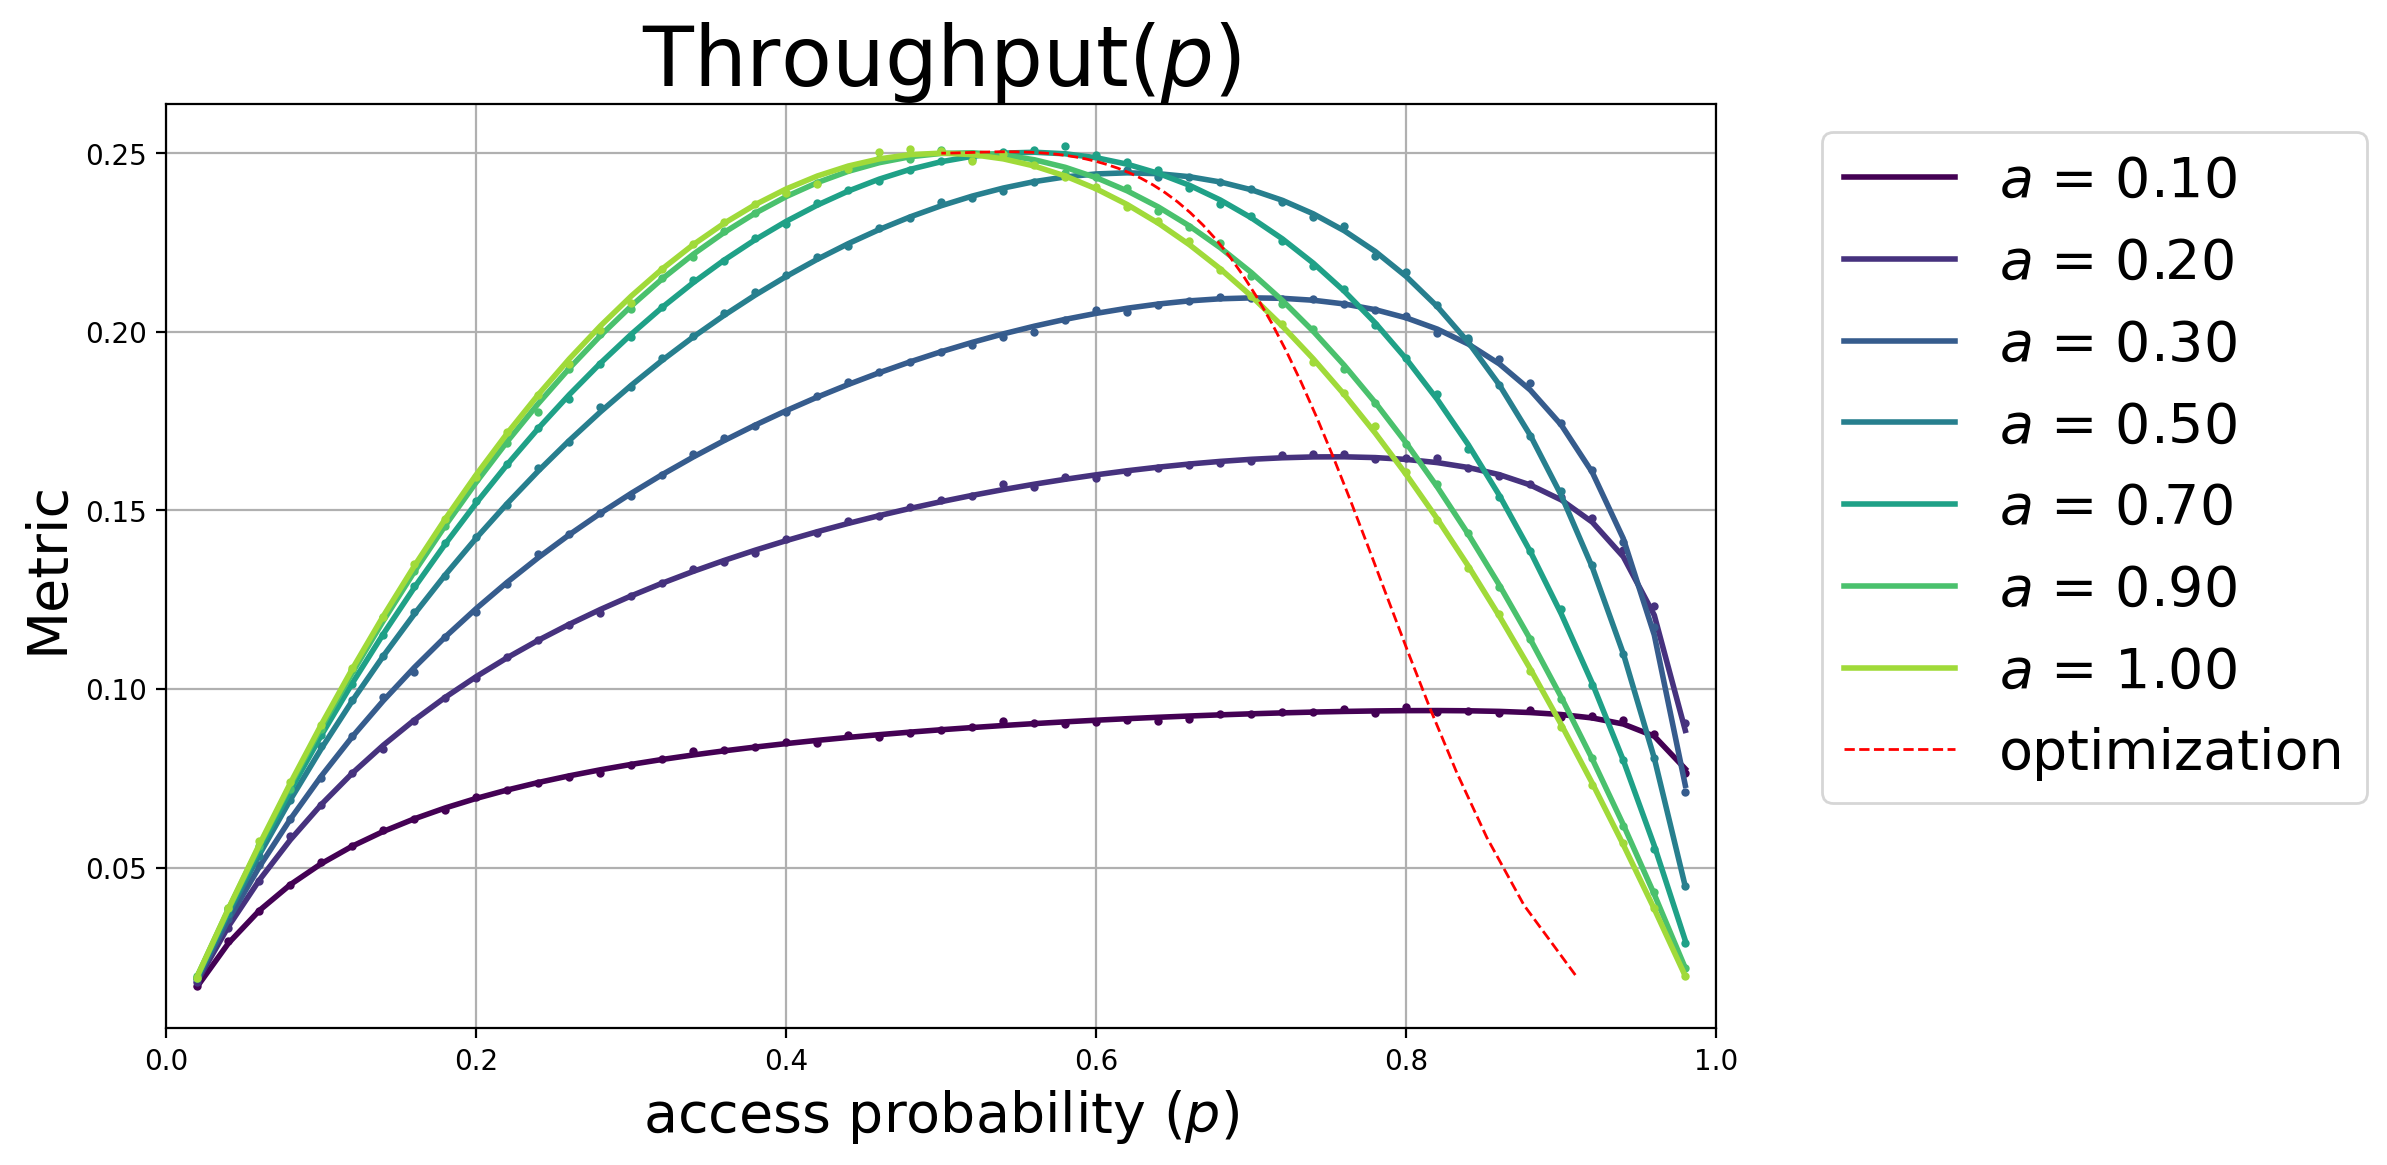

In [144]:
compare_metric_plot(
    analytical_expr=thr,
    simulation_data=throughput_data,
    title="Throughput($p$)",
    cmap="viridis",
    axis="p",
    find_max=True
)

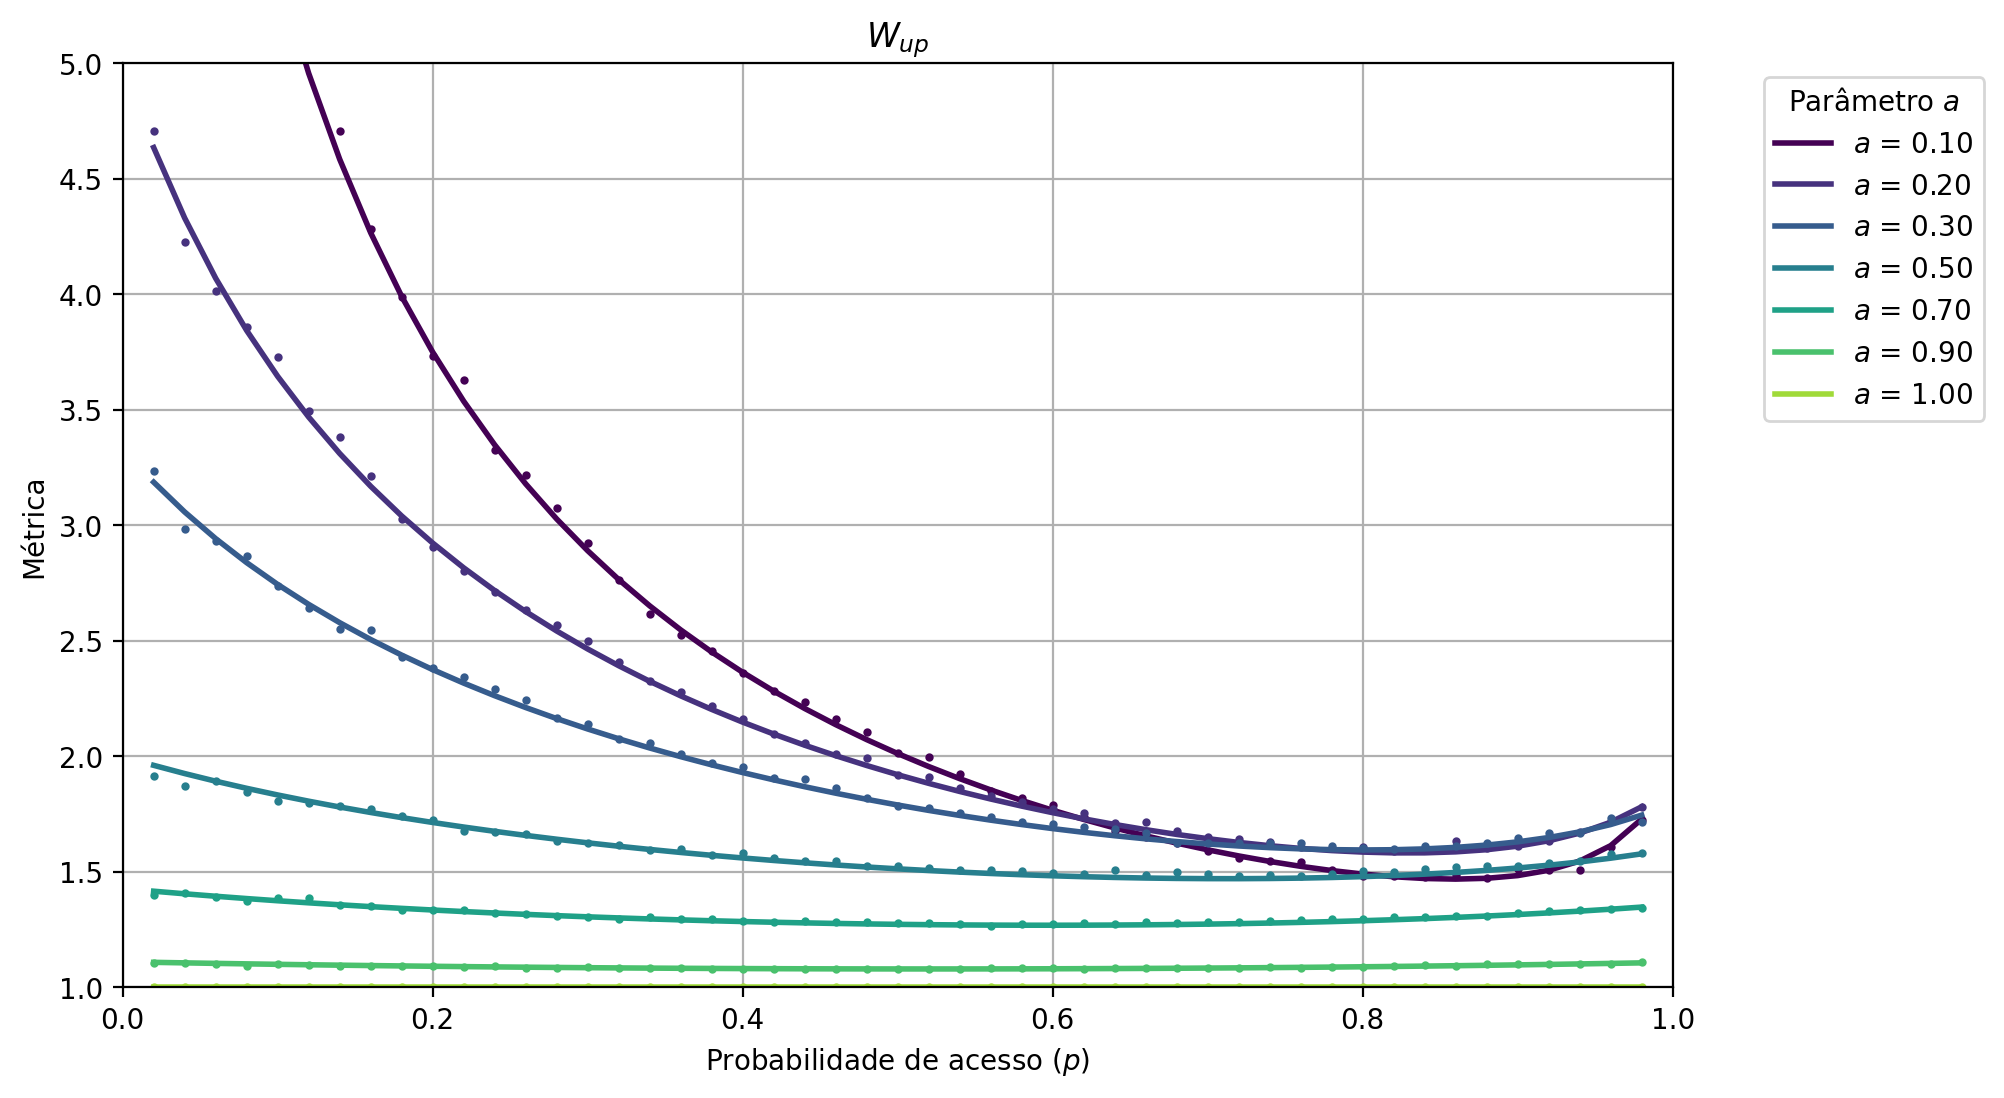

In [41]:
compare_metric_plot(
    analytical_expr=L_up_expr/thr,
    simulation_data=np.load('data/mean_delay_up_pack_data.npy'),
    title="$W_{up}$",
    yrange=(1, 5)
)

# L_up

In [33]:
q0, q1 = sp.symbols('q0 q1', real=True)

# 1. Definições auxiliares do Slotted ALOHA (2 nós)
s0 = p               # Sucesso do nó 1 se nó 2 está vazio
s1 = p * (1 - p)     # Sucesso do nó 1 se nó 2 está cheio
s_neighbor = p * (1 - p)  # Sucesso do nó 2 se nó 1 está cheio (simetria)

# 2. Montando o sistema de equações
# q0 = s0 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# Se não houve chegada 'a' no nó 1, o pacote atual continua.
# Se não houve sucesso 's0', ele permanece no buffer.
eq1 = sp.Eq(q0, s0 + (1 - a) * (1 - p) * ((1 - a) * q0 + a * q1))

# q1 = s1 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# No estado 1, o vizinho pode ter sucesso (s_neighbor) e não chegar pacote novo para ele (1-a)
cont_prob_1 = (1 - a) * (1 - p * (1 - p))
trans_to_q0 = p * (1 - p) * (1 - a)
eq2 = sp.Eq(q1, p * (1 - p) + cont_prob_1 * (trans_to_q0 * q0 + (1 - trans_to_q0) * q1))

# 3. Resolvendo o sistema
solucao = sp.solve((eq1, eq2), (q0, q1))

# Simplificando os resultados
q0_expr = sp.simplify(solucao[q0])
q1_expr = sp.simplify(solucao[q1])

L_up_expr = sp.simplify(pi10*q0_expr + pi11*q1_expr)
L_up_expr

a*p*(-a*(a*p - a - p + 2)*(a**2*p**4 - 2*a**2*p**3 + 3*a**2*p**2 - 3*a**2*p + a**2 - 2*a*p**4 + 4*a*p**3 - 6*a*p**2 + 6*a*p - 2*a + p**4 - 2*p**3 + 3*p**2 - 2*p) + p*(a**2*p - a**2 - 3*a*p + 3*a + 2*p - 2)*(a**2*p**4 - 2*a**2*p**3 + 3*a**2*p**2 - 3*a**2*p + a**2 - 2*a*p**4 + 4*a*p**3 - 6*a*p**2 + 5*a*p - 2*a + p**4 - 2*p**3 + 3*p**2 - 2*p))/((2*a**3*p**3 - 4*a**3*p**2 + 3*a**3*p - a**3 - 6*a**2*p**3 + 12*a**2*p**2 - 7*a**2*p + 2*a**2 + 6*a*p**3 - 10*a*p**2 + 4*a*p - 2*p**3 + 2*p**2)*(a**3*p**5 - 3*a**3*p**4 + 5*a**3*p**3 - 5*a**3*p**2 + 3*a**3*p - a**3 - 3*a**2*p**5 + 8*a**2*p**4 - 13*a**2*p**3 + 13*a**2*p**2 - 7*a**2*p + 2*a**2 + 3*a*p**5 - 7*a*p**4 + 11*a*p**3 - 10*a*p**2 + 4*a*p - p**5 + 2*p**4 - 3*p**3 + 2*p**2))

# AAoI e PAoI pela simulação de W_up
AAoI = W_up + 2/thr - 1     ( F )  

PAoI = W_up + 1/thr         ( V )

In [24]:
AAoI_sim_data, PAoI_sim_data = simulate_metric(sim.AAoI_PAoI_sim, time=500000, method="numpy")
np.save("data/AAoI_sim_data.npy", AAoI_sim_data)
np.save("data/PAoI_sim_data.npy", PAoI_sim_data)

KeyboardInterrupt: 

In [22]:
AAoI_sim_data = np.load("data/AAoI_sim_data.npy")
AAoI_sim_func = make_metric_func(AAoI_sim_data)
PAoI_sim_data = np.load("data/PAoI_sim_data.npy")
PAoI_sim_func = make_metric_func(PAoI_sim_data)
mean_delay_up_pack_data = np.load("data/mean_delay_up_pack_data.npy")

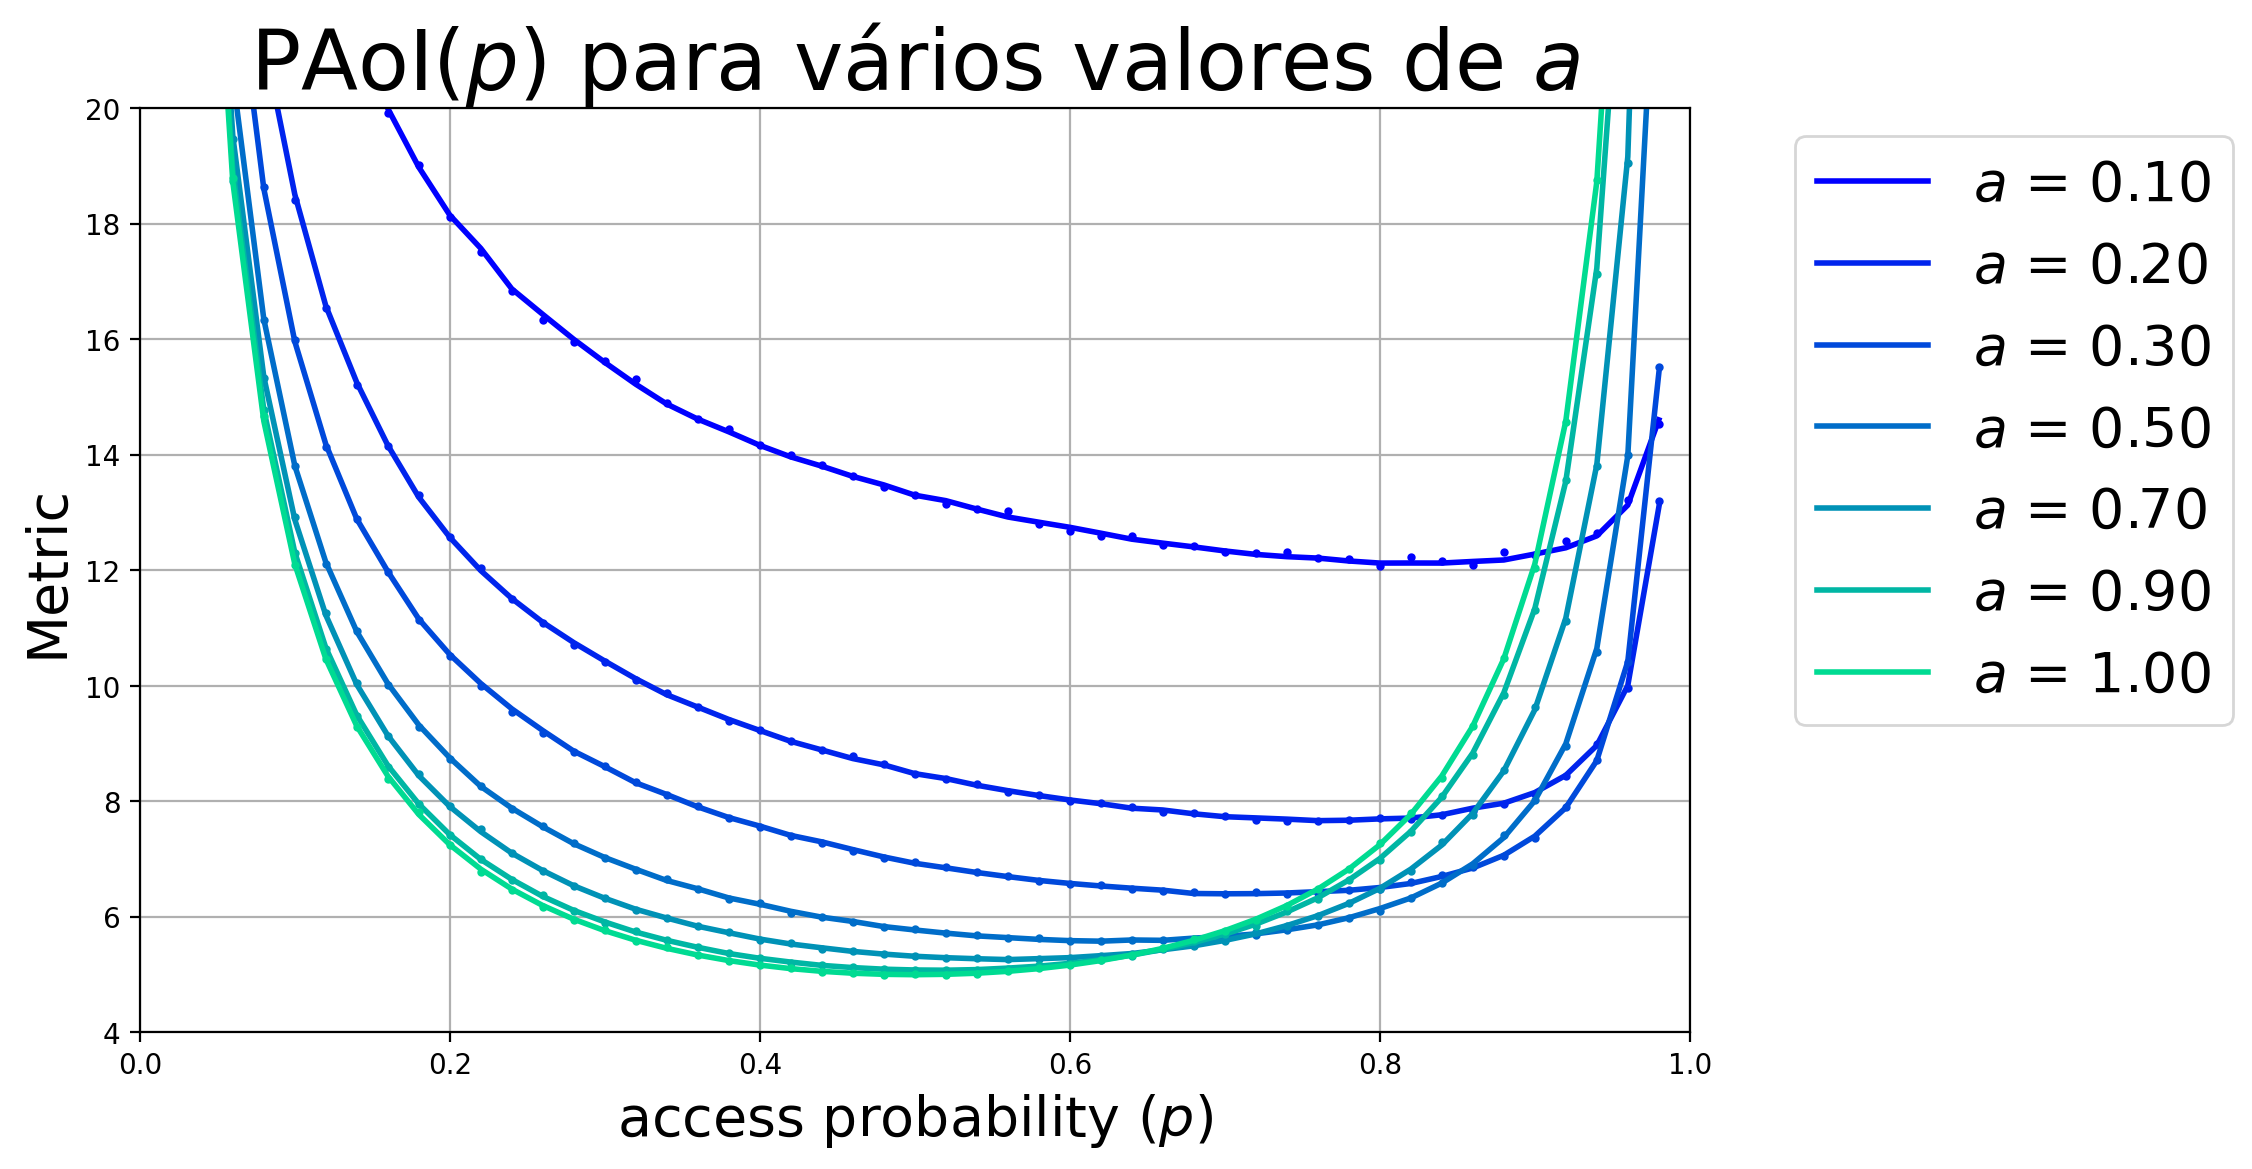

In [8]:
thr_func = make_metric_func(thr)

W_up_sim_func = make_metric_func(mean_delay_up_pack_data)

PAoI_W_up_teste = np.vectorize(lambda a, p: W_up_sim_func(a, p) + 1 / thr_func(a, p))
plot_metric(
    analytical_func = PAoI_W_up_teste,
    simulation_data_func = PAoI_sim_func,
    title="PAoI($p$) para vários valores de $a$",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
)

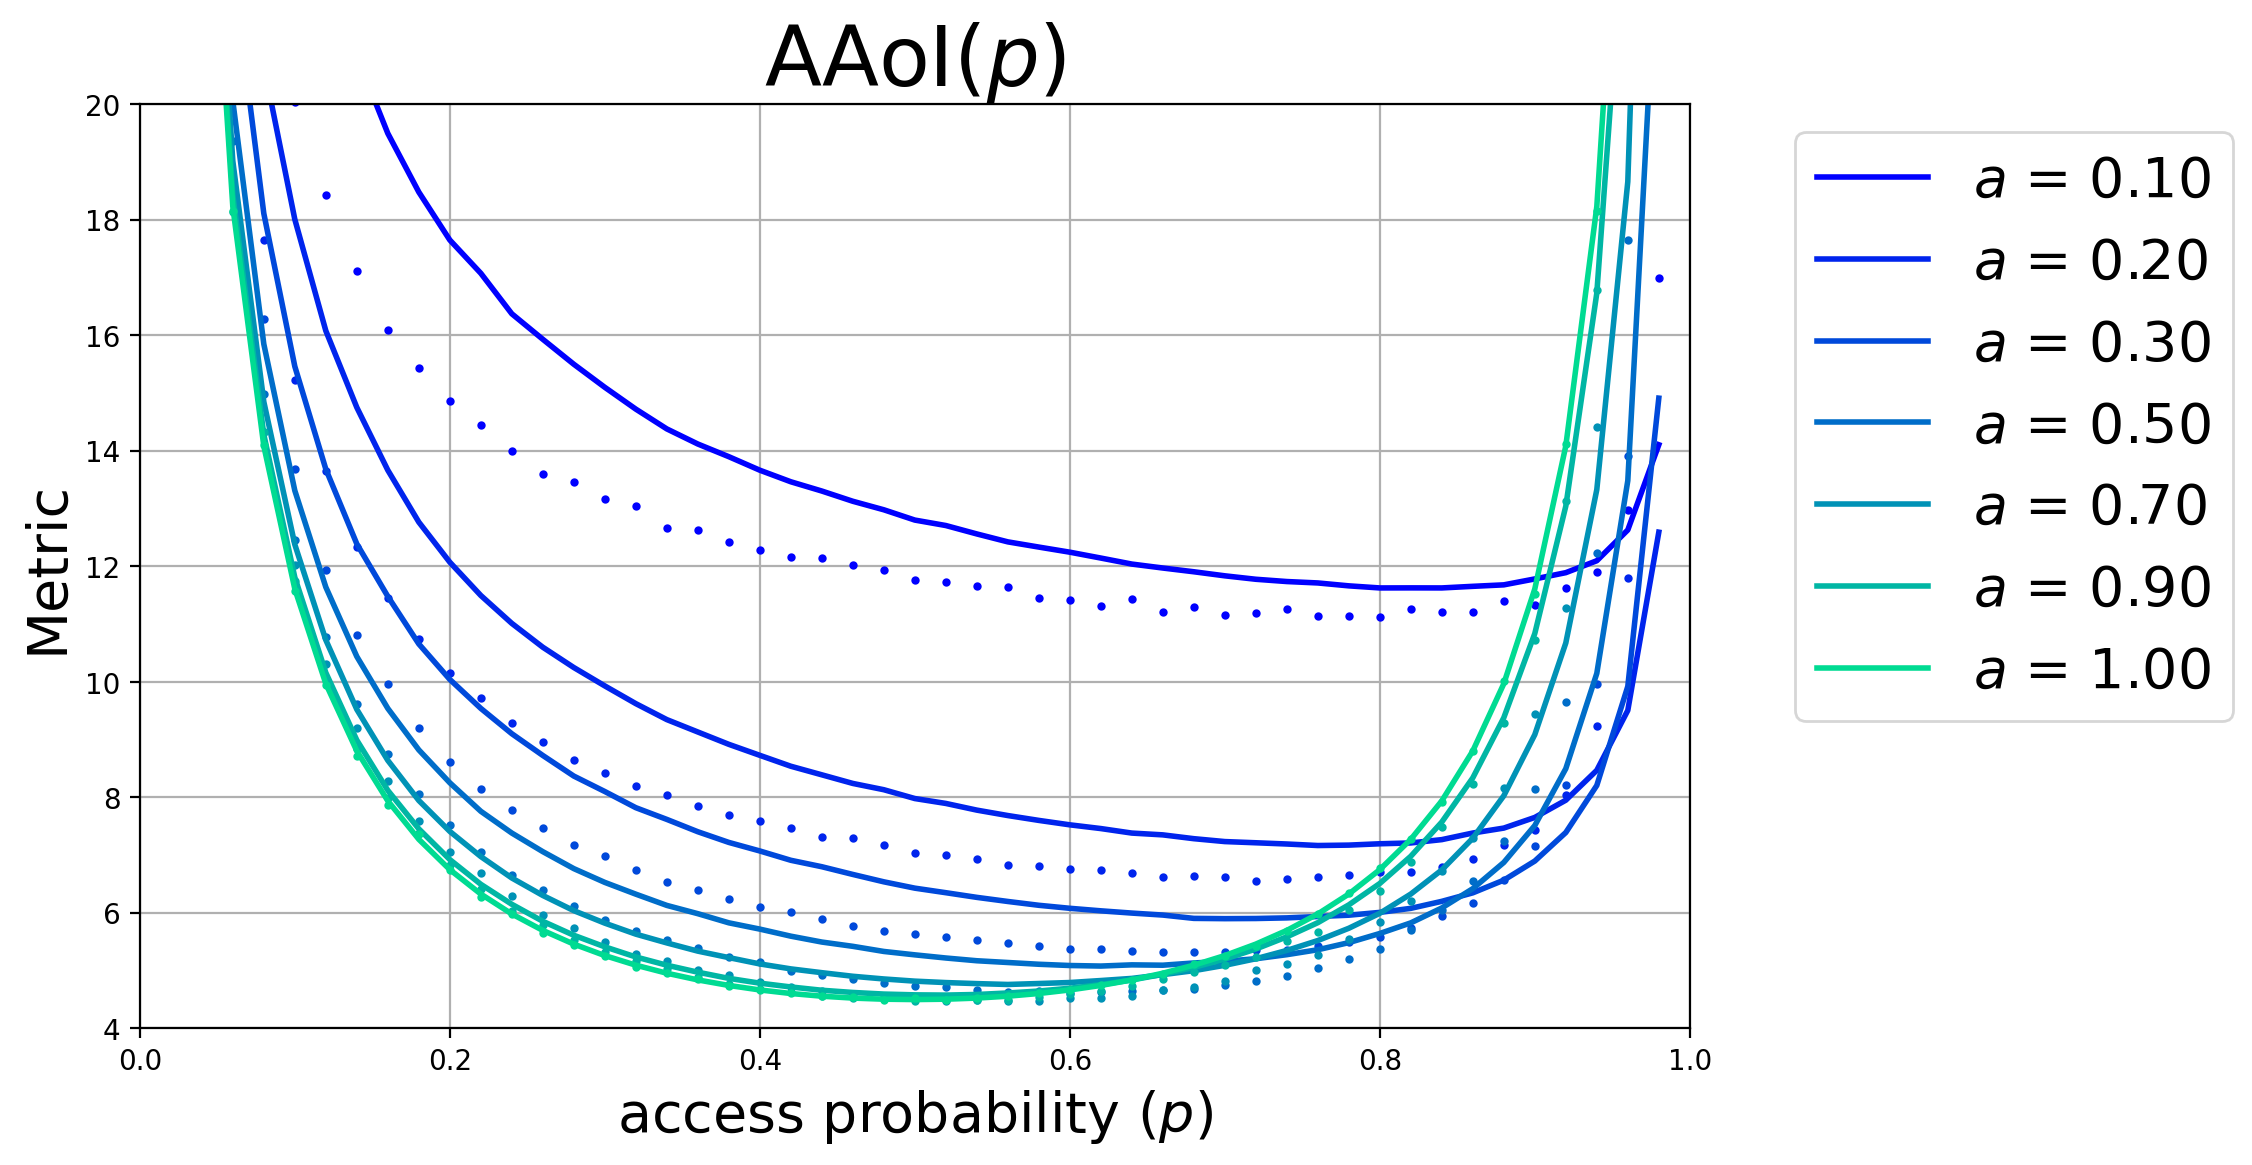

In [9]:
AAoI_W_up_teste = np.vectorize(lambda a, p: W_up_sim_func(a, p) + 1 / thr_func(a, p) - 1/2)
plot_metric(
    analytical_func = AAoI_W_up_teste,
    simulation_data_func = AAoI_sim_func,
    title="AAoI($p$)",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
) 

# AAoI e PAoI

## Aproximação de AAoI considerando $W_{up}=1$

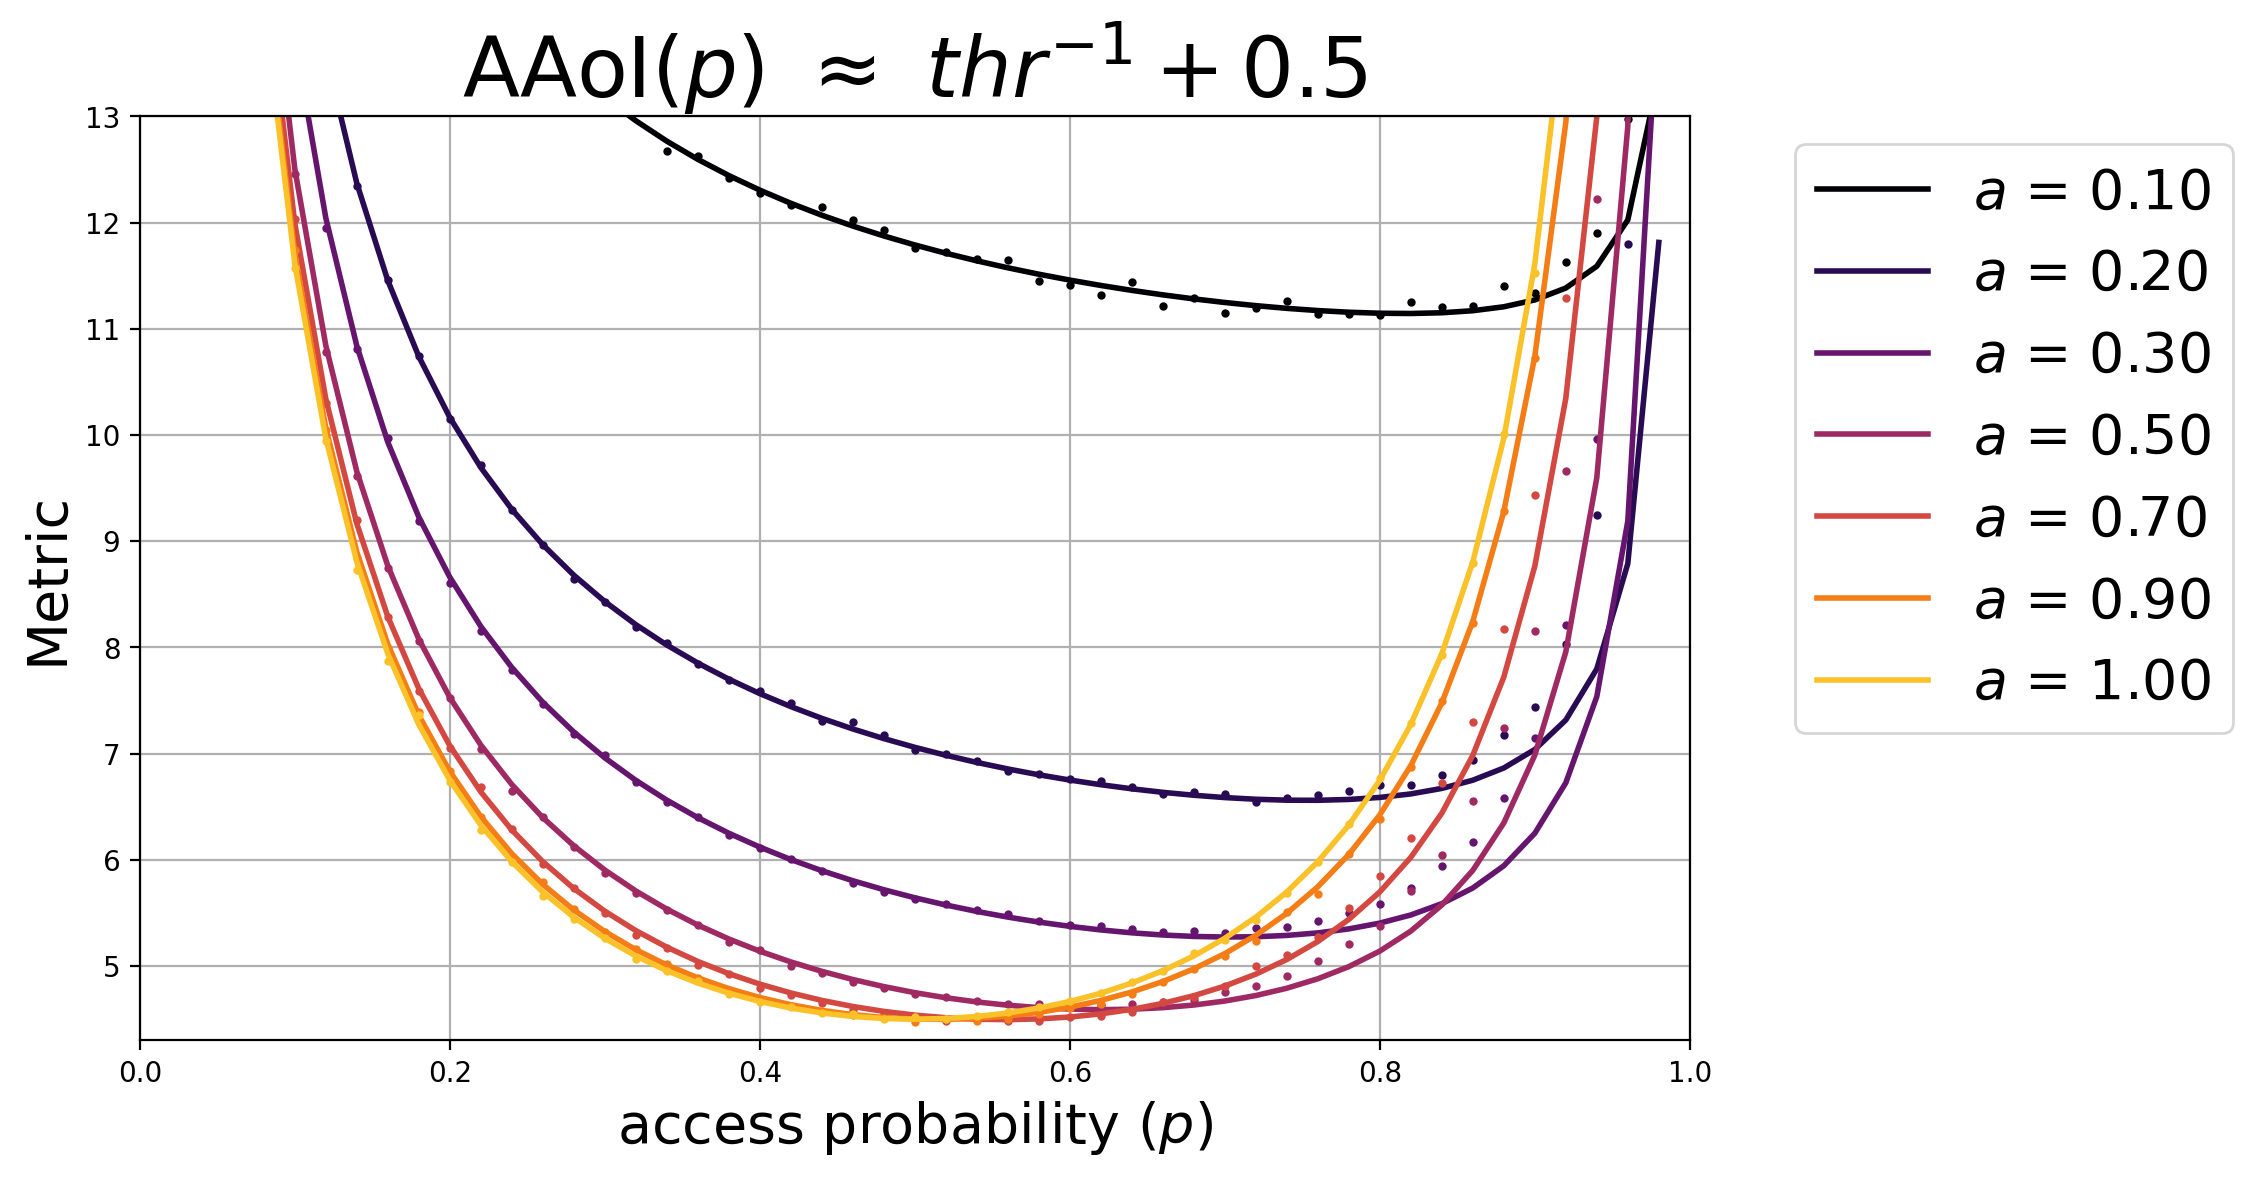

In [10]:
AAoI_expr_a1 = sp.simplify( 1 / thr + 0.5 )
compare_metric_plot(
    analytical_expr=AAoI_expr_a1,
    simulation_data=AAoI_sim_data,
    title=r"AAoI$(p)\ \approx \ thr^{-1} + 0.5$",
    cmap="inferno",
    axis="p",
    yrange = (4.3, 13)
)

## Expressão correta para PAoI

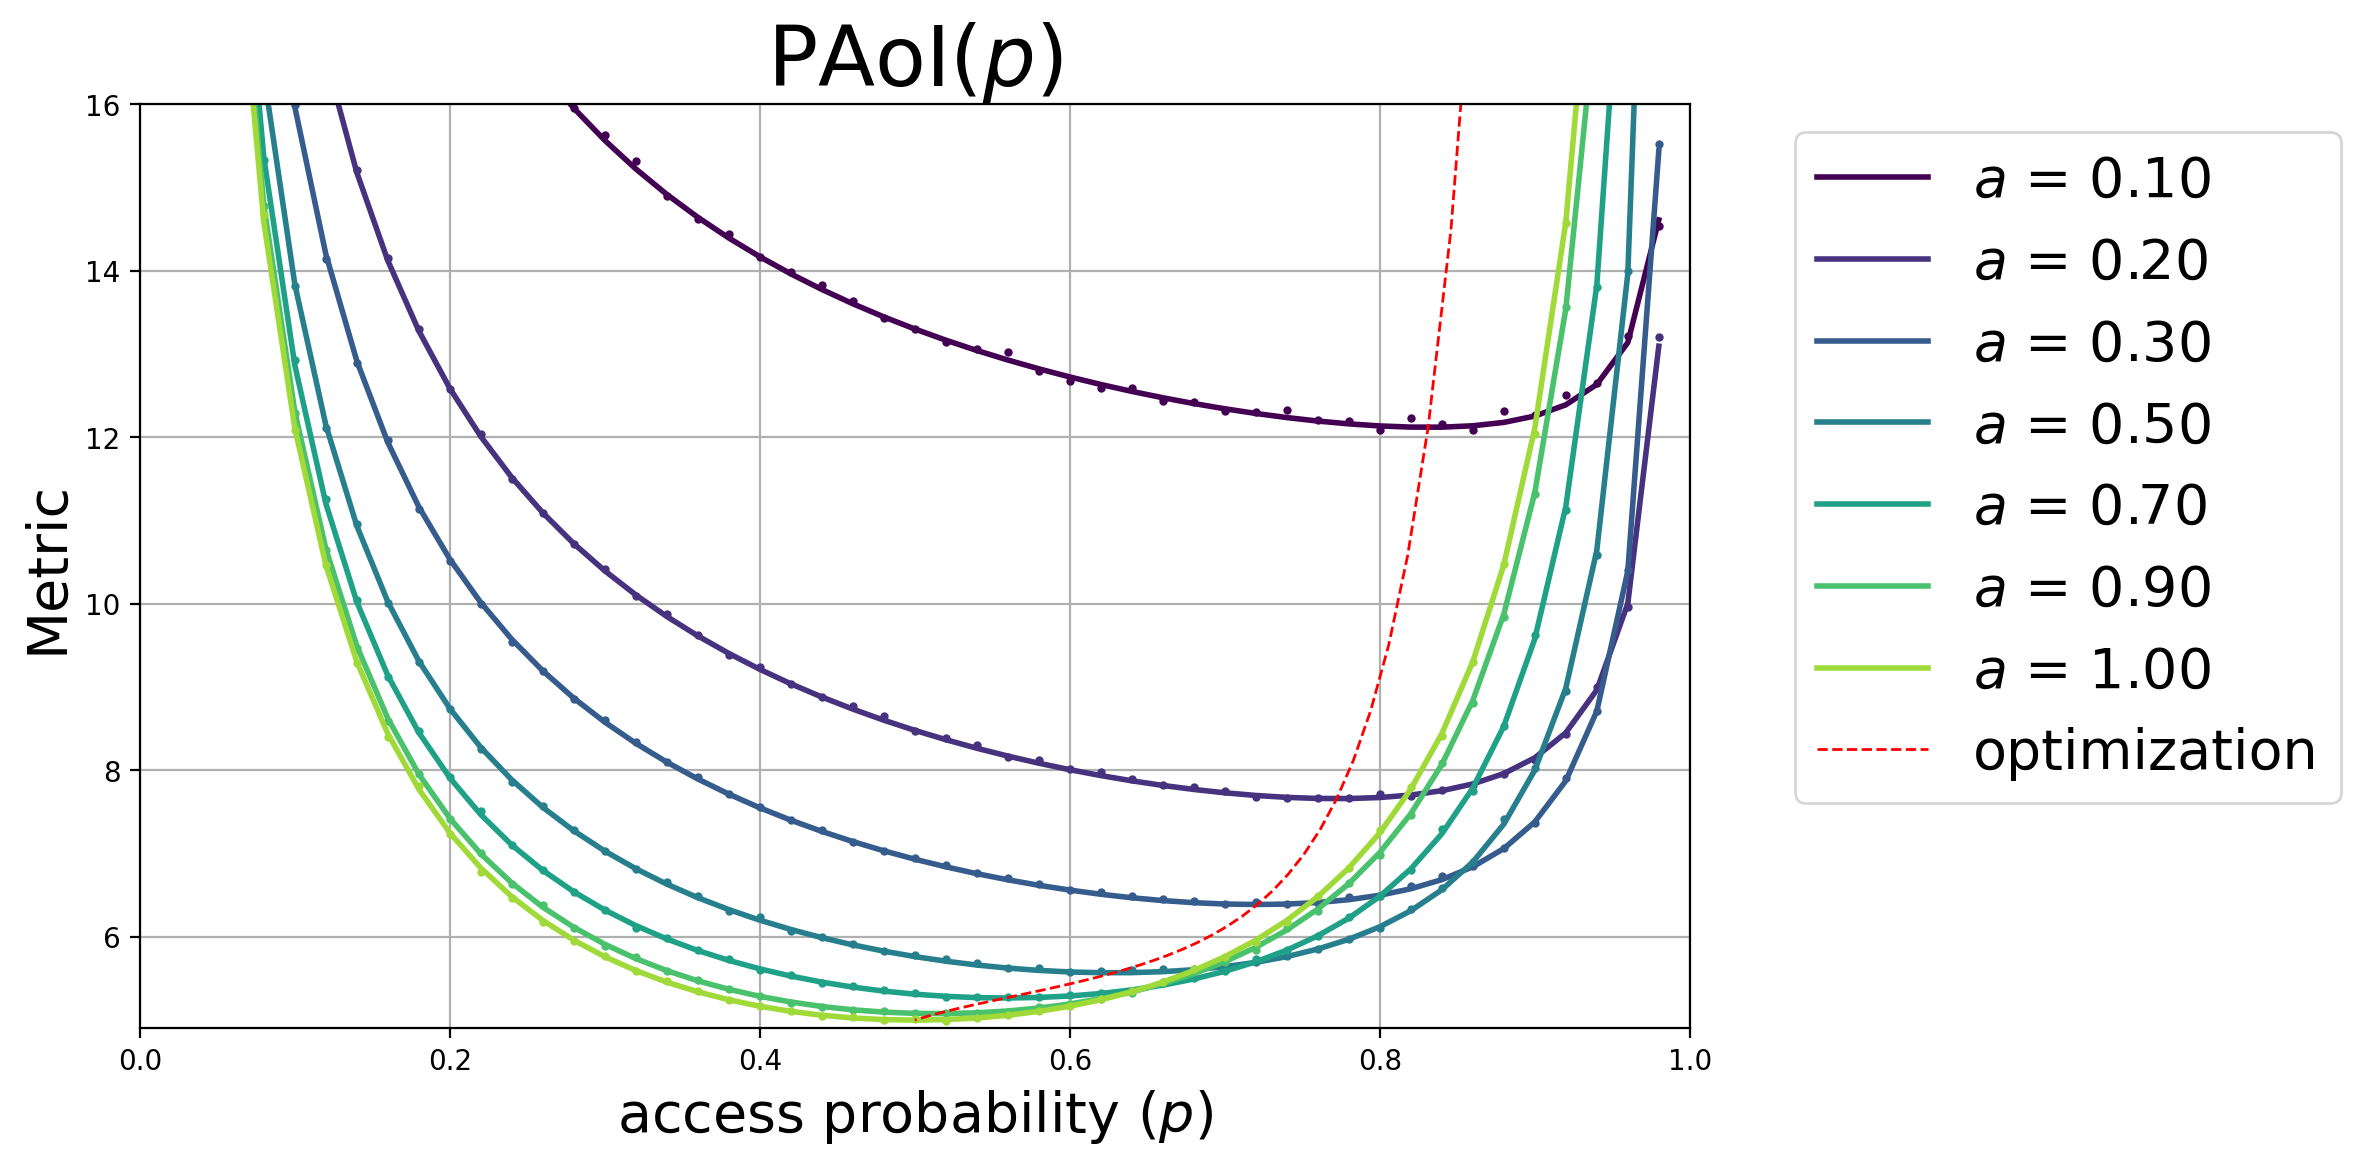

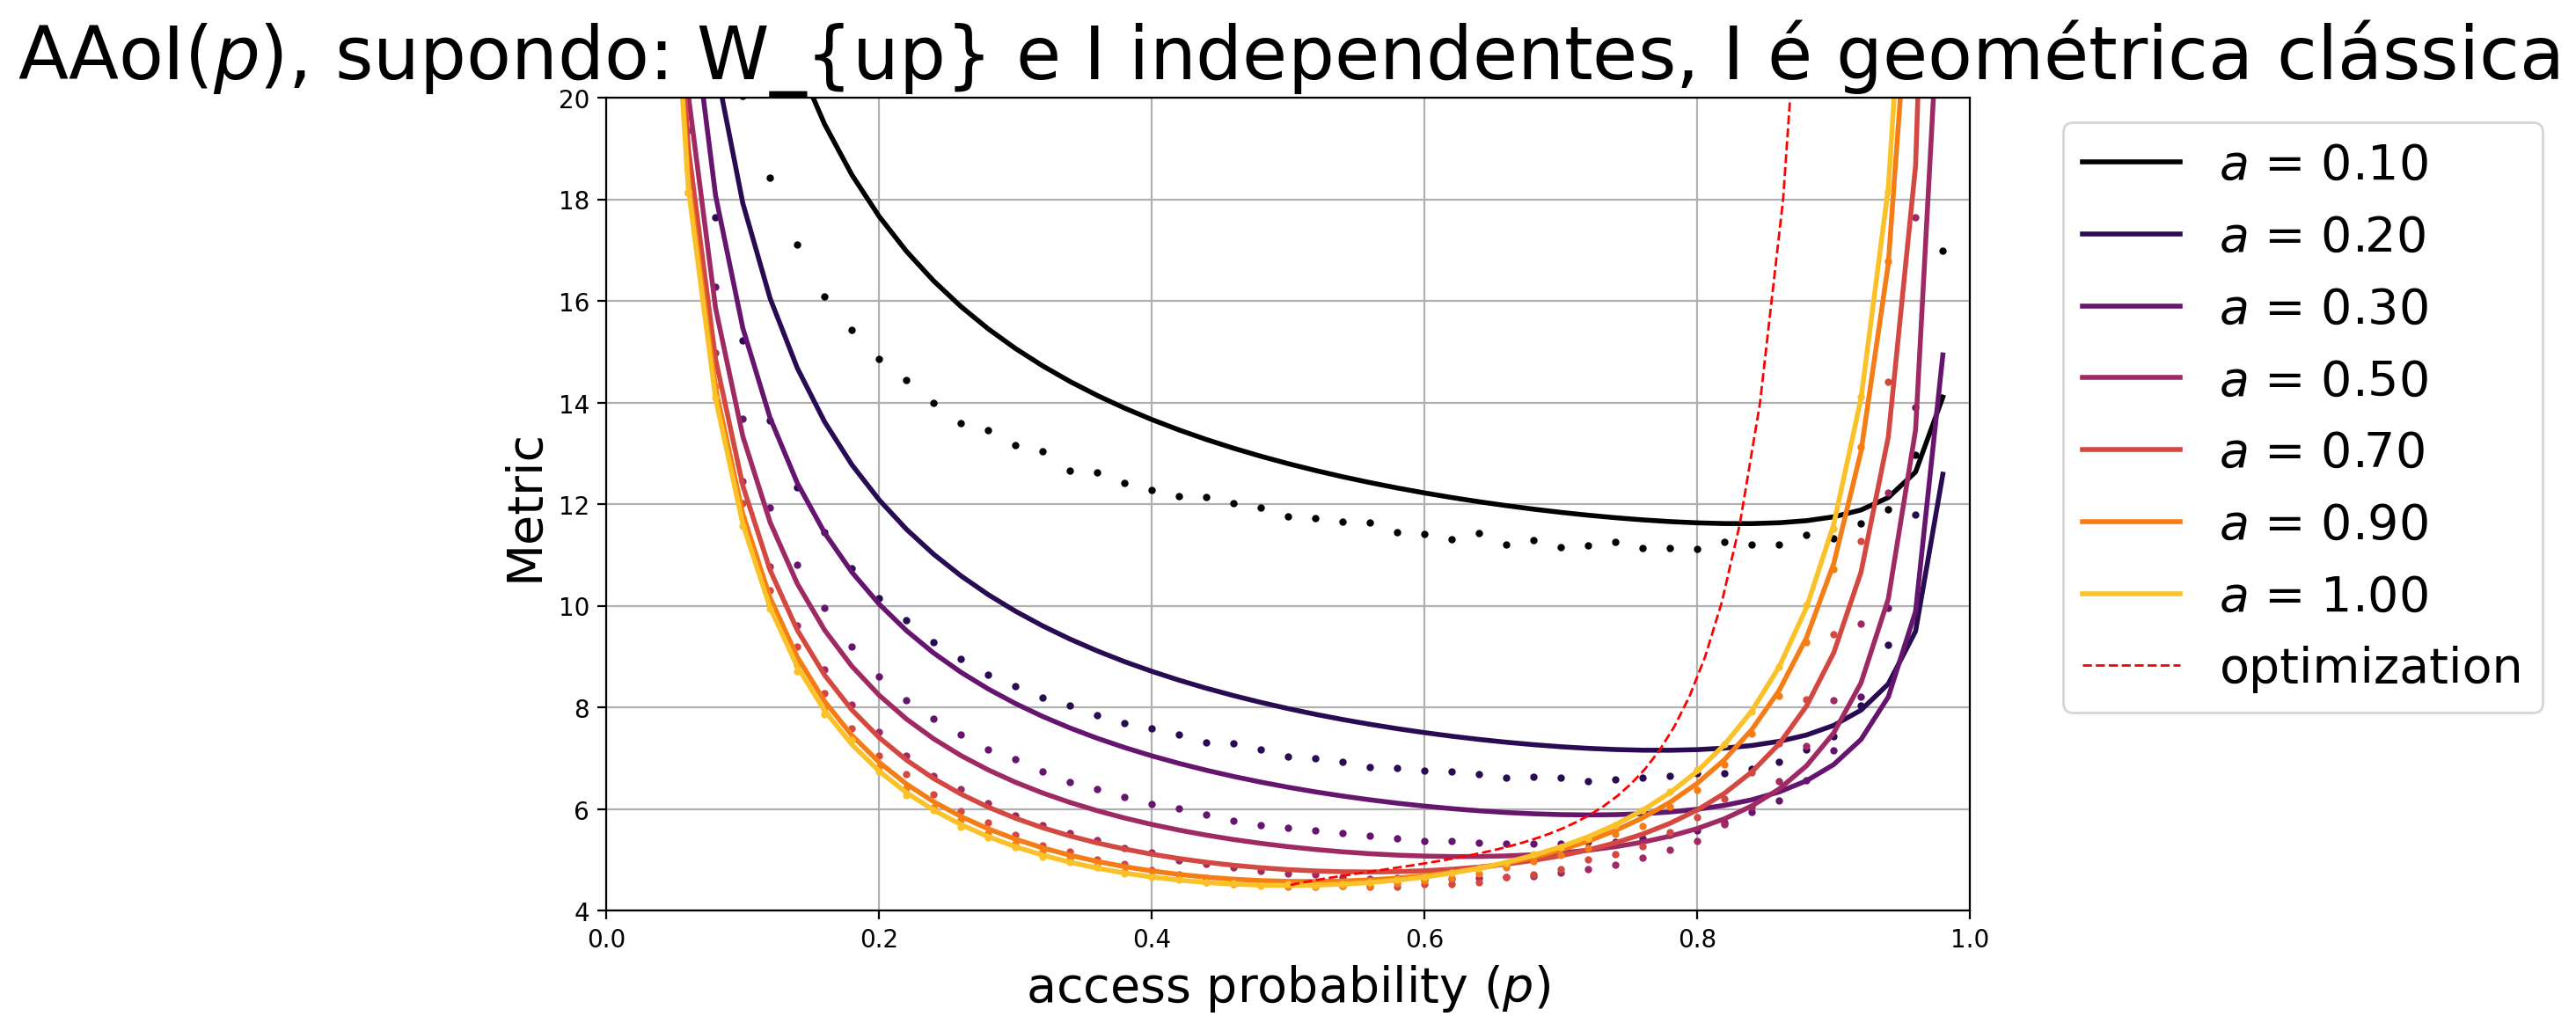

In [43]:
# PAoI = L_up / thr + 1 / thr = (L_up + 1) / thr
# thr = thr/2
PAoI_expr = sp.simplify( (L_up_expr + 1) / thr)
# PAoI_expr = sp.simplify( (W_up) + (2 / thr))
AAoI_expr = sp.simplify( (L_up_expr + 1) / thr - 1/2)
compare_metric_plot(
    analytical_expr=PAoI_expr,
    simulation_data=PAoI_sim_data,
    title="PAoI($p$)",
    cmap="viridis",
    axis="p",
    yrange=(4.9, 16)
)
compare_metric_plot(
    analytical_expr=AAoI_expr,
    simulation_data=AAoI_sim_data,
    title="AAoI($p$), supondo: W_{up} e I independentes, I é geométrica clássica",
    cmap="inferno",
    axis="p",
    yrange=(4, 20)
) 

# Hipótese de relação entre L_up e thr

## L_up

In [15]:
L_tot = pi01 + pi11
taxa_desc = pi01 * a * (1 - p) + pi11 * a * (1 - p + p**2)  # validado por simulação.
L_up_expr = sp.simplify(L_tot*( thr / a ))

L_up_sim_data = np.load("data/L_up_sim_data.npy")

In [167]:
L_up_sim_data = simulate_metric(sim.occupation_up_pack, time=200000, method="numpy")
np.save("data/L_up_sim_data.npy", L_up_sim_data)

KeyboardInterrupt: 

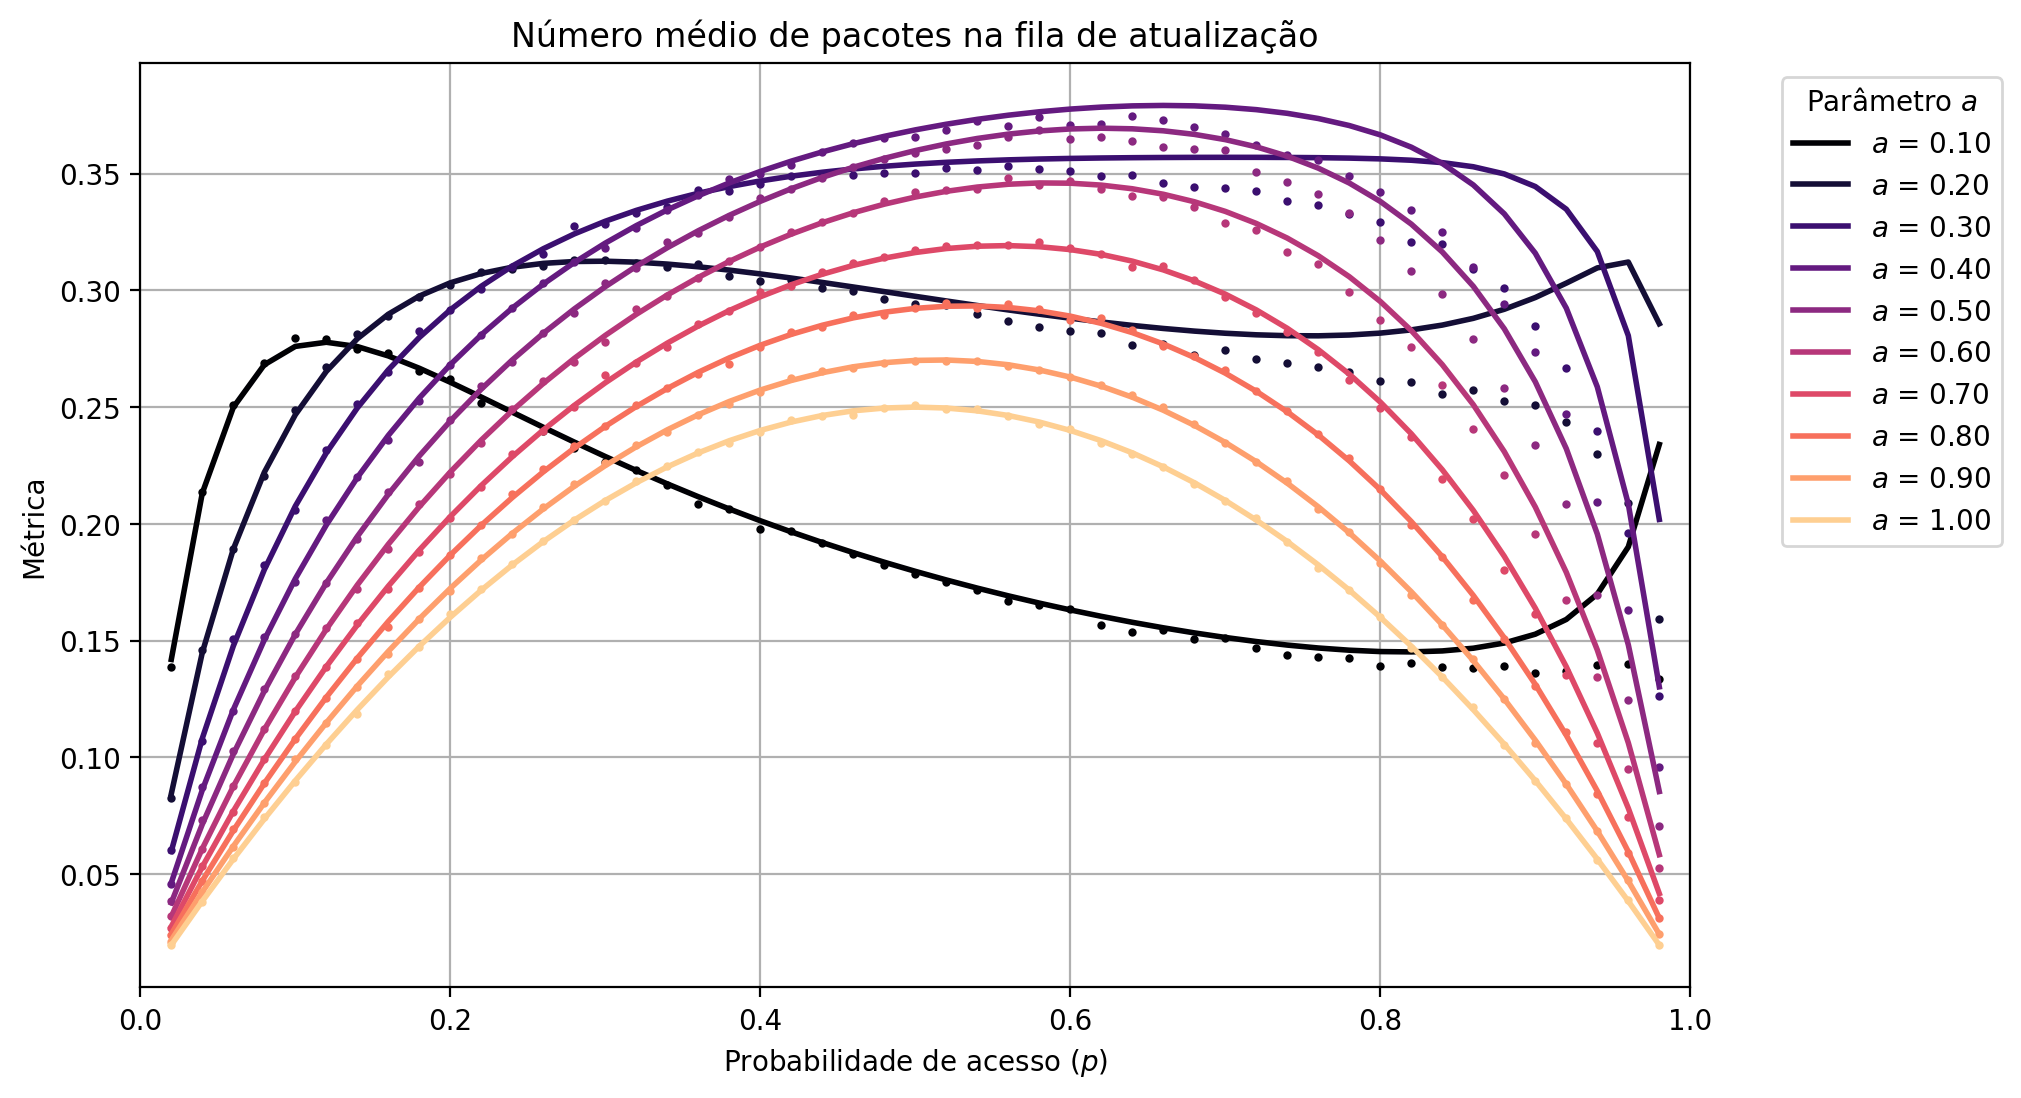

In [168]:
compare_metric_plot(
    analytical_expr=L_up_expr,
    simulation_data=L_up_sim_data,
    title="Número médio de pacotes na fila de atualização",
    cmap="magma",
    axis="p",
    # yrange=(.15, .4)
)

# True value of E[$W_{up} \cdot I$]

In [106]:
def Lambert_W_I(j=1):
    p = (1-a)
    q = (1-thr)
    # qp = (1-a)*(1-thr)
    soma = sp.sympify(0)
    
    for i in range(1, j+1):
        soma += q*p**i / (1 - q*p**i)**2
        # soma += soma
    return soma

In [ ]:
W_up_cdot_I = np.vectorize(lambda a, p: AAoI_sim_func(a, p)/thr_func(a, p) - (2 - thr_func(a, p)) /2 /thr_func(a, p)**2)

In [18]:
sim.W_up_cdot_I(0.5,0.5,10000)

7.103032820938928

In [ ]:
simulate_metric(
    metric_func = sim.W_up_cdot_I,
    time = 100000,
    name = "W_up_cdot_I",
    method="numpy"
    )

Dados salvos em 'data/W_up_cdot_I.npy'.


In [107]:
W_up_cdot_I_sim_data = np.load("data/W_up_cdot_I.npy")
# W_up_cdot_I_expr = sp.simplify(L_up_expr / thr**2)
W_up_cdot_I_expr = Lambert_W_I(30)

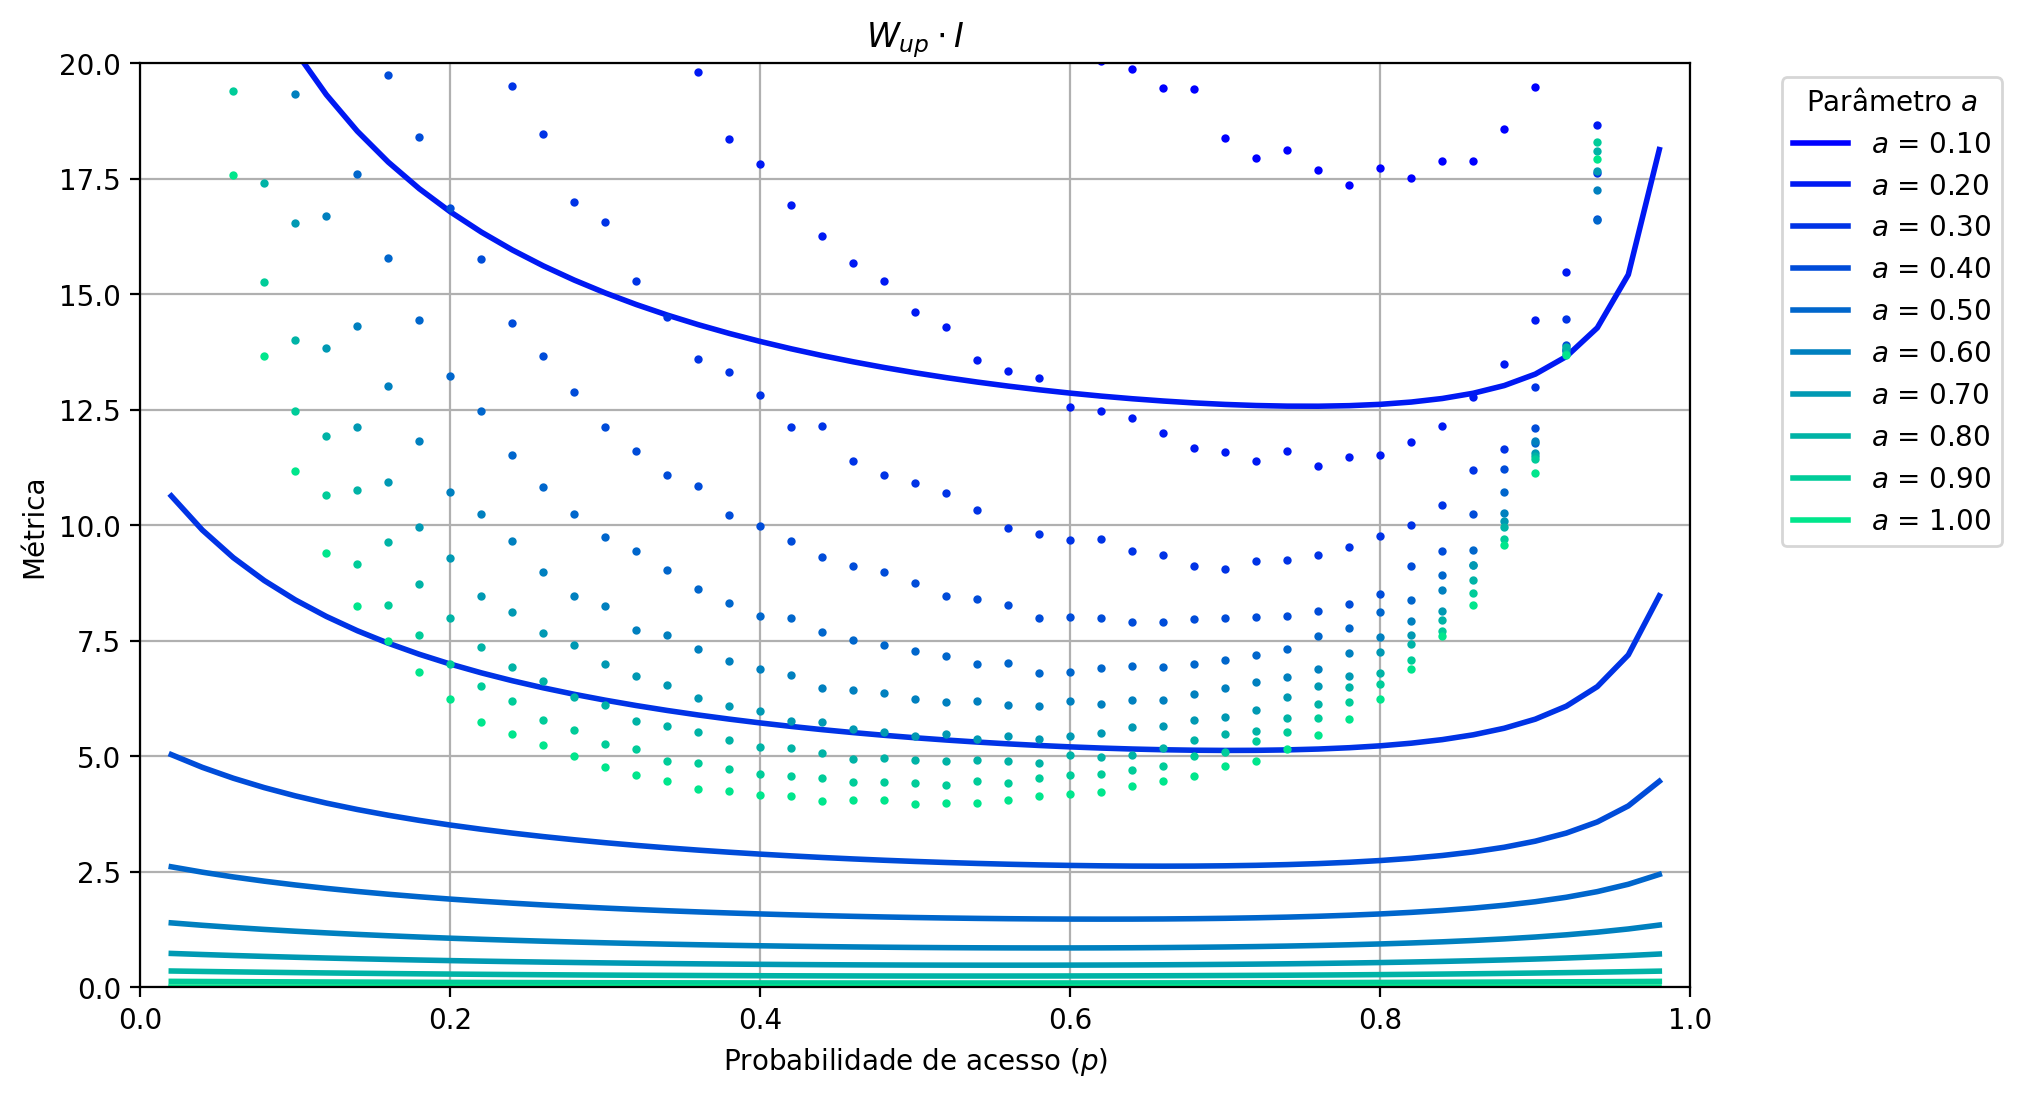

In [108]:
compare_metric_plot(
    analytical_expr = W_up_cdot_I_expr,
    simulation_data = W_up_cdot_I_sim_data,
    title="$W_{up}\cdot I$",
    cmap="winter",
    axis="p",
    yrange=(0, 20)
)

In [25]:
I_squared_sim = simulate_metric(
    metric_func = sim.I_squared,
    time = 1000000,
)
np.save("data/I_squared_sim_data.npy", I_squared_sim)

In [9]:
I_sim = np.load("data/I_sim_data.npy")
I_squared_sim = np.load("data/I_squared_sim_data.npy")

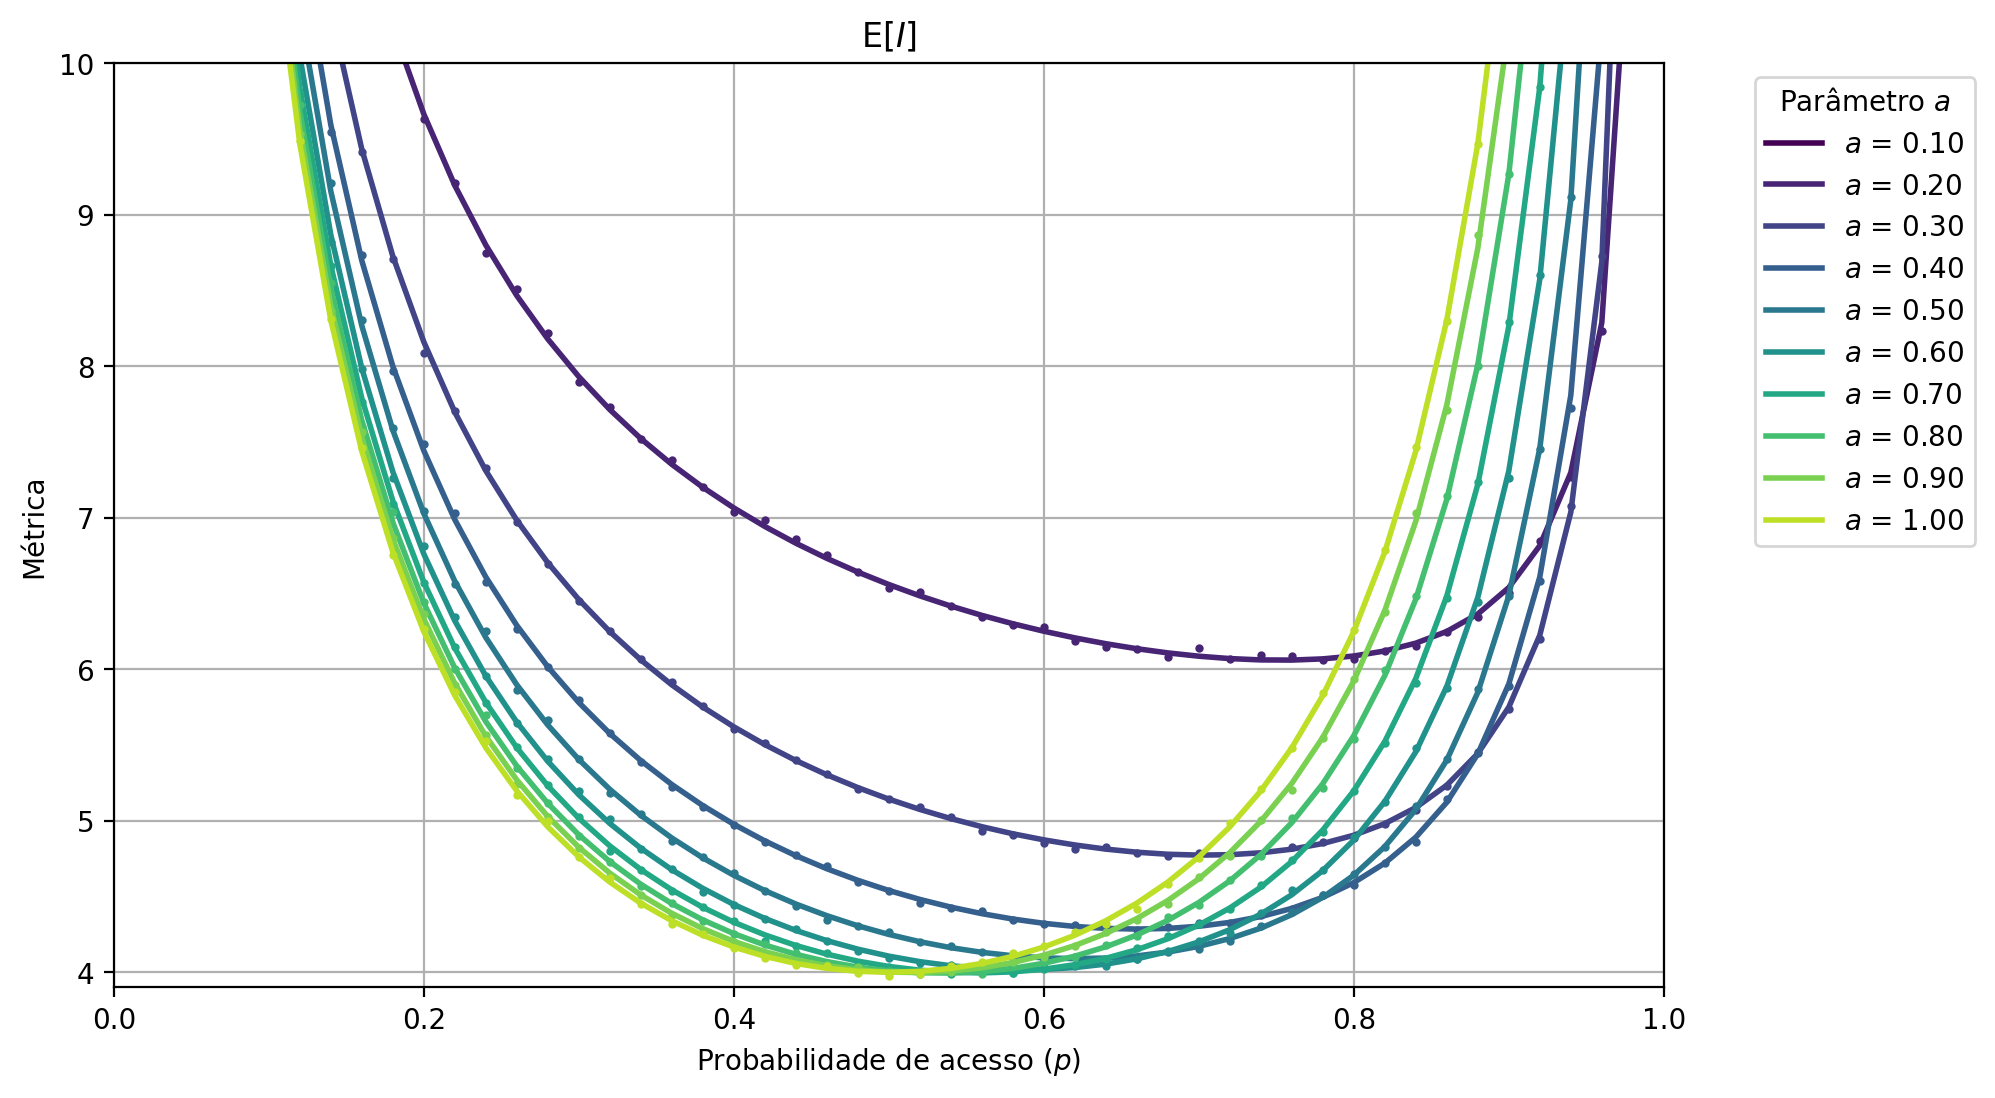

In [58]:
pX0 = a  # c'est vrai
pX1 = thr/(pi01 + pi11)  # c'est vrai
I_expr = (1/pX0 + 1/pX1) - 1
compare_metric_plot(
    analytical_expr=I_expr,
    simulation_data=I_sim,
    title="E[$I$]",
    cmap="viridis",
    yrange=(3.9,10)
)

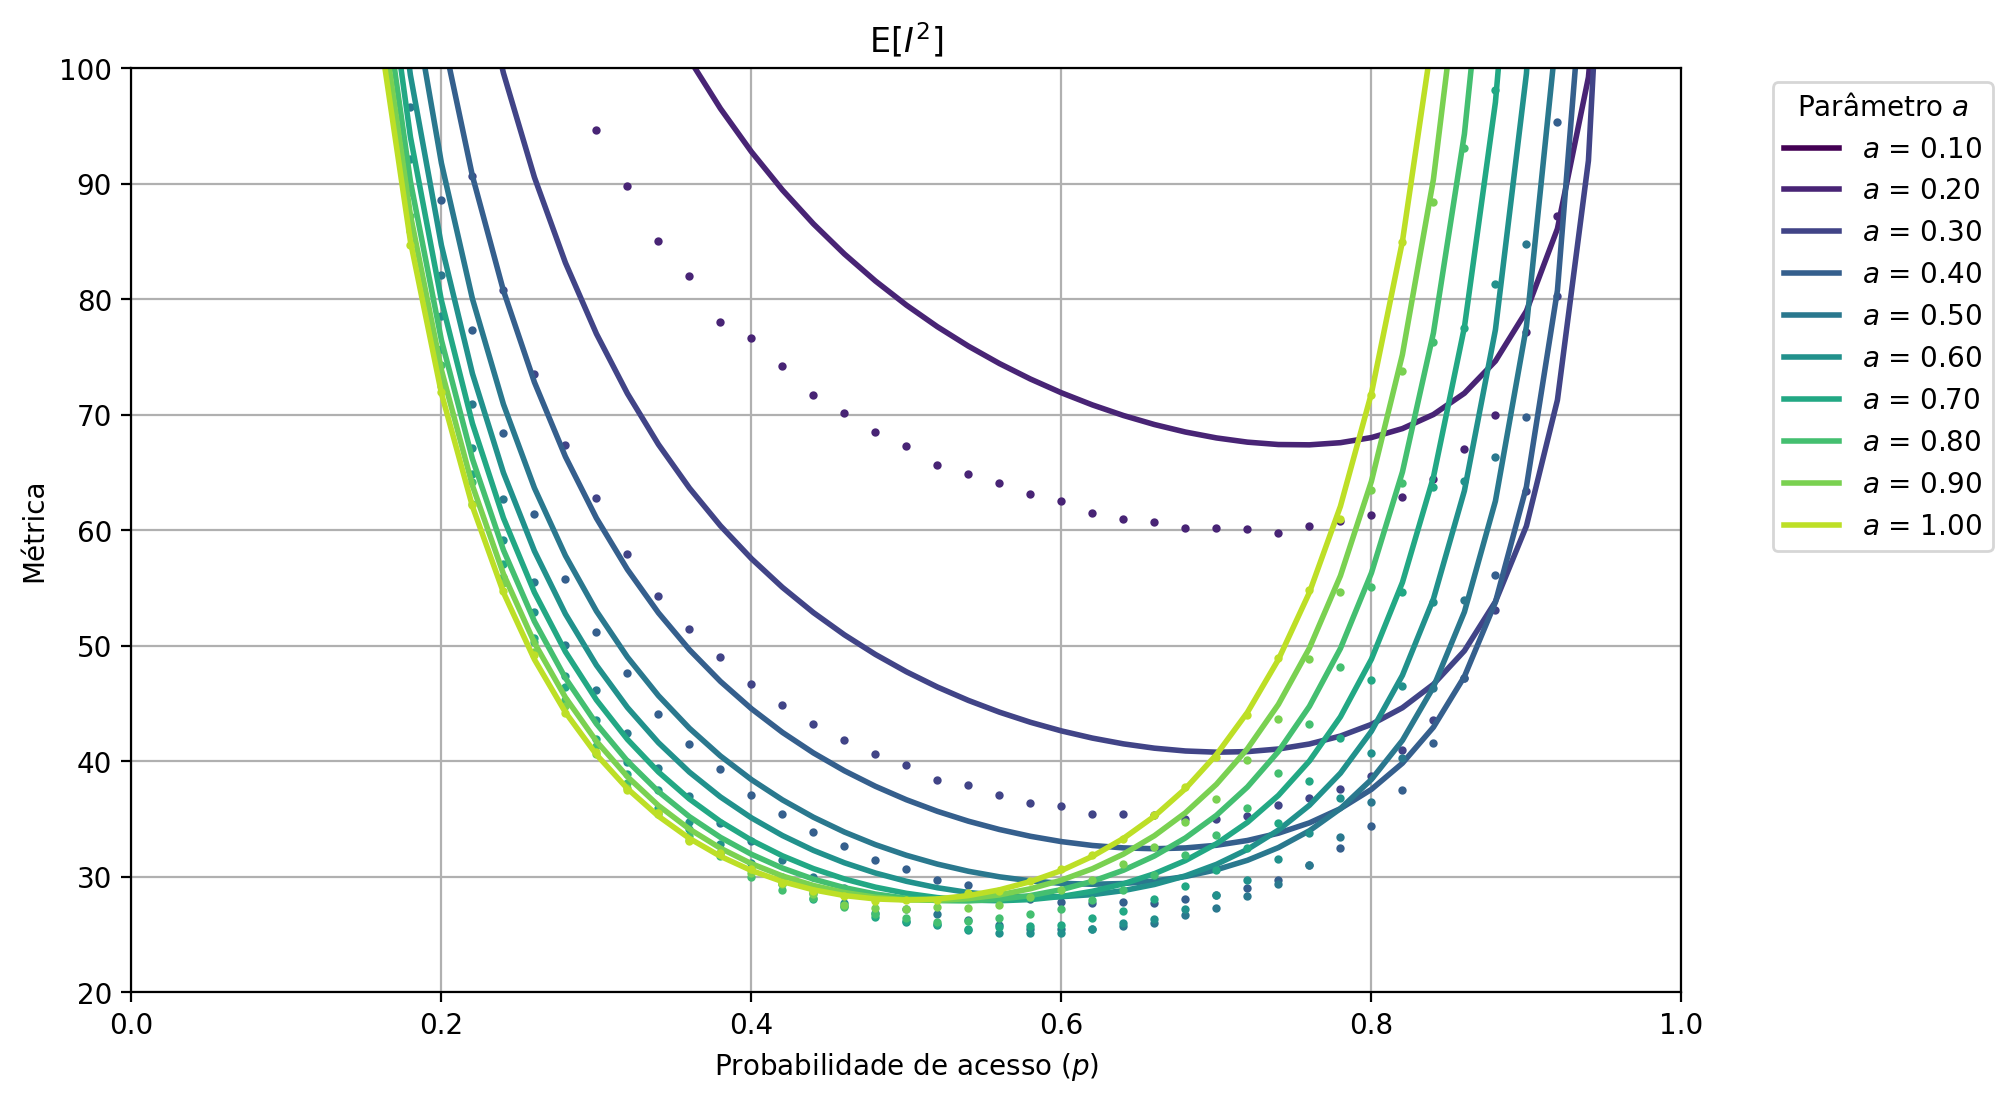

In [59]:
# p_s = thr
# I_squared_expr = (2-a)/a**2 + 2 /a /p_s + (2-p_s)/(p_s)**2  # eq do gemini
I_squared_expr = (2 - thr)/thr**2
# I_squared_expr = (2 - pX0)/pX0**2 + 2 /pX0 /pX1 + (2-pX1)/pX1**2 - 10
compare_metric_plot(
    analytical_expr=I_squared_expr,
    simulation_data=I_squared_sim,
    title="E[$I^2$]",
    cmap="viridis",
    yrange=(20, 100)
)

In [13]:
X0_sqr_sim = simulate_metric(sim.X0_sqr, 100000)

In [41]:
X1_sqr_sim = simulate_metric(sim.X1_sqr, 500000)
# X1_sim = simulate_metric(sim.X1_sqr, 1000000)

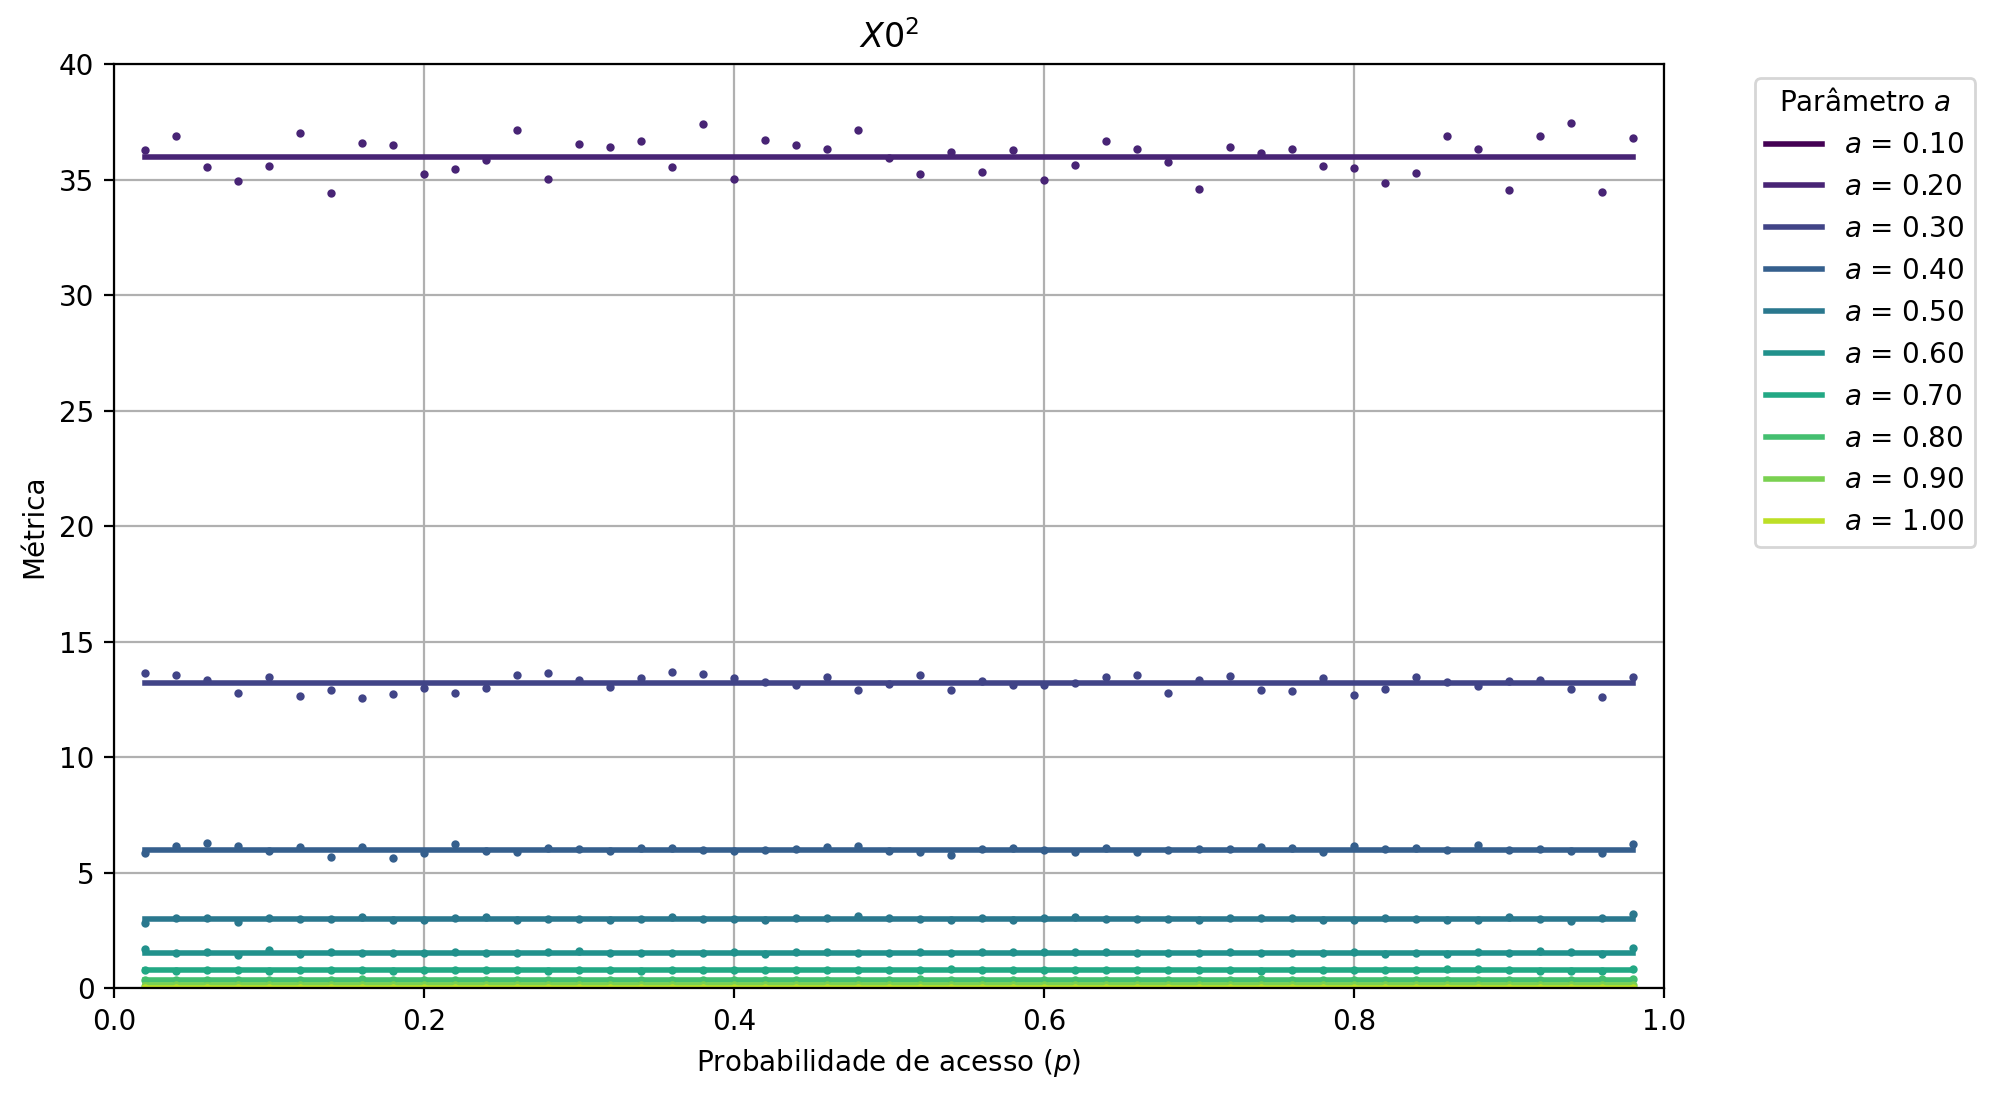

In [35]:
compare_metric_plot(
    analytical_expr= (1 - pX0)*(2-pX0)/(pX0**2),
    simulation_data= X0_sqr_sim,
    title="$X0^2$",
    yrange=(0,40)
)

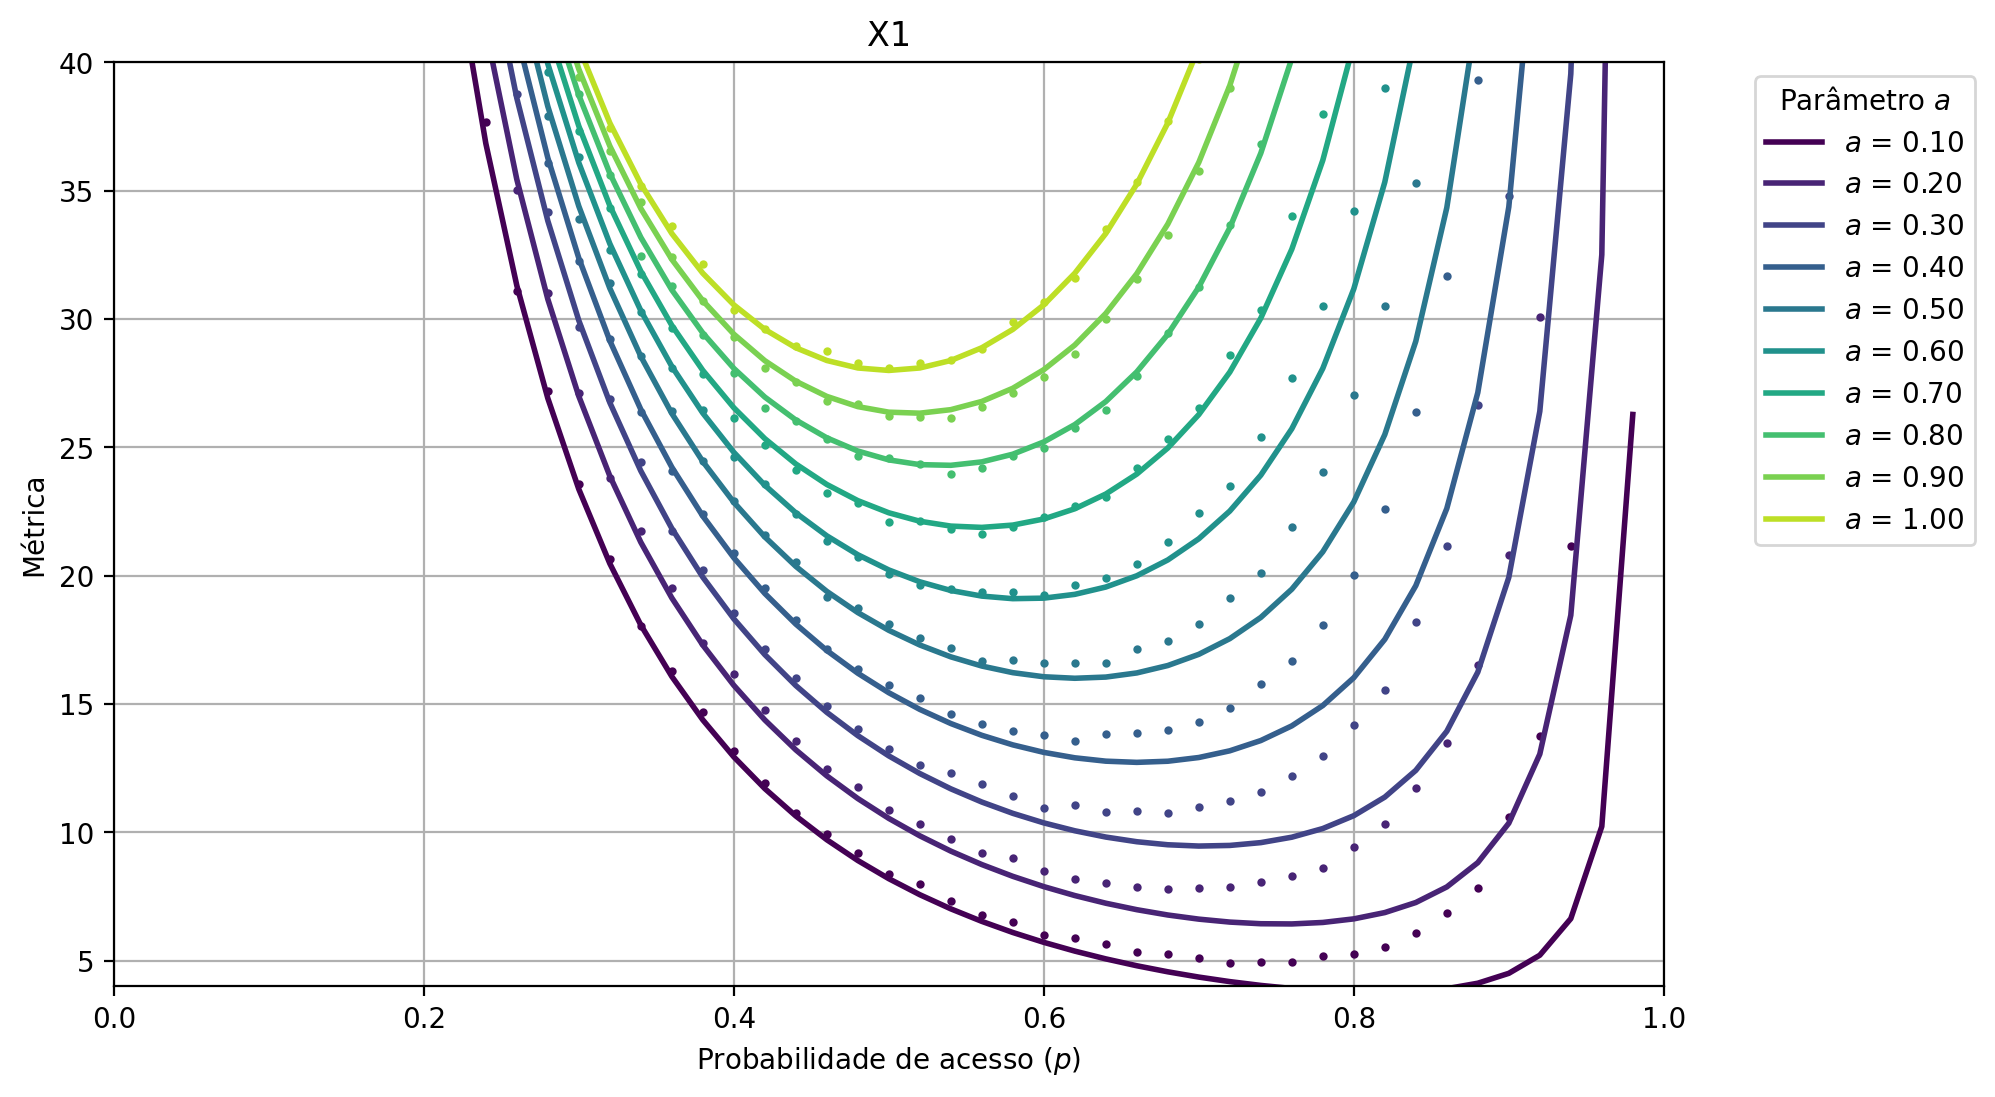

In [56]:
compare_metric_plot(
    analytical_expr= (2-pX1)/pX1**2,
    simulation_data= X1_sqr_sim,
    title="X1",
    yrange=(4,40)
)

In [18]:
X0X1 = simulate_metric(sim.X0_dot_X1, 100000)

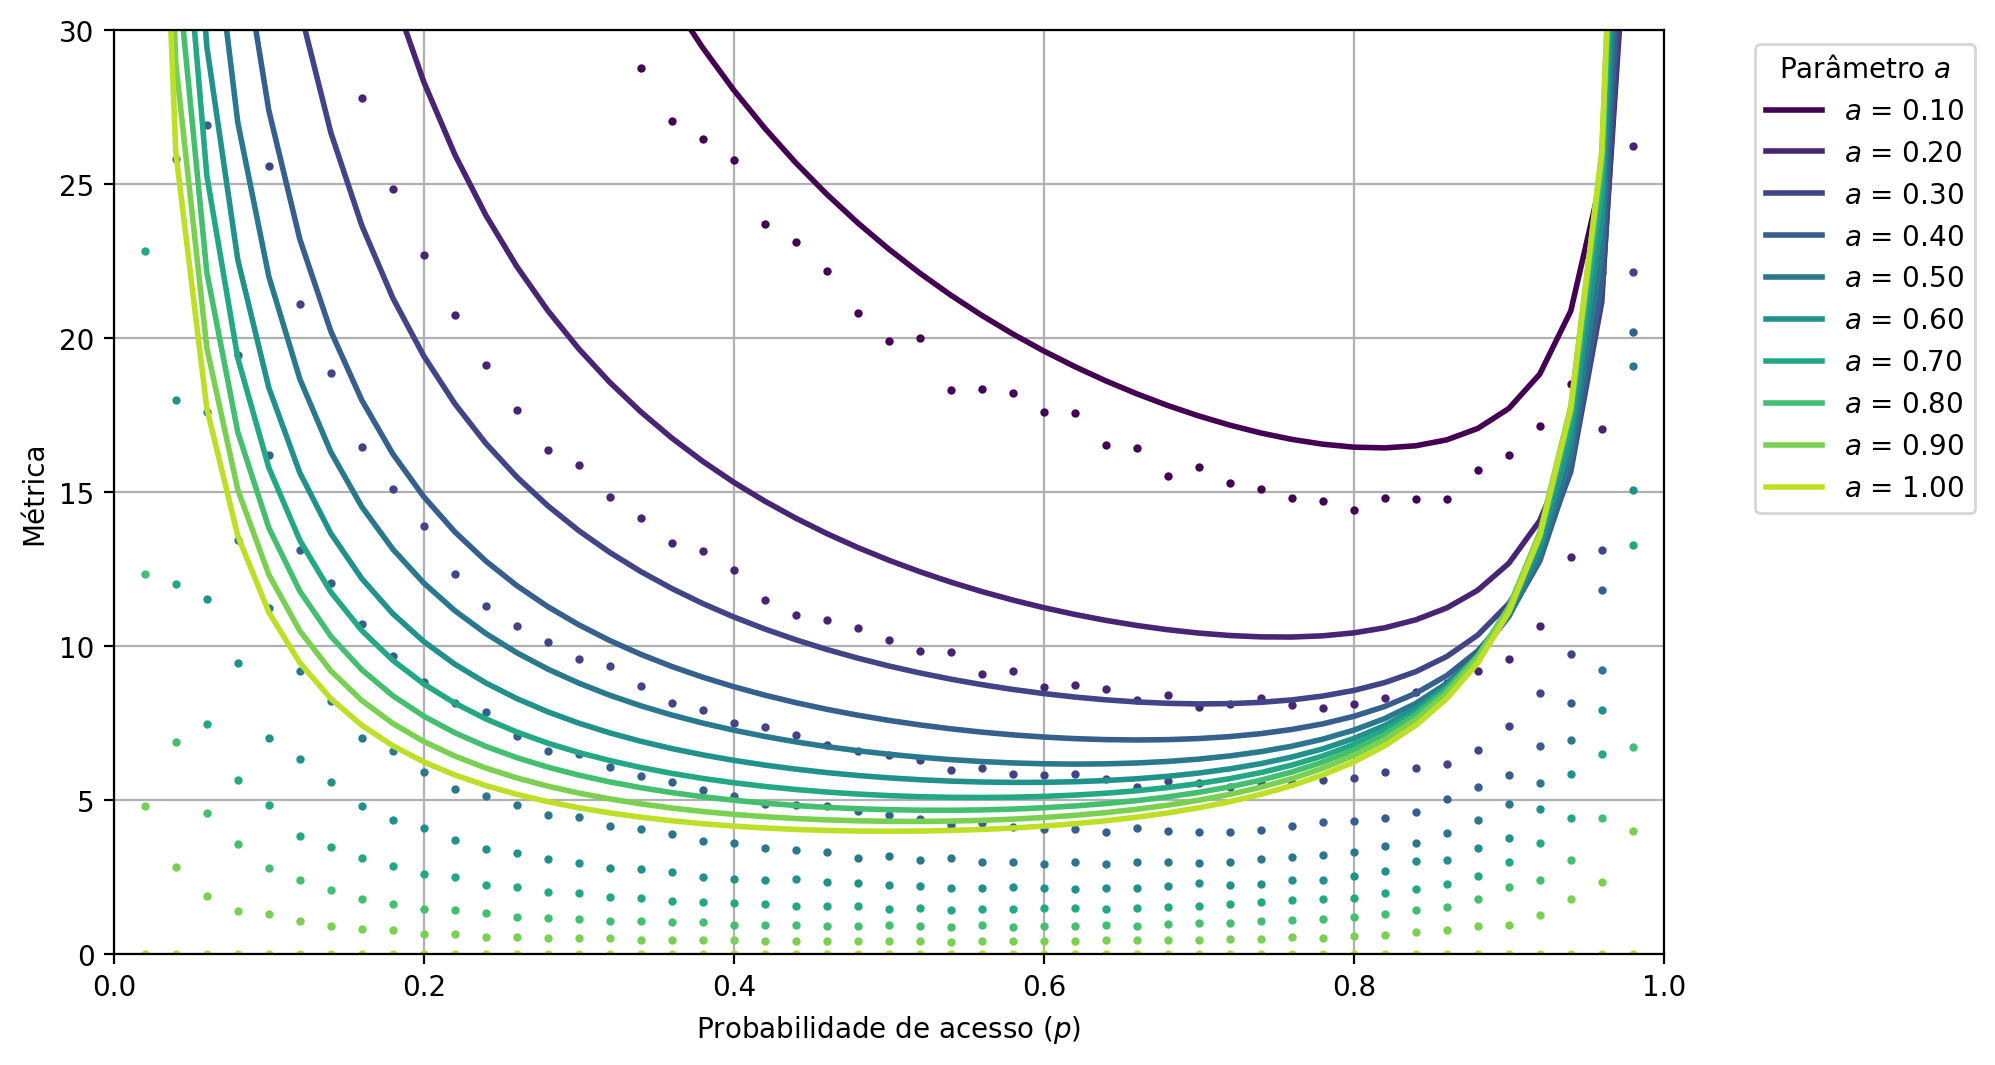

In [45]:
compare_metric_plot(
    analytical_expr = 1 /pX0 /pX1,
    simulation_data = X0X1,
    title="",
    yrange=(0,30)
)

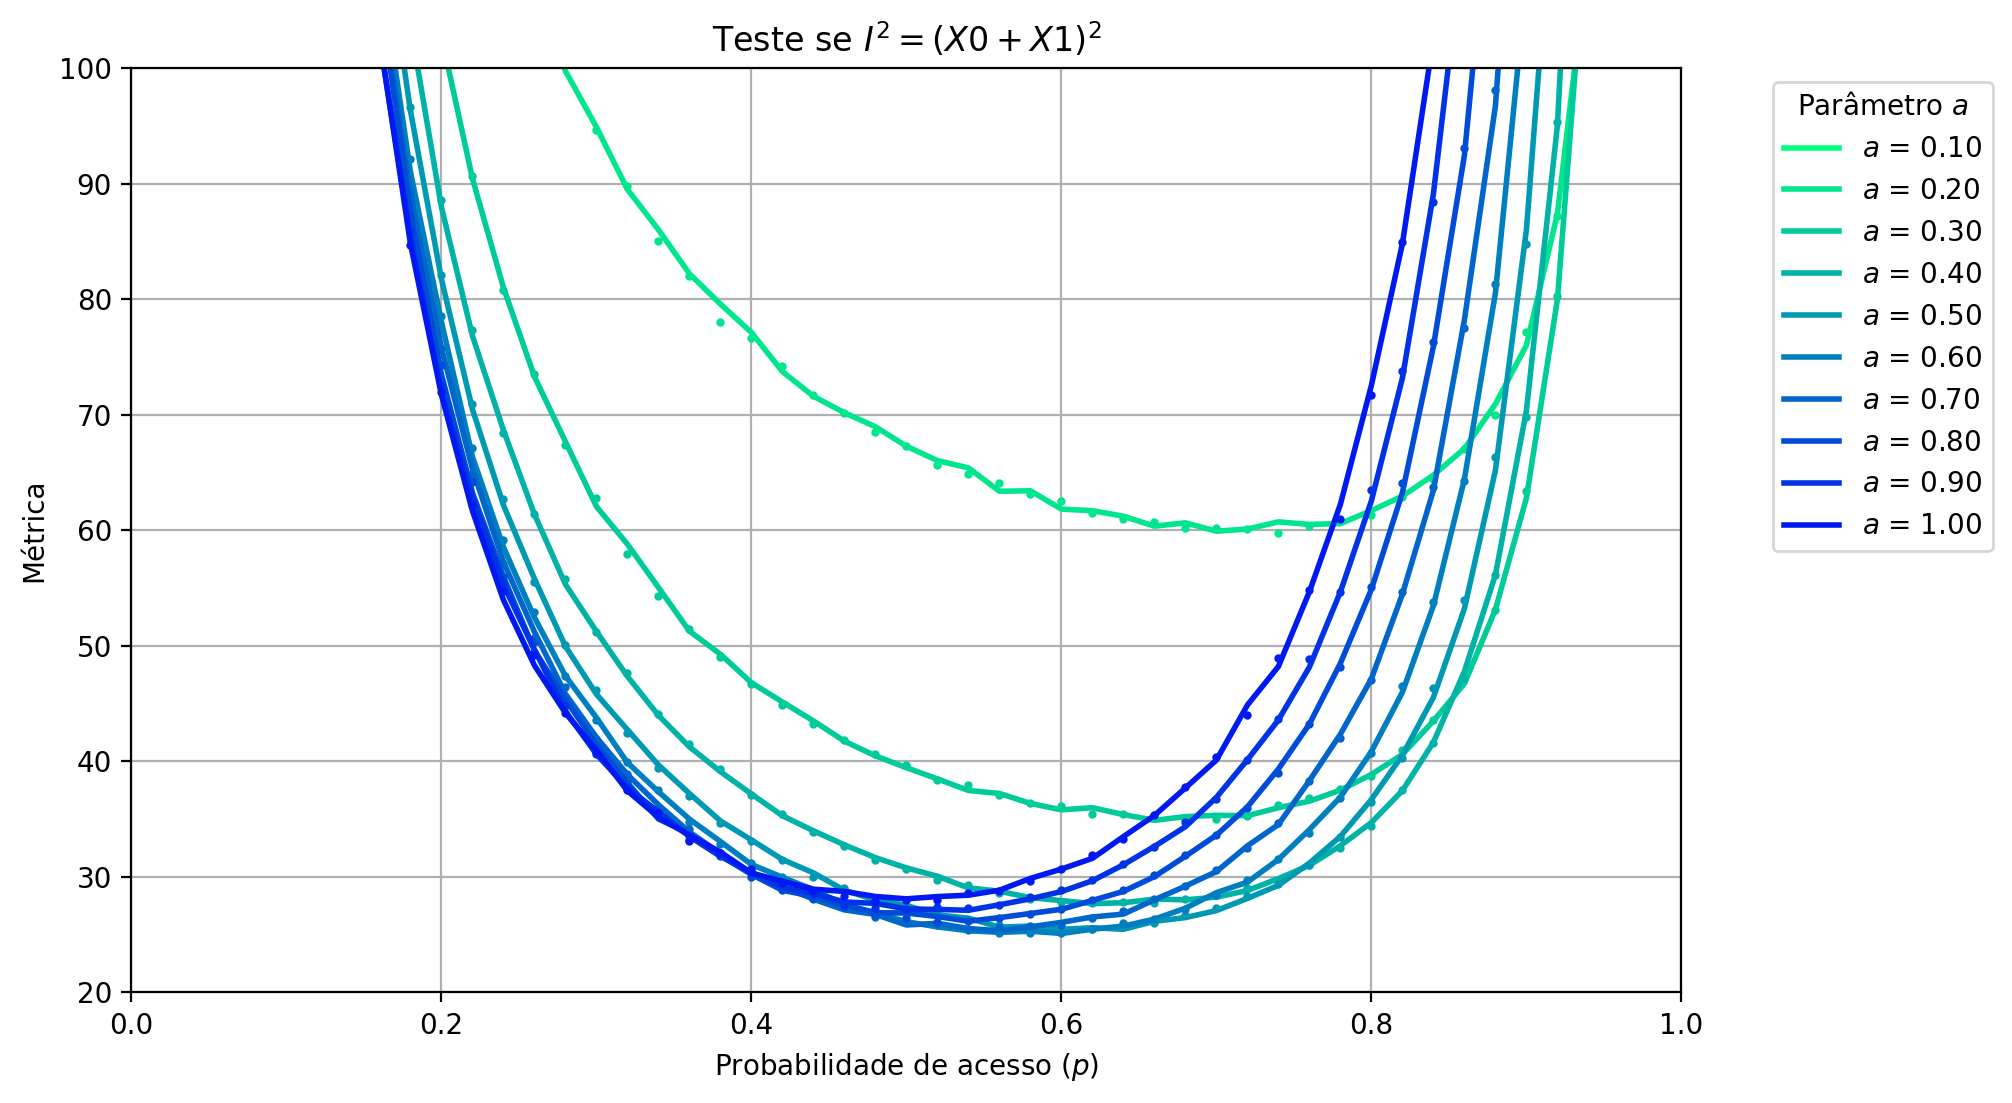

In [54]:
X0_sqr = make_metric_func((1 - pX0)*(2-pX0)/(pX0**2))  # c'est vrai
X1_sqr = make_metric_func(X1_sqr_sim)
X0X1_func = make_metric_func(X0X1)
I_squared_vrai = np.vectorize(lambda a, p: X0_sqr(a, p) + X1_sqr(a, p) + 2*X0X1_func(a,p))
plot_metric(
    analytical_func = I_squared_vrai,
    simulation_data_func = make_metric_func(I_squared_sim),
    title = "Teste se $I^2 = (X0+X1)^2$",
    cmap = "winter_r",
    yrange=(20,100)
)

# TSA

In [1]:
%load_ext autoreload
%autoreload 2
import src.simulations_TSA as TSA_sim
import src.sim_three_nodes as sim3

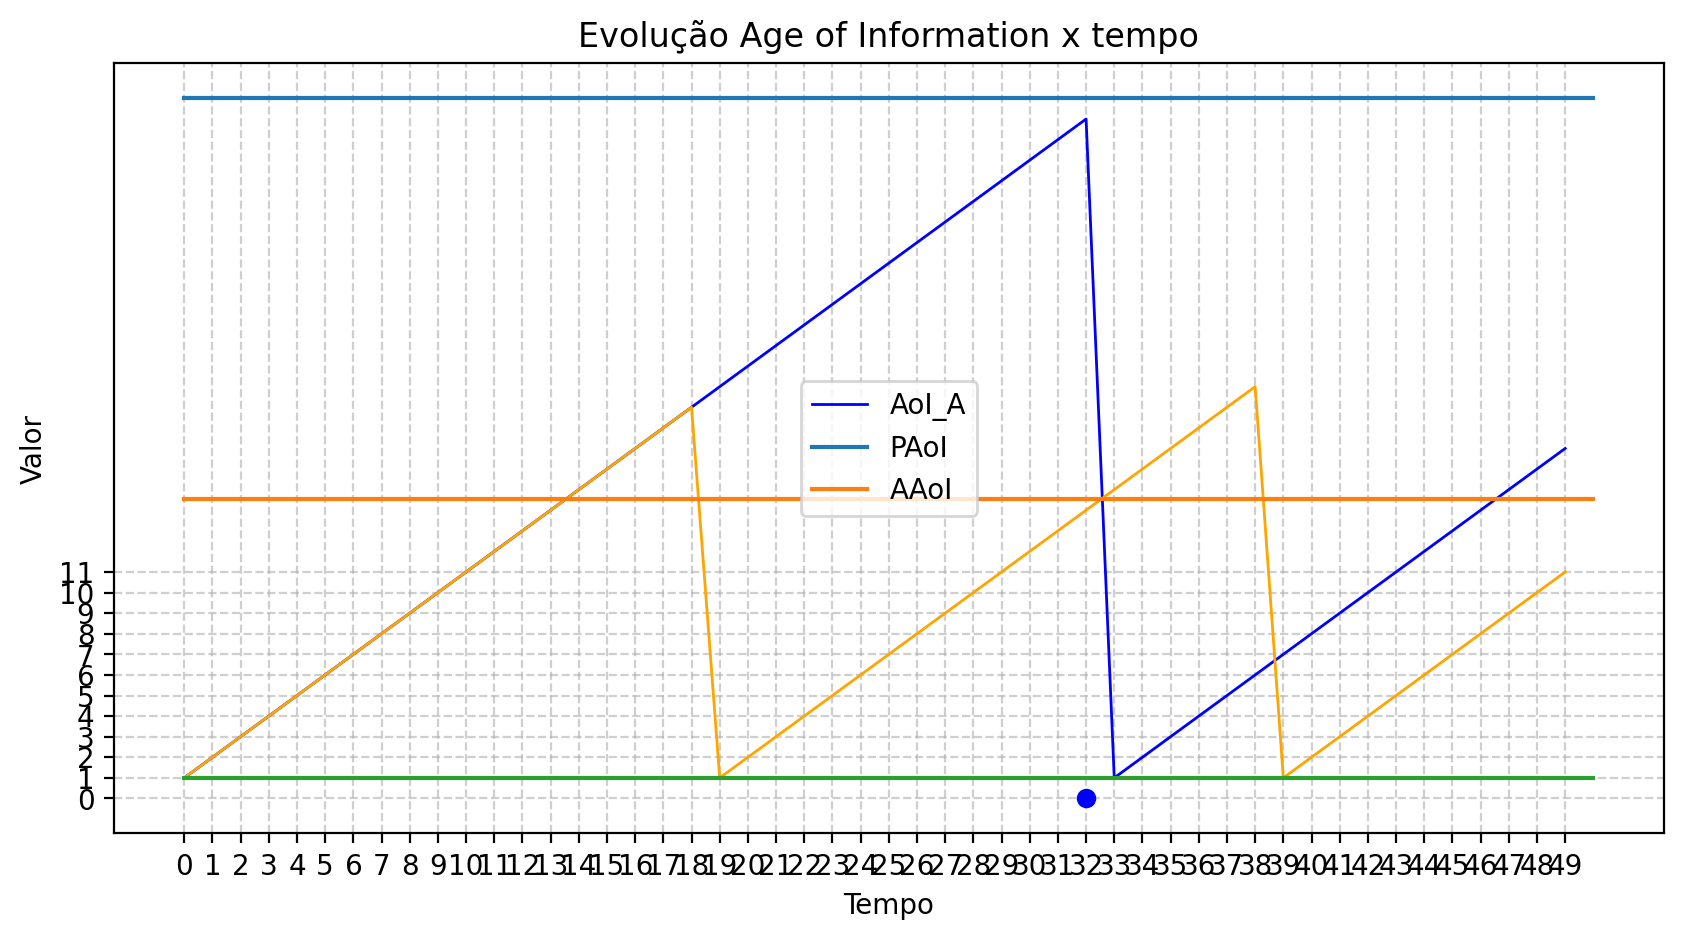

In [17]:
max_time = 50
threshold = 1
AoI_A, AoI_B, times_succes_pack, PAoI, AAoI, successes = TSA_sim.evolution_AoI_sim(arrival_prob=1, send_prob=0.9, threshold=threshold, time=max_time)
# AoI_A = np.insert(AoI_A, 0, 0)
# AoI_B = np.insert(AoI_B, 0, 0)


t_A_plot = range(max_time )
t_B_plot = range(max_time )
AoI_A_plot = AoI_A
AoI_B_plot = AoI_B


# t_A_plot = [0]
# t_B_plot = [0]
# AoI_A_plot = [0]
# AoI_B_plot = [0]

# for i in range(1, max_time + 1):
#   # Adiciona o ponto atual
#   t_A_plot.append(i)
#   t_B_plot.append(i)
#   AoI_A_plot.append(AoI_A[i])
#   AoI_B_plot.append(AoI_B[i])

#   # Verifica se o próximo valor cai (volta p)
#   if i < max_time:
#     if AoI_A[i+1] <= AoI_A[i]:
#       t_A_plot.append(i)
#       AoI_A_plot.append(AoI_A[i+1]-1)
#     if AoI_B[i+1] <= AoI_B[i]:
#       t_B_plot.append(i)
#       AoI_B_plot.append(AoI_B[i+1]-1)

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(t_A_plot, AoI_A_plot, marker='None', linewidth=1, color = "blue", label="AoI_A")
plt.plot(t_B_plot, AoI_B_plot, marker='None', linewidth=1, color = "orange")
plt.plot(times_succes_pack, [0]*len(times_succes_pack), marker='o', linestyle="None", color="blue")
plt.plot([0, max_time], [PAoI, PAoI], label="PAoI")
AAoI = np.mean(AoI_A[1:])
plt.plot([0, max_time], [AAoI, AAoI], label="AAoI")
plt.plot([0, max_time], [threshold, threshold])

# Ajustes de visualização
plt.title('Evolução Age of Information x tempo')
plt.xlabel('Tempo')
plt.xticks(range(0, max_time))
plt.yticks(range(0, 12))
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [4]:
max_time = 1000
threshold = 4
AoI_A, AoI_B, tau_A, times_succes_pack, PAoI, AAoI, successes = TSA_sim.evolution_AoI_til_sim(arrival_prob=0.4, send_prob=0.9, threshold=threshold, time=max_time)
AoI_A = np.insert(AoI_A, 0, 0)
AoI_B = np.insert(AoI_B, 0, 0)
# tau_A = np.insert(tau_A, 0, 0)

t_A_plot = [0]
t_B_plot = [0]
AoI_A_plot = [0]
AoI_B_plot = [0]

t_tau_plot = [0]
tau_A_plot = [0]

for i in range(1, max_time + 1):
  # Adiciona o ponto atual
  t_A_plot.append(i)
  t_B_plot.append(i)
  AoI_A_plot.append(AoI_A[i])
  AoI_B_plot.append(AoI_B[i])

  t_tau_plot.append(i)
#   tau_A_plot.append(tau_A[i])

  # Verifica se o próximo valor cai (volta p)
  if i < max_time:
    if AoI_A[i+1] <= AoI_A[i]:
      t_A_plot.append(i)
      AoI_A_plot.append(AoI_A[i+1]-1)
    if AoI_B[i+1] <= AoI_B[i]:
      t_B_plot.append(i)
      AoI_B_plot.append(AoI_B[i+1]-1)
    # if tau_A[i+1] <= tau_A[i]:
    #   tau_A_plot.append(i)
    #   t_tau_plot.append(i)

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(t_A_plot, AoI_A_plot, marker='None', linewidth=1, color = "blue", label="AoI_A")
plt.plot(range(max_time), tau_A, marker='None', linewidth=1, color = "gray", label="$\\tau_A$")
plt.plot(t_B_plot, AoI_B_plot, marker='None', linewidth=1, color = "orange")
plt.plot(times_succes_pack, [0]*len(times_succes_pack), marker='o', linestyle="None", color="blue")
plt.plot([0, max_time], [PAoI, PAoI], label="PAoI")
AAoI = np.mean(AoI_A[1:])
plt.plot([0, max_time], [AAoI, AAoI], label="AAoI")
plt.plot([0, max_time], [threshold, threshold])

# Ajustes de visualização
plt.title('Evolução Age of Information x tempo')
plt.xlabel('Tempo')
plt.xticks(range(0, max_time))
#plt.yticks(range(0, 12))
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

NameError: name 'TSA_sim' is not defined

In [15]:
print("PAoI:", PAoI)
print("AAoI:", AAoI)

PAoI: 7.894039735099338
AAoI: 6.083


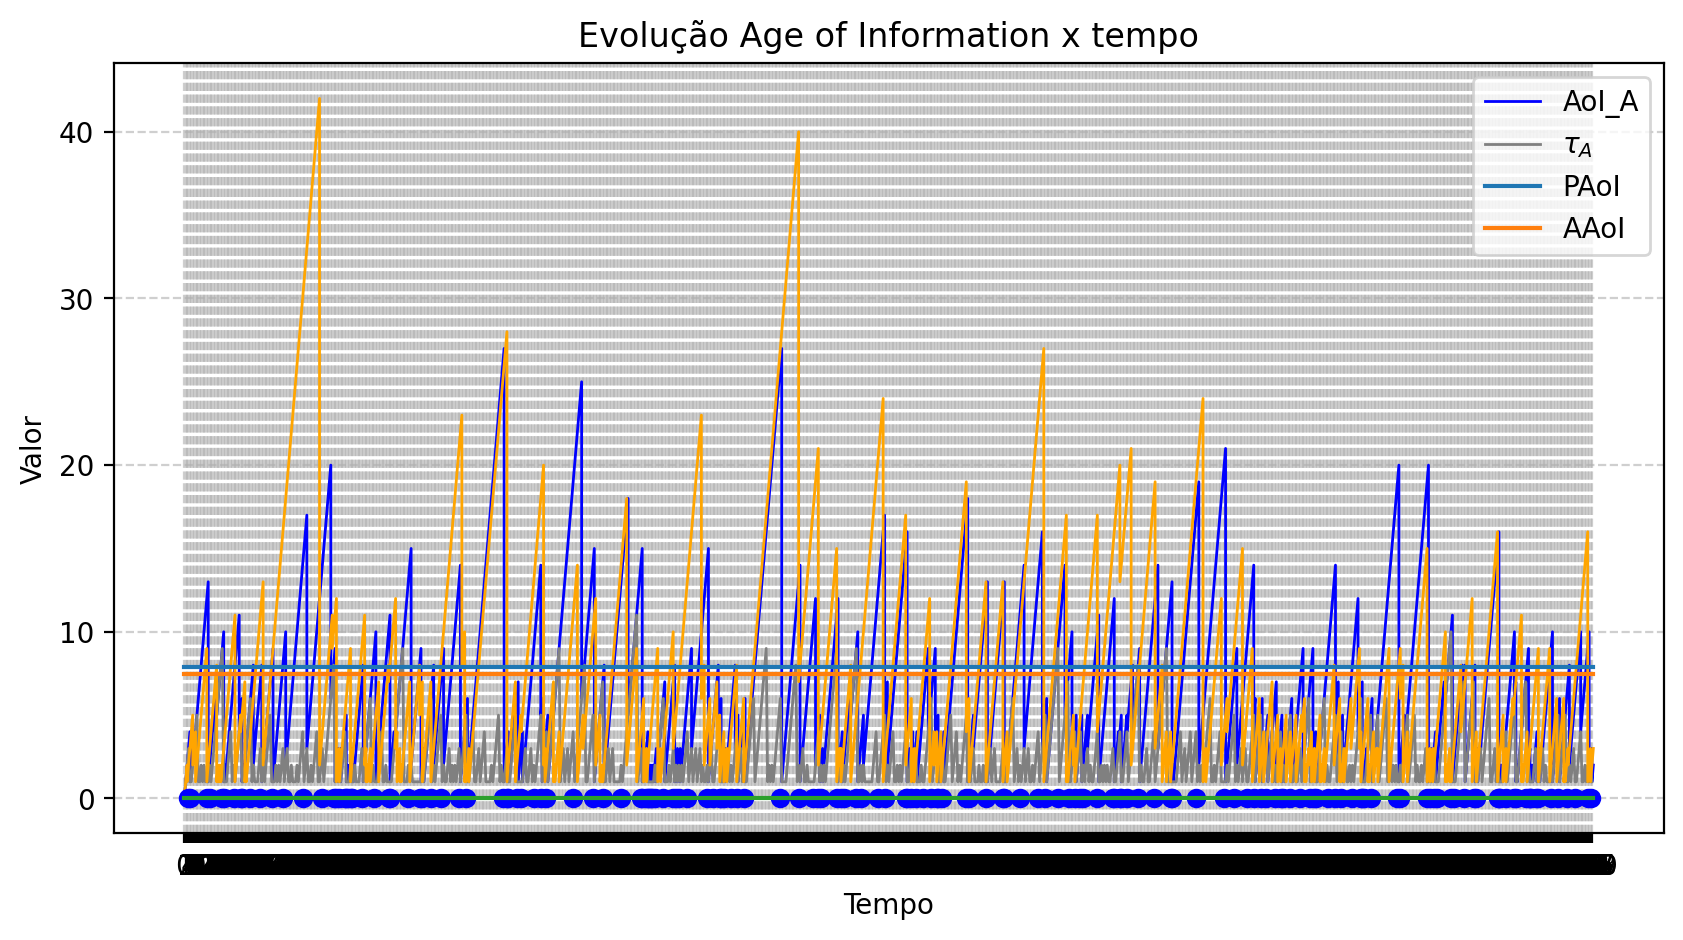

In [ ]:
max_time = 1000
threshold = 0
AoI_A, AoI_B, tau_A, times_succes_pack, PAoI, AAoI, successes = TSA_sim.evolution_AoI_til_sim(arrival_prob=0.4, send_prob=0.9, threshold=threshold, time=max_time)
AoI_A = np.insert(AoI_A, 0, 0)
AoI_B = np.insert(AoI_B, 0, 0)
# tau_A = np.insert(tau_A, 0, 0)

t_A_plot = [0]
t_B_plot = [0]
AoI_A_plot = [0]
AoI_B_plot = [0]

t_tau_plot = [0]
tau_A_plot = [0]

for i in range(1, max_time + 1):
  # Adiciona o ponto atual
  t_A_plot.append(i)
  t_B_plot.append(i)
  AoI_A_plot.append(AoI_A[i])
  AoI_B_plot.append(AoI_B[i])

  t_tau_plot.append(i)
#   tau_A_plot.append(tau_A[i])

  # Verifica se o próximo valor cai (volta p)
  if i < max_time:
    if AoI_A[i+1] <= AoI_A[i]:
      t_A_plot.append(i)
      AoI_A_plot.append(AoI_A[i+1]-1)
    if AoI_B[i+1] <= AoI_B[i]:
      t_B_plot.append(i)
      AoI_B_plot.append(AoI_B[i+1]-1)
    # if tau_A[i+1] <= tau_A[i]:
    #   tau_A_plot.append(i)
    #   t_tau_plot.append(i)

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(t_A_plot, AoI_A_plot, marker='None', linewidth=1, color = "blue", label="AoI_A")
plt.plot(range(max_time), tau_A, marker='None', linewidth=1, color = "gray", label="$\\tau_A$")
plt.plot(t_B_plot, AoI_B_plot, marker='None', linewidth=1, color = "orange")
plt.plot(times_succes_pack, [0]*len(times_succes_pack), marker='o', linestyle="None", color="blue")
plt.plot([0, max_time], [PAoI, PAoI], label="PAoI")
AAoI = np.mean(AoI_A[1:])
plt.plot([0, max_time], [AAoI, AAoI], label="AAoI")
plt.plot([0, max_time], [threshold, threshold])

# Ajustes de visualização
plt.title('Evolução Age of Information x tempo')
plt.xlabel('Tempo')
plt.xticks(range(0, max_time))
#plt.yticks(range(0, 12))
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

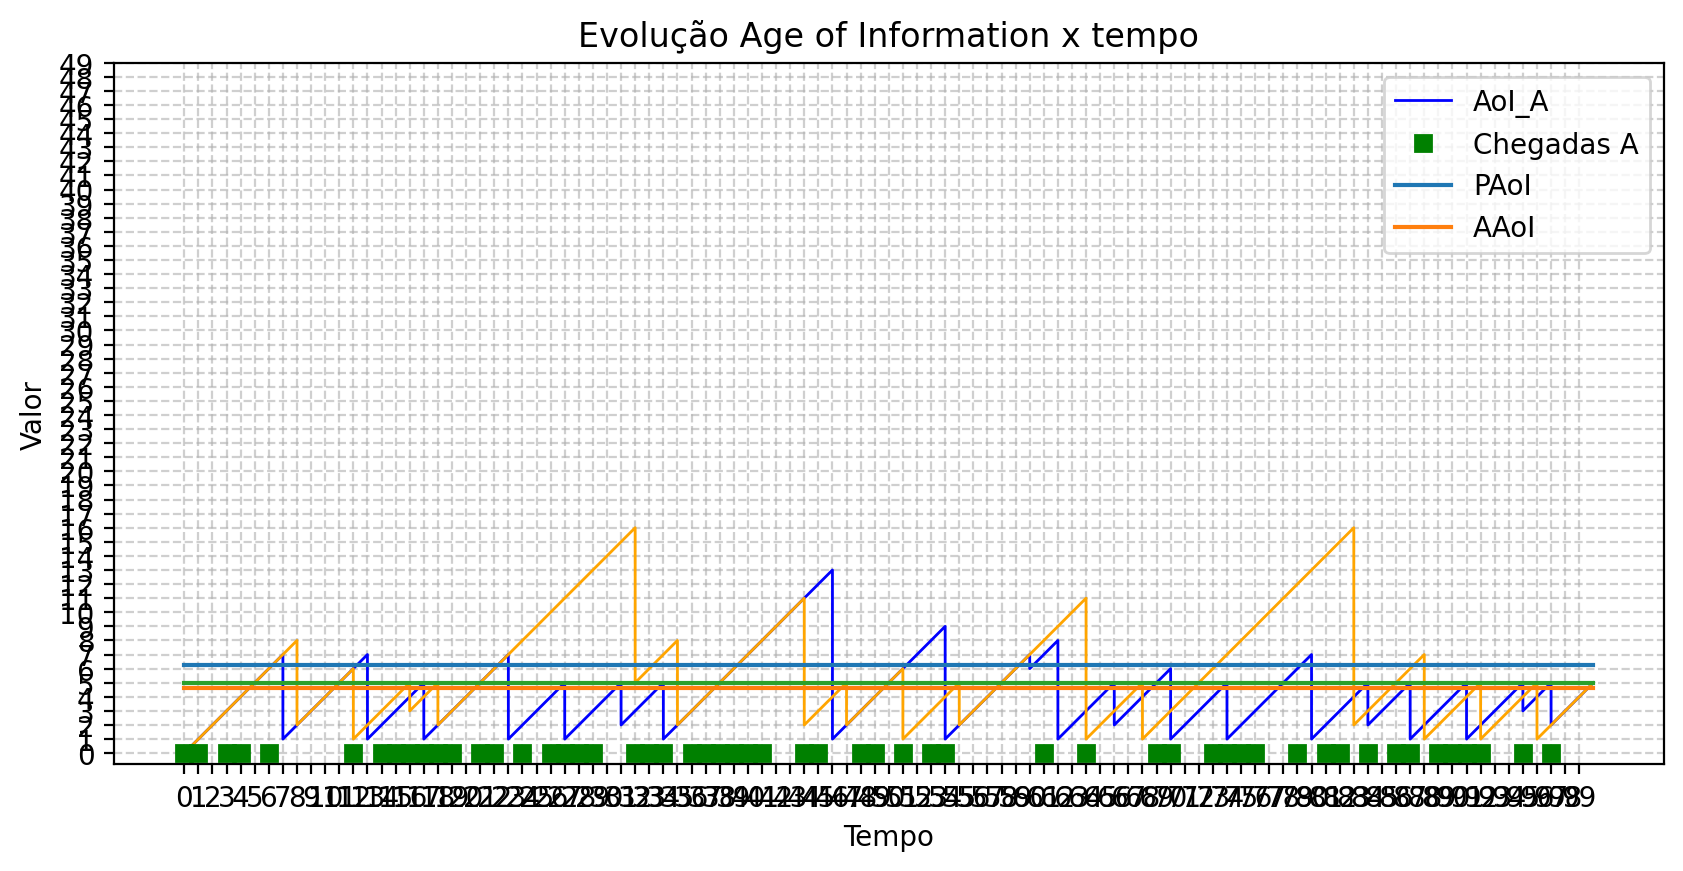

PAoI: 6.238095238095238
AAoI: 4.6


In [4]:
max_time = 100
threshold = 5
AoI_A, AoI_B, times_succes_pack, PAoI, AAoI, successes, arrivals = TSA_sim.evolution_AoI_plinio_sim(arrival_prob=0.5, send_prob=0.5, threshold=threshold, time=max_time)
AoI_A = np.insert(AoI_A, 0, 0)
AoI_B = np.insert(AoI_B, 0, 0)
# tau_A = np.insert(tau_A, 0, 0)

t_A_plot = [0]
t_B_plot = [0]
AoI_A_plot = [0]
AoI_B_plot = [0]

t_tau_plot = [0]
tau_A_plot = [0]

for i in range(1, max_time + 1):
  # Adiciona o ponto atual
  t_A_plot.append(i)
  t_B_plot.append(i)
  AoI_A_plot.append(AoI_A[i])
  AoI_B_plot.append(AoI_B[i])

  t_tau_plot.append(i)
#   tau_A_plot.append(tau_A[i])

  # Verifica se o próximo valor cai (volta p)
  if i < max_time:
    if AoI_A[i+1] <= AoI_A[i]:
      t_A_plot.append(i)
      AoI_A_plot.append(AoI_A[i+1]-1)
    if AoI_B[i+1] <= AoI_B[i]:
      t_B_plot.append(i)
      AoI_B_plot.append(AoI_B[i+1]-1)
    # if tau_A[i+1] <= tau_A[i]:
    #   tau_A_plot.append(i)
    #   t_tau_plot.append(i)

# Plotagem
plt.figure(figsize=(10, 20))
plt.plot(t_A_plot, AoI_A_plot, marker='None', linewidth=1, color = "blue", label="AoI_A")
plt.plot(t_B_plot, AoI_B_plot, marker='None', linewidth=1, color = "orange")
# plt.plot(times_succes_pack, [0]*len(times_succes_pack), marker='o', linestyle="None", color="blue")
plt.plot(arrivals, [0]*len(arrivals), marker='s', linestyle="None", color="green", label="Chegadas A")
plt.plot([0, max_time], [PAoI, PAoI], label="PAoI")
AAoI = np.mean(AoI_A[1:])
plt.plot([0, max_time], [AAoI, AAoI], label="AAoI")
plt.plot([0, max_time], [threshold, threshold])

# Ajustes de visualização
plt.title('Evolução Age of Information x tempo')
plt.xlabel('Tempo')
plt.xticks(range(0, max_time))
plt.yticks(range(0, 50))
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().set_aspect("equal")

plt.show()

print("PAoI:", PAoI)
print("AAoI:", AAoI)

In [19]:
print("PAoI:", PAoI)
print("AAoI:", AAoI)

PAoI: 7.5773809523809526
AAoI: 7.833


In [9]:
from scipy.optimize import minimize
limites = ((0.01, 0.99), (0.01, 0.99), ())
funcao_t = lambda a, p, t: (1 - a) * (1 - p) * (1 - t) + a * (1 - p) * (1 - t) + a * p * (1 - t) + a * p * t
teste = minimize(funcao_t, [0.5, 0.5, 3], bounds=limites, method='L-BFGS-B')
# print(f"a = {a_val}, p_opt = {teste.x}, metric_opt = {teste.fun}")
teste

TypeError: <lambda>() missing 2 required positional arguments: 'p' and 't'

In [18]:
simulate_metric_TSA(
    TSA_sim.AAoI_PAoI_sim,
    500000,
    "TSA_AAoI_PAoI_hom_sim",
)

Dados salvos em 'data/TSA_AAoI_PAoI_hom_sim.npy'.


(array([[[98.679322, 99.099298, 99.289192, ..., 99.314748, 99.97588 ,
          99.09361 ],
         [74.68489 , 75.768354, 74.39793 , ..., 73.269554, 72.462342,
          74.401996],
         [65.693592, 65.559558, 66.555402, ..., 65.556064, 64.435852,
          66.532742],
         ...,
         [50.181464, 51.01914 , 49.886806, ..., 49.619836, 50.706084,
          50.125258],
         [50.8398  , 50.387082, 49.866632, ..., 51.45015 , 50.635834,
          50.354746],
         [50.93371 , 49.899044, 50.268264, ..., 50.213614, 50.347638,
          50.830562]],
 
        [[73.735082, 74.845136, 74.726616, ..., 75.05888 , 74.02692 ,
          74.077834],
         [49.71445 , 49.255256, 49.344836, ..., 50.818958, 49.459522,
          49.207276],
         [40.980092, 40.731584, 41.172442, ..., 41.058256, 41.592798,
          40.741294],
         ...,
         [25.225112, 25.43562 , 25.672768, ..., 25.816646, 25.115762,
          25.249398],
         [25.48277 , 25.972376, 25.77351 , ..., 2

In [19]:
TSA_til = simulate_metric_TSA(
    TSA_sim.AAoI_PAoI_til_sim,
    500000,
    "TSA_AAoI_PAoI_til_sim",
)

Dados salvos em 'data/TSA_AAoI_PAoI_til_sim.npy'.


In [36]:
TSA_til = np.load("data/TSA_AAoI_PAoI_til_sim.npy", allow_pickle=True)
TSA = np.load("data/TSA_AAoI_PAoI_sim.npy")
AAoI_TSA, PAoI_TSA = TSA
AAoI_TSA_til, PAoI_TSA_til = TSA_til

In [12]:
AAoI_TSA[0,0]

array([101.04662 , 101.688154, 101.875154, 102.140546, 100.65581 ,
       100.614702, 102.485652, 100.35003 , 101.208074, 102.542974])

In [14]:
PAoI_TSA_til[:,:,0]

array([[125.03413655,  92.75434618,  80.35709482, ...,  52.27374872,
         52.2218256 ,  52.70250896],
       [ 91.06824926,  62.61485149,  52.06976744, ...,  26.91734903,
         27.31637397,  26.95422177],
       [ 77.41827542,  51.48612836,  42.78699627, ...,  19.0656459 ,
         18.9539727 ,  19.65692113],
       ...,
       [ 52.57371134,  27.26659669,  18.94286226, ...,  17.93271344,
         26.30712841,  49.9574364 ],
       [ 50.8241156 ,  26.86759762,  18.81452474, ...,  18.81719473,
         26.63489623,  51.37399194],
       [ 53.3       ,  27.49046105,  18.76999645, ...,  18.80573362,
         27.30447368,  53.91053467]], shape=(50, 49))

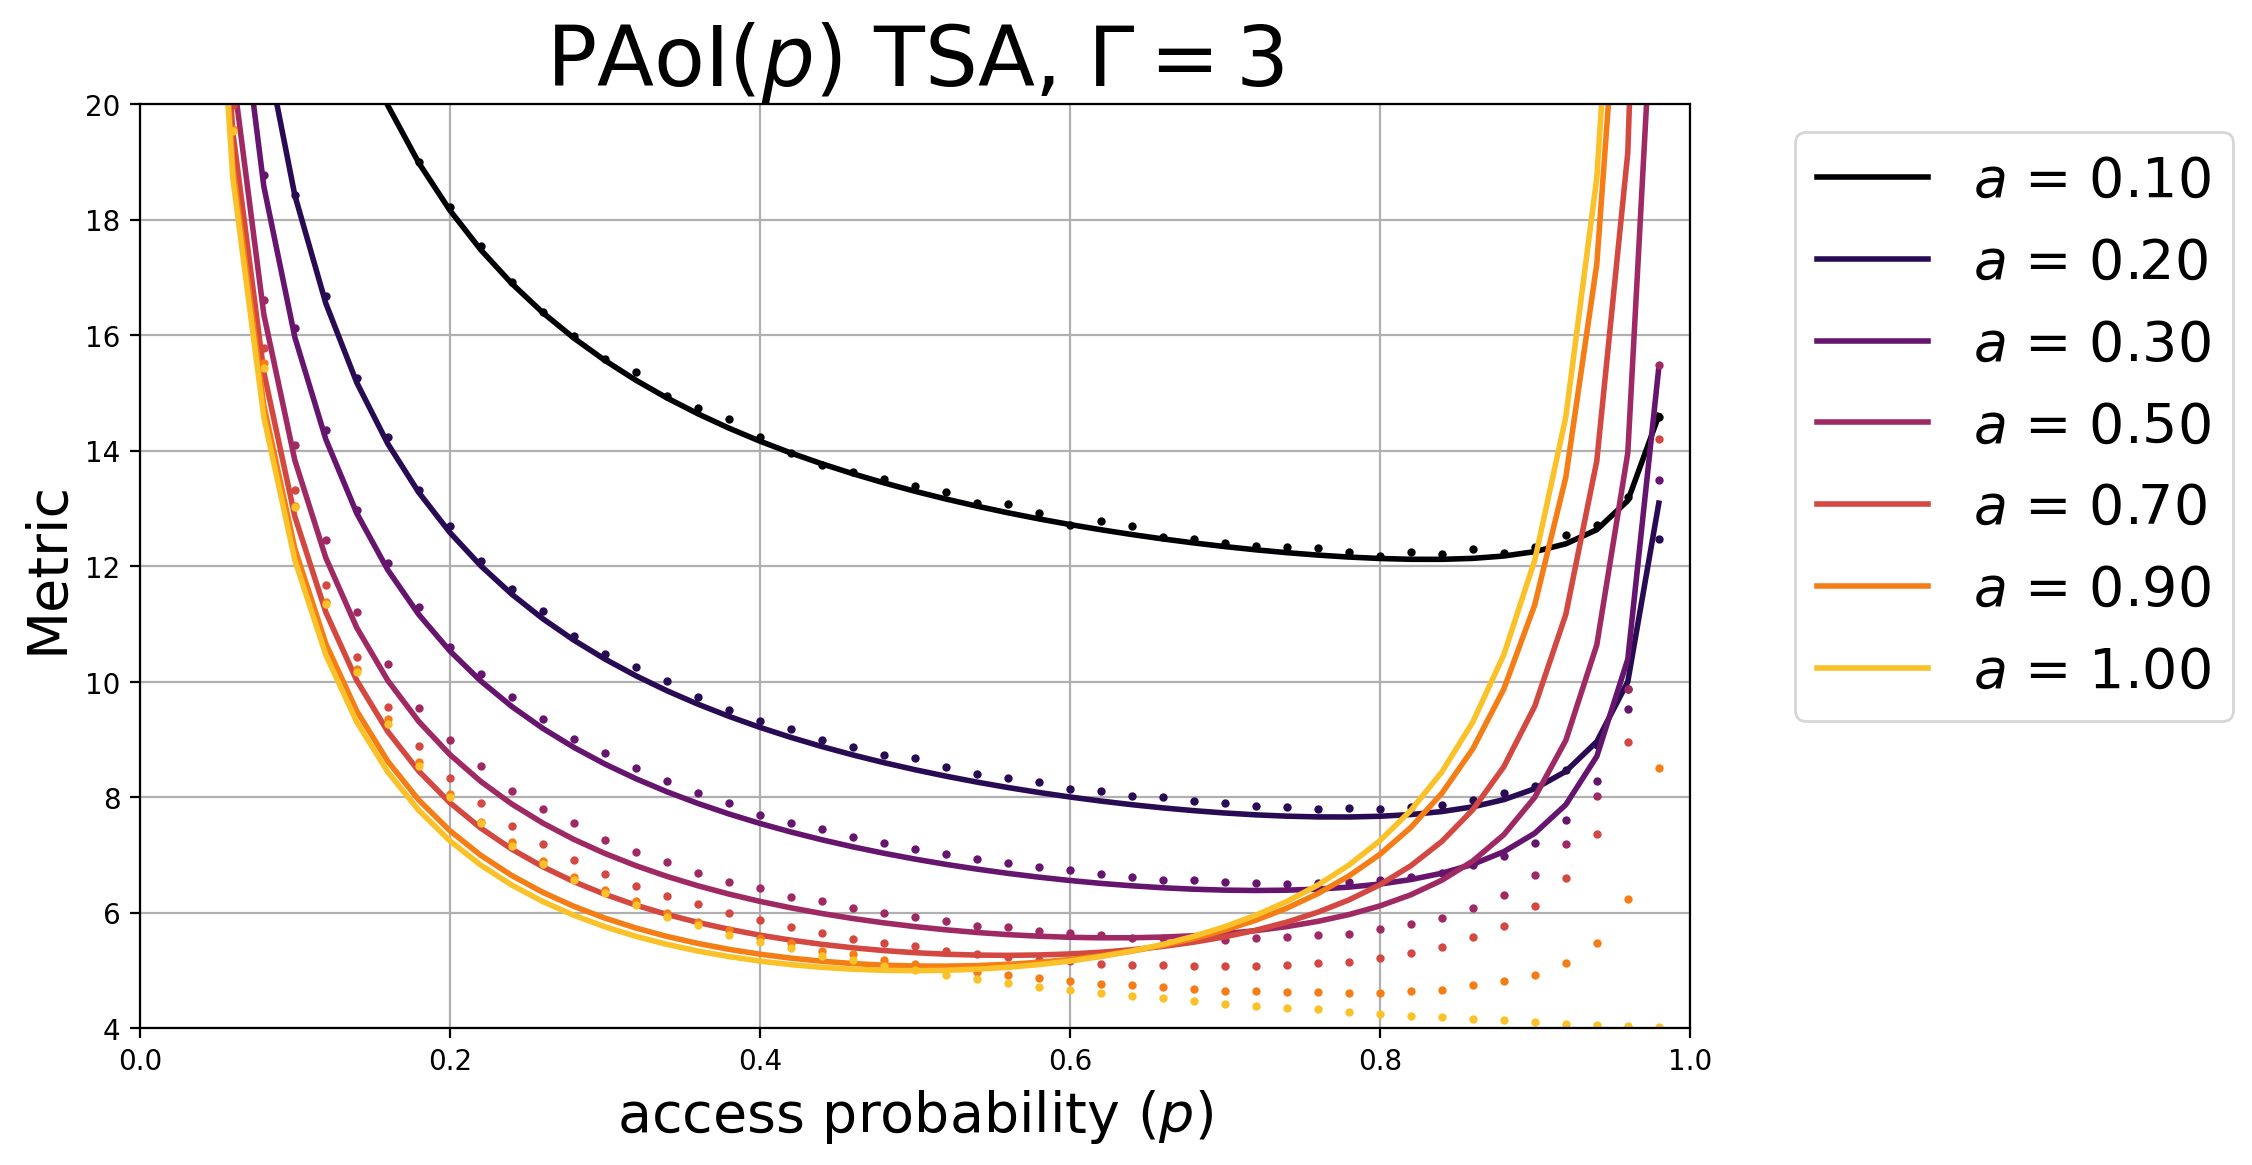

In [35]:
Gamma = 3
compare_metric_plot(
    analytical_expr=PAoI_expr,
    simulation_data=PAoI_TSA[:,:,Gamma],
    title="PAoI($p$) TSA, $\Gamma = $" + str(Gamma),
    cmap="inferno",
    axis="p",
    yrange=(4, 20),
)

# Comparação entre TSA e TSA_til

In [18]:
calc_TSA(0.5)

array([54.438688, 28.115048, 20.045228, 16.044424, 13.617408, 12.013648,
       10.721256,  9.786058,  9.05941 ,  8.562764,  8.072538,  7.720882,
        7.389336,  7.105582,  6.903158,  6.687784,  6.527192,  6.337454,
        6.198906,  6.0696  ,  5.971426,  5.879014,  5.789752,  5.712314,
        5.636978,  5.568288,  5.514714,  5.466058,  5.43038 ,  5.39038 ,
        5.354792,  5.342016,  5.336086,  5.313216,  5.309756,  5.33768 ,
        5.34392 ,  5.39023 ,  5.456256,  5.545956,  5.64065 ,  5.820708,
        6.044028,  6.406678,  6.900084,  7.80064 ,  9.417284, 12.814402,
       24.466354])

In [ ]:
prob_domain = np.arange(0.1, 1, 0.1)
arr_domain = np.arange(0.1, 1, 0.1)
P, A = np.meshgrid(prob_domain, arr_domain)

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [90]:
print(AAoI_TSA[1,1,5])
print(TSA_func(0.04,0.04,6))

50.80617
50.80617


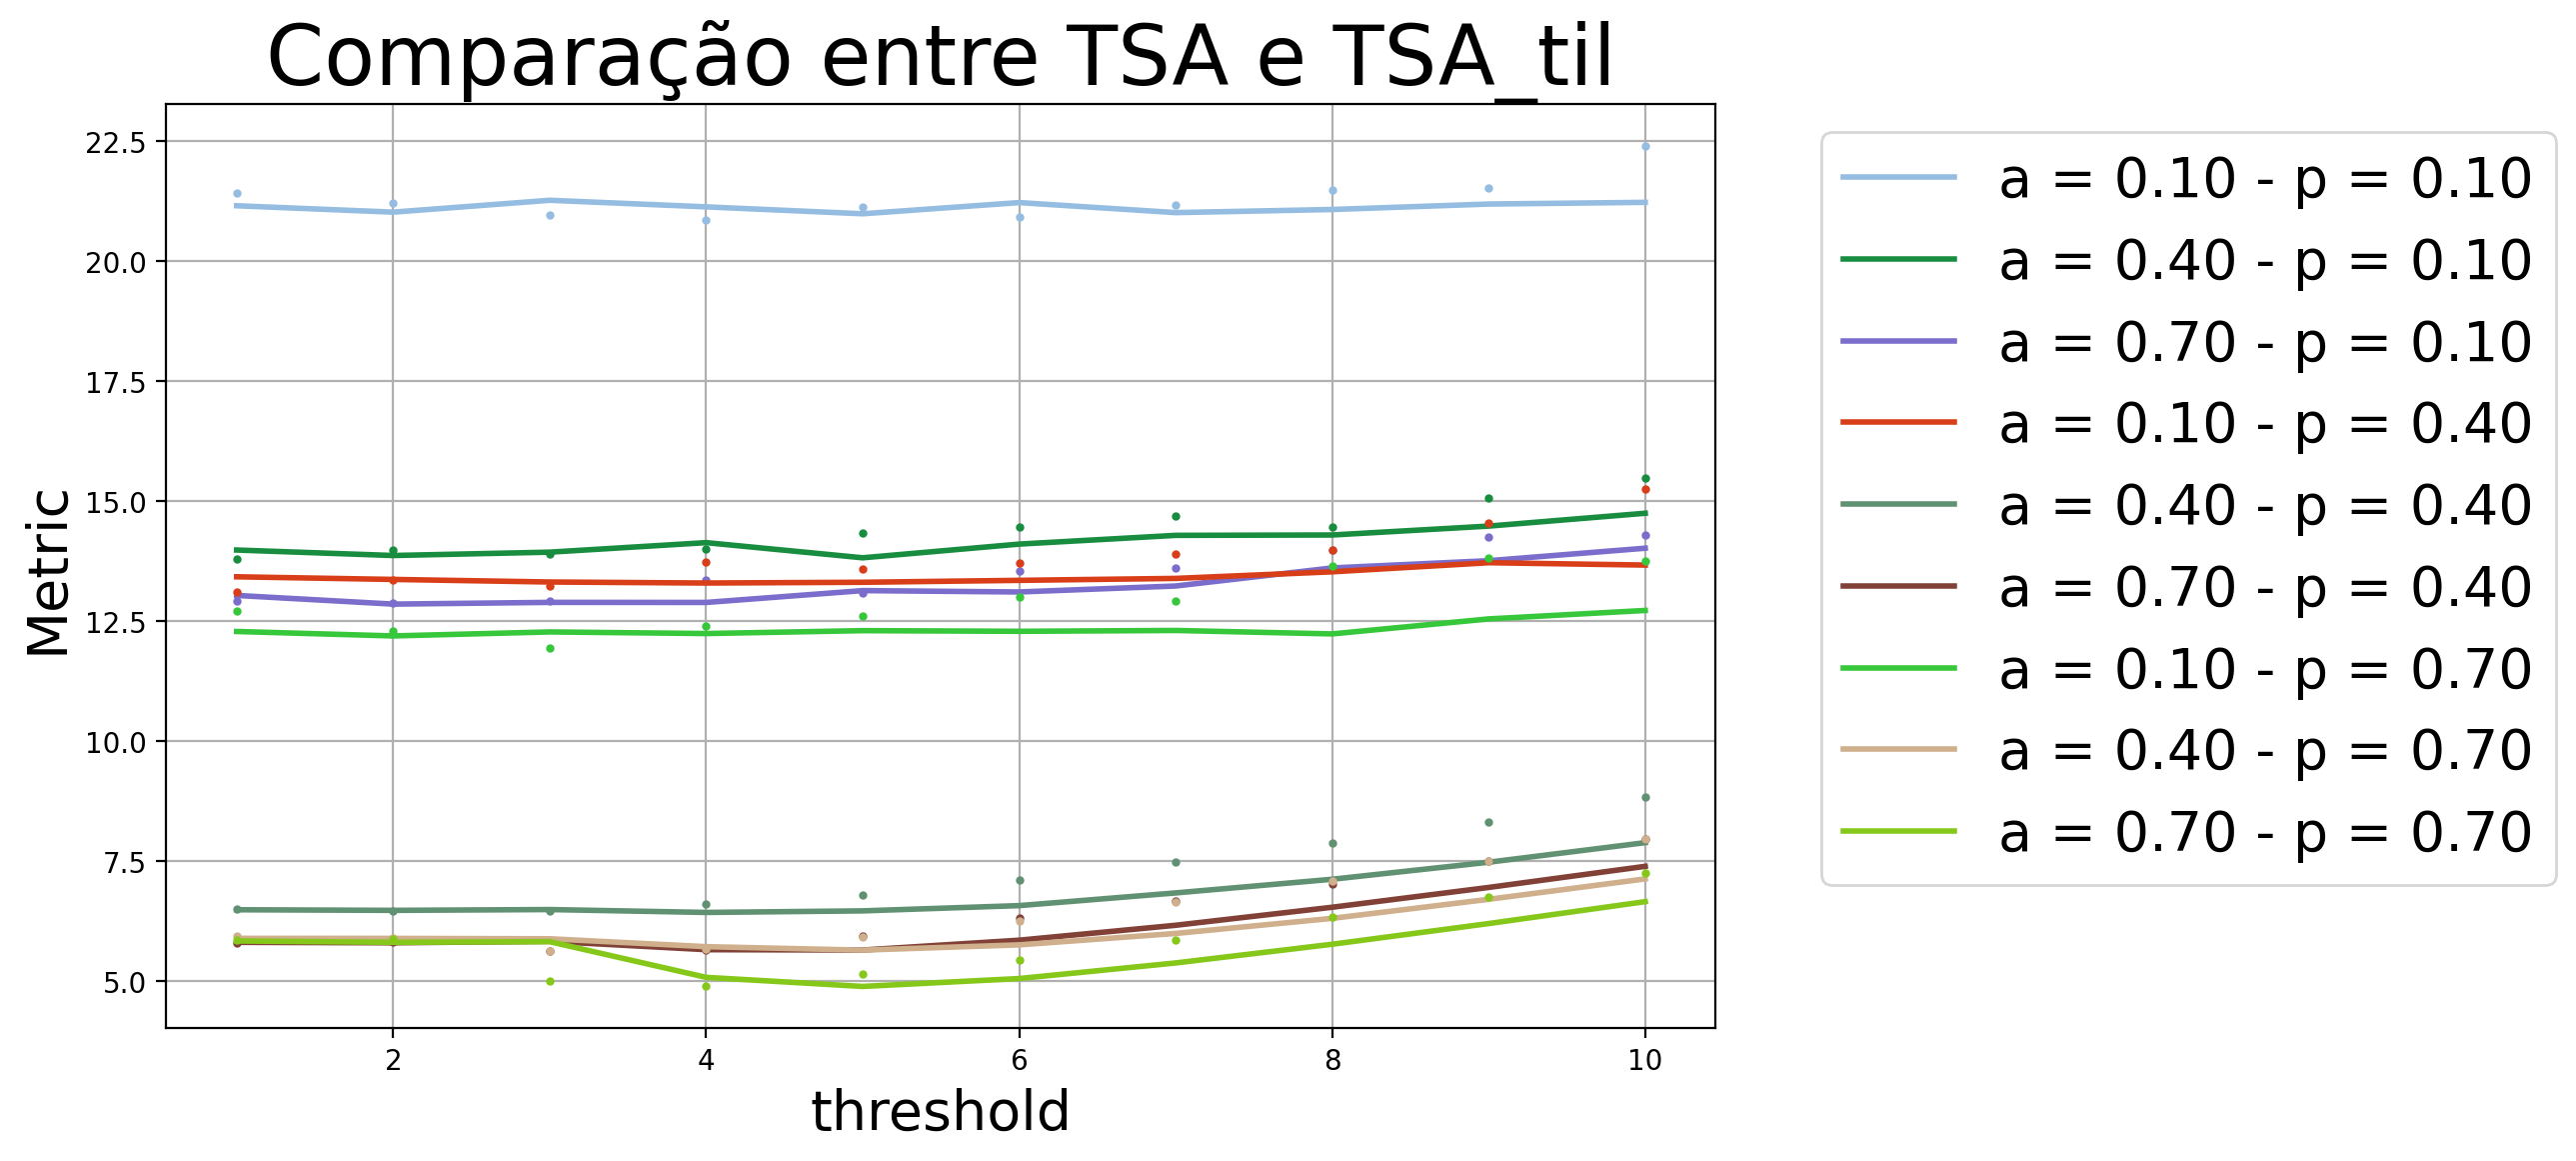

In [33]:
TSA_func = make_metric_func(AAoI_TSA)
TSA_til_func = make_metric_func(AAoI_TSA_til)


plt.figure(figsize=(10, 6))

threshold_domain = range(1, 11)
prob_domain = np.arange(0.1, 1, 0.3)
arr_domain = np.arange(0.1, 1, 0.3)
calc_TSA = lambda a, p: TSA_func(arrival_prob=a, send_prob=p, threshold=threshold_domain)
calc_TSA_til = lambda a, p: TSA_til_func(arrival_prob=a, send_prob=p, threshold=threshold_domain)
for p in prob_domain:
    for a in arr_domain:
        TSA_plot = calc_TSA(a, p)
        TSA_til_plot = calc_TSA_til(a, p)

        color = np.random.rand(3,)*0.9
        plt.plot(threshold_domain, TSA_plot,
                    label=f"a = {a:.2f} - p = {p:.2f}",
                    color=color, linestyle='-', lw=2)
        plt.plot(threshold_domain, TSA_til_plot, color=color,
                    linestyle='None', marker='o', markersize=2)
    
# otimização da métrica
plt.xlabel("threshold", fontsize=20)
plt.ylabel("Metric", fontsize=20)
# plt.ylim(10)
# plt.xlim(0, 1)
plt.title("Comparação entre TSA e TSA_til", fontsize=30)
plt.legend(fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [20]:
AAoI_PAoI_TSA_plinio_sim = simulate_metric_TSA(
    TSA_sim.AAoI_PAoI_plinio_sim,
    500000,
    "AAoI_PAoI_TSA_plinio_sim"
)

Dados salvos em 'data/AAoI_PAoI_TSA_plinio_sim.npy'.


In [36]:
AAoI_TSA_plinio_sim, PAoI_TSA_plinio_sim = np.load("data/AAoI_PAoI_TSA_plinio_sim.npy", allow_pickle=True)
AAoI_TSA, PAoI_TSA = np.load("data/TSA_AAoI_PAoI_sim.npy", allow_pickle=True)
AAoI_TSA_til, PAoI_TSA_til = np.load("data/TSA_AAoI_PAoI_til_sim.npy", allow_pickle=True)

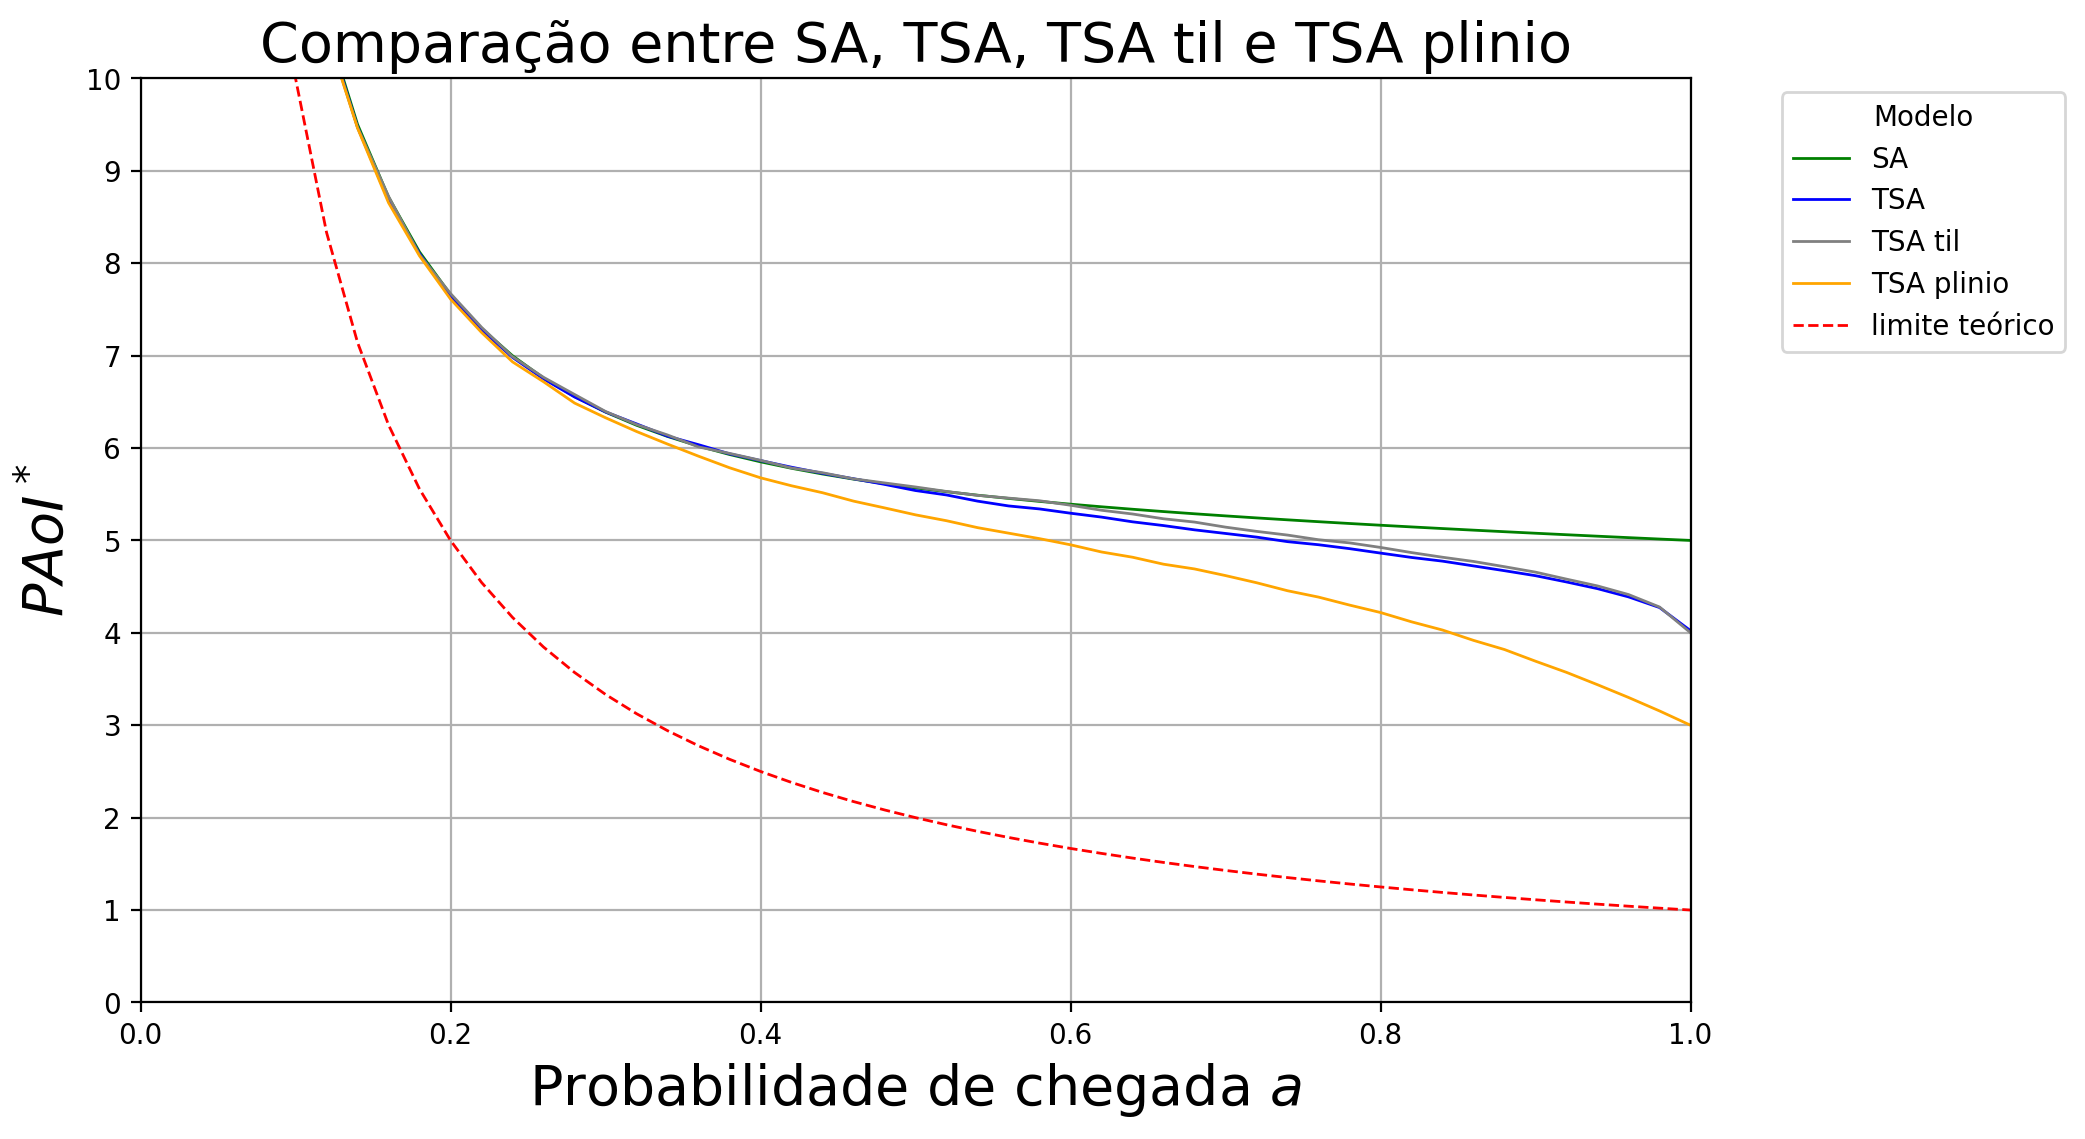

In [25]:
opt_PAoI = optimize_metric(make_metric_func(PAoI_expr))
opt_thr = optimize_metric(make_metric_func(thr), find_max=True)
opt_PAoI_TSA = optimize_metric_grid(make_metric_func(PAoI_TSA))
opt_PAoI_TSA_til = optimize_metric_grid(make_metric_func(PAoI_TSA_til))
opt_PAoI_TSA_plinio = optimize_metric_grid(make_metric_func(PAoI_TSA_plinio_sim))

limite_teorico_PAoI = np.vectorize(lambda a: 1/a)

plt.figure(figsize=(10, 6))
plt.plot(A_DOMAIN, opt_PAoI["metric_opt"],
         color='green', linestyle='-', lw=1, label="SA")
plt.plot(A_DOMAIN, opt_PAoI_TSA["metric_opt"],
         color='blue', linestyle='-', lw=1, label="TSA")
plt.plot(A_DOMAIN, opt_PAoI_TSA_til["metric_opt"],
         color='gray', linestyle='-', lw=1, label="TSA til")
plt.plot(A_DOMAIN, opt_PAoI_TSA_plinio["metric_opt"],
         color='orange', linestyle='-', lw=1, label="TSA plinio")
plt.plot(A_DOMAIN, limite_teorico_PAoI(A_DOMAIN),
color='red', linestyle='--', lw=1,  label='limite teórico')
plt.ylim(4, 6)
plt.xlim(0, 1)
plt.ylabel("$PAoI^*$", fontsize=20)
plt.xlabel("Probabilidade de chegada $a$", fontsize=20)
plt.legend(title = f"Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yticks(np.arange(0, 11, 1))
plt.title("Comparação entre SA, TSA, TSA til e TSA plinio", fontsize=20)
plt.show()
# Agora você pode plotar esses pontos vermelhos sobre o seu gráfico original

In [22]:
AAoI_SA_sim[49,:]

array([50.134838, 26.808636, 18.146328, 14.095986, 11.56929 ,  9.94652 ,
        8.725886,  7.876626,  7.364252,  6.735984,  6.279208,  5.980544,
        5.658814,  5.43998 ,  5.262212,  5.065002,  4.956868,  4.86117 ,
        4.737458,  4.663616,  4.612724,  4.562036,  4.548978,  4.49937 ,
        4.5206  ,  4.49737 ,  4.526668,  4.567018,  4.613562,  4.671824,
        4.745146,  4.847128,  4.951402,  5.12159 ,  5.246842,  5.429952,
        5.68481 ,  5.97798 ,  6.342544,  6.774024,  7.285084,  7.92488 ,
        8.796888, 10.008108, 11.529918, 14.11965 , 18.156156, 26.845406,
       50.642278])

In [23]:
AAoI_TSA_sim[49,:,0]

array([52.301168, 27.321892, 19.286344, 14.918604, 12.616802, 11.068608,
        9.80007 ,  8.944174,  8.227022,  7.769252,  7.32411 ,  6.976986,
        6.712684,  6.460828,  6.248696,  6.067192,  5.990788,  5.82553 ,
        5.743386,  5.675876,  5.602394,  5.548614,  5.5323  ,  5.526326,
        5.4965  ,  5.500844,  5.522362,  5.564172,  5.614658,  5.674276,
        5.716838,  5.831246,  5.97482 ,  6.121478,  6.24431 ,  6.455034,
        6.7021  ,  6.989848,  7.306328,  7.725914,  8.277708,  8.992692,
        9.816406, 10.966408, 12.645976, 15.054436, 19.412852, 27.79259 ,
       51.290456])

In [28]:
TSA_sim.AAoI_PAoI_sim(arrival_prob=1, send_prob=0.5, threshold=1, time=10)

(2.2, 2.6666666666666665)

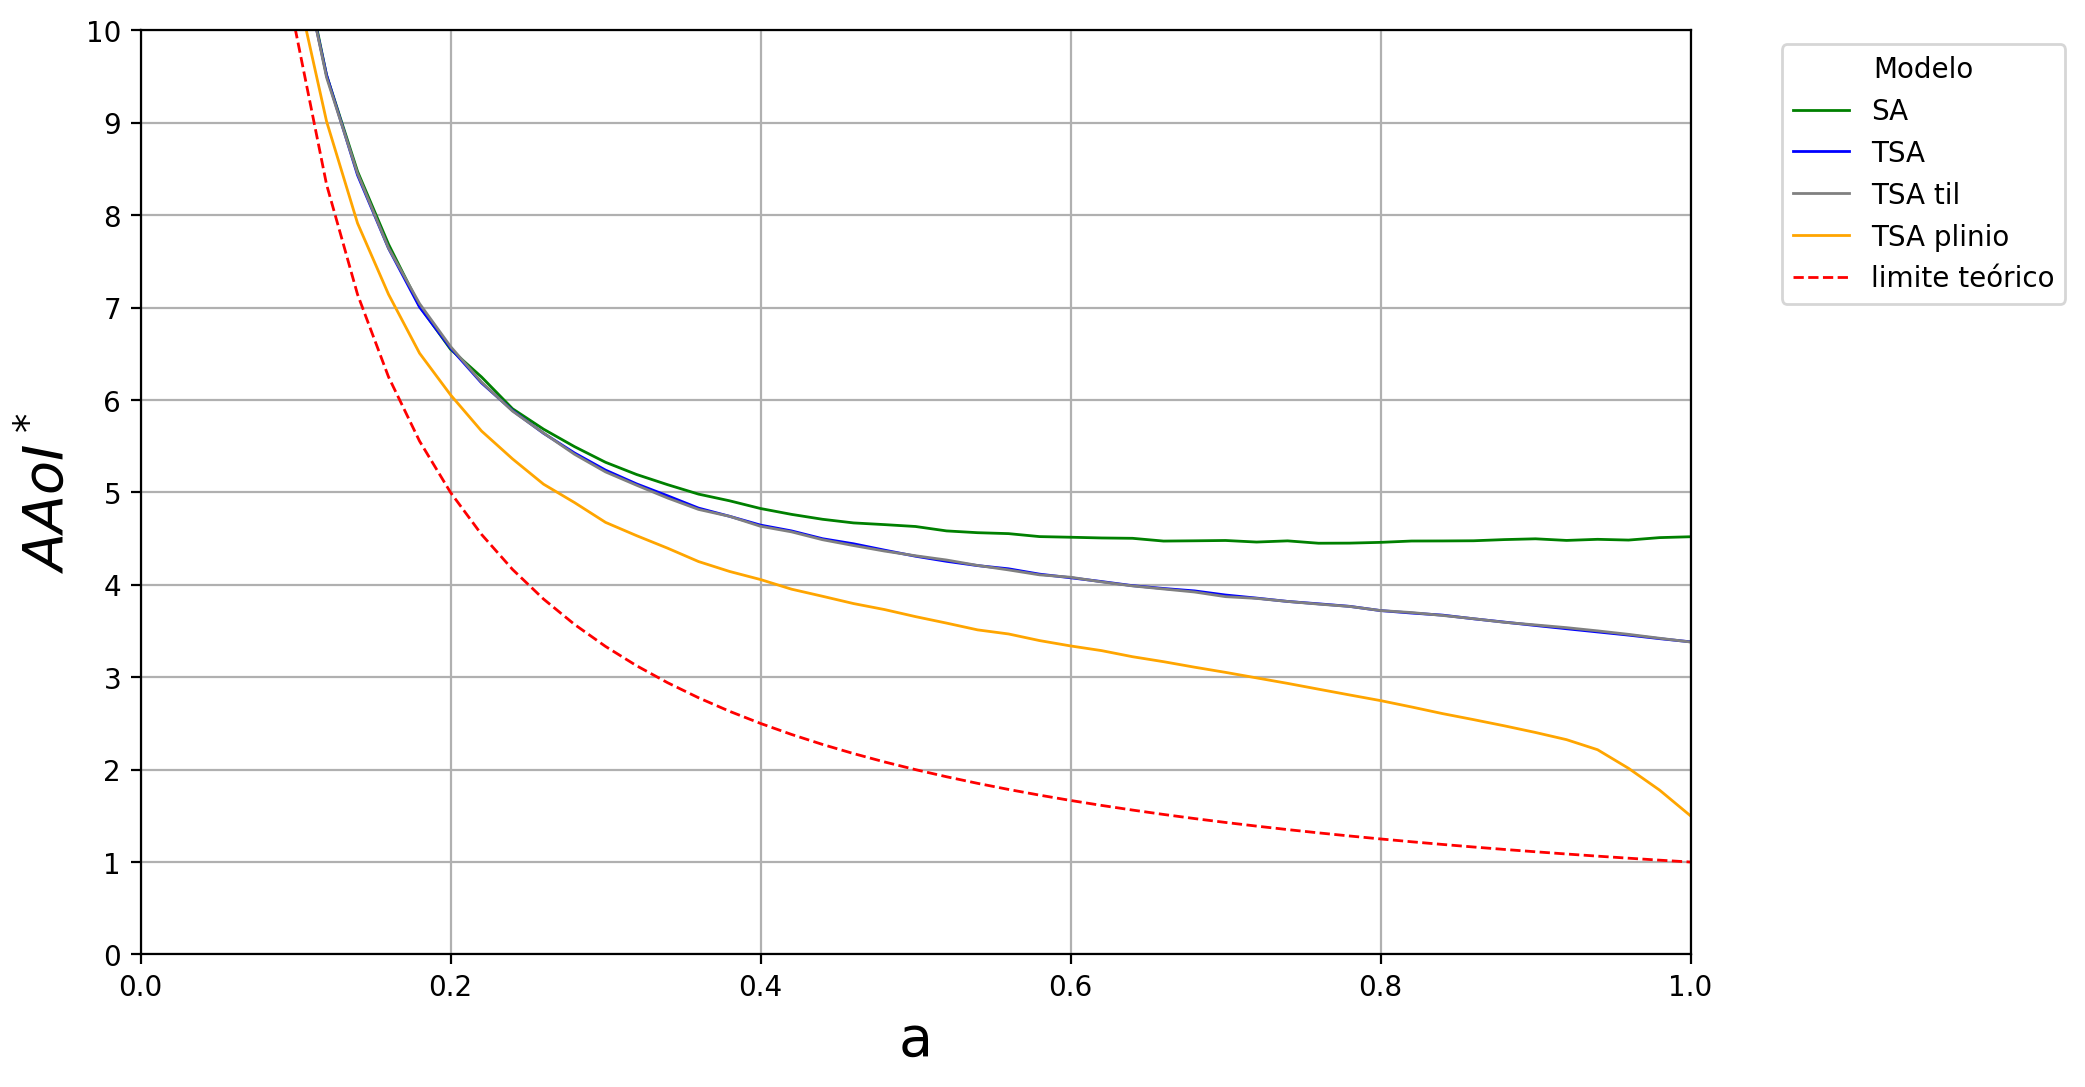

In [44]:
AAoI_SA_sim = np.load("data/AAoI_sim_data.npy")
AAoI_TSA_sim = np.load("data/TSA_AAoI_PAoI_sim.npy", allow_pickle=True)[0]
AAoI_TSA_til_sim = np.load("data/TSA_AAoI_PAoI_til_sim.npy", allow_pickle=True)[0]

AAoI_SA_opt = optimize_metric(make_metric_func(AAoI_SA_sim))
AAoI_TSA_opt = optimize_metric_grid(make_metric_func(AAoI_TSA_sim))
AAoI_TSA_til_opt = optimize_metric_grid(make_metric_func(AAoI_TSA_til_sim))
AAoI_TSA_plinio_opt = optimize_metric_grid(make_metric_func(AAoI_TSA_plinio_sim))

limite_teorico_AAoI = np.vectorize(lambda a: 1/a)


AAoI_TSA_opt["metric_opt"] = [x - 1 for x in AAoI_TSA_opt["metric_opt"]]
AAoI_TSA_til_opt["metric_opt"] = [x - 0.5 for x in AAoI_TSA_til_opt["metric_opt"]]
AAoI_TSA_plinio_opt["metric_opt"] = [x - 1 for x in AAoI_TSA_plinio_opt["metric_opt"]]


plt.figure(figsize=(10, 6))
plt.plot(A_DOMAIN, AAoI_SA_opt["metric_opt"],
         color='green', linestyle='-', lw=1, label="SA")
plt.plot(A_DOMAIN, AAoI_TSA_opt["metric_opt"],
         color='blue', linestyle='-', lw=1, label="TSA")
plt.plot(A_DOMAIN, AAoI_TSA_til_opt["metric_opt"],
         color='gray', linestyle='-', lw=1, label="TSA til")
plt.plot(A_DOMAIN, AAoI_TSA_plinio_opt["metric_opt"],
         color='orange', linestyle='-', lw=1, label="TSA plinio")
plt.plot(A_DOMAIN, limite_teorico_AAoI(A_DOMAIN),
         color='red', linestyle='--', lw=1, label="limite teórico")
plt.ylim(4, 6)
plt.xlim(0, 1)
plt.ylabel("$AAoI^*$", fontsize=20)
plt.xlabel("a", fontsize=20)
plt.legend(title = f"Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yticks(np.arange(0, 11, 1))
plt.show()

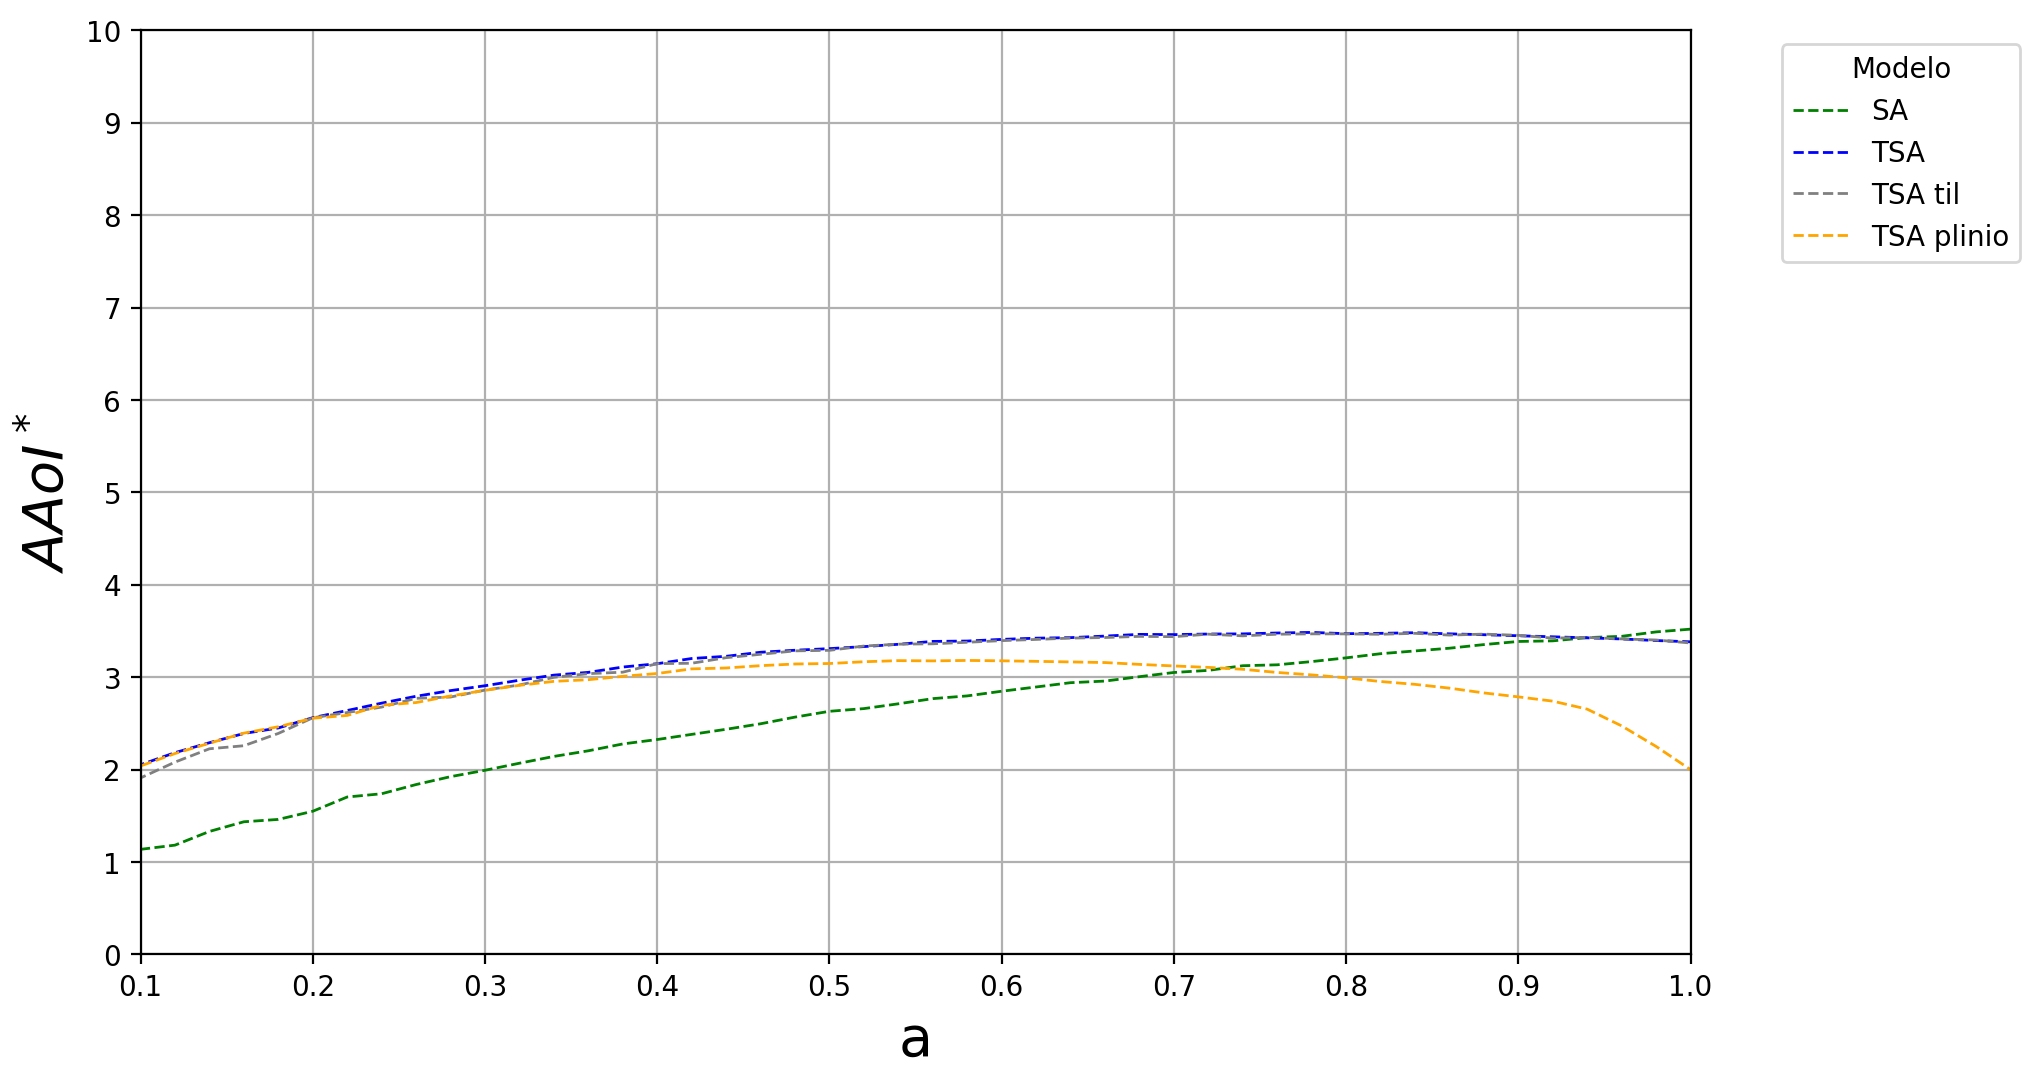

In [76]:
# diferença

AAoI_SA_diff = AAoI_SA_opt["metric_opt"] - limite_teorico_AAoI(A_DOMAIN)
AAoI_TSA_diff = AAoI_TSA_opt["metric_opt"] - limite_teorico_AAoI(A_DOMAIN)
AAoI_TSA_til_diff = AAoI_TSA_til_opt["metric_opt"] - limite_teorico_AAoI(A_DOMAIN)
AAoI_TSA_plinio_diff = AAoI_TSA_plinio_opt["metric_opt"] - limite_teorico_AAoI(A_DOMAIN)

plt.figure(figsize=(10, 6))
plt.plot(A_DOMAIN, AAoI_SA_diff,
         color='green', linestyle='--', lw=1, label="SA")
plt.plot(A_DOMAIN, AAoI_TSA_diff,
         color='blue', linestyle='--', lw=1, label="TSA")
plt.plot(A_DOMAIN, AAoI_TSA_til_diff,
         color='gray', linestyle='--', lw=1, label="TSA til")
plt.plot(A_DOMAIN, AAoI_TSA_plinio_diff,
         color='orange', linestyle='--', lw=1, label="TSA plinio")
plt.ylim(4, 6)
plt.xlim(0.1, 1)
plt.ylabel("$AAoI^*$", fontsize=20)
plt.xlabel("a", fontsize=20)
plt.legend(title = f"Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yticks(np.arange(0, 11, 1))
plt.show()

# 3 nós

In [83]:
import src.sim_three_nodes as sim3

In [101]:
AAoI_PAoI_sim_3 = simulate_metric_TSA(
    sim3.AAoI_PAoI_hom_sim,
    500000,
    "AAoI_PAoI_sim_3"
)

Iniciando simulação sequencial...


Progresso (a):   0%|          | 0/50 [00:00<?, ?it/s]

Dados salvos em 'data/AAoI_PAoI_sim_3.npy'.


In [102]:
AAoI_PAoI_sim_til_3 = simulate_metric_TSA(
    sim3.AAoI_PAoI_til_sim,
    500000,
    "AAoI_PAoI_sim_til_3"
)

Iniciando simulação sequencial...


Progresso (a):   0%|          | 0/50 [00:00<?, ?it/s]

Dados salvos em 'data/AAoI_PAoI_sim_til_3.npy'.


In [100]:
AAoI_PAoI_sim_plinio_3 = simulate_metric_TSA(
    sim3.AAoI_PAoI_plinio_sim,
    500000,
    "AAoI_PAoI_sim_plinio_3"
)

Iniciando simulação sequencial...


Progresso (a):   0%|          | 0/50 [00:00<?, ?it/s]

Dados salvos em 'data/AAoI_PAoI_sim_plinio_3.npy'.


In [85]:
AAoI_sim3, PAoI_sim3 = np.load("data/AAoI_PAoI_sim_3.npy", allow_pickle=True).item().values()
AAoI_til_sim3, PAoI_til_sim3 = np.load("data/AAoI_PAoI_sim_til_3.npy", allow_pickle=True).item().values()
AAoI_plinio_sim3, PAoI_plinio_sim3 = np.load("data/AAoI_PAoI_sim_plinio_3.npy", allow_pickle=True).item().values()

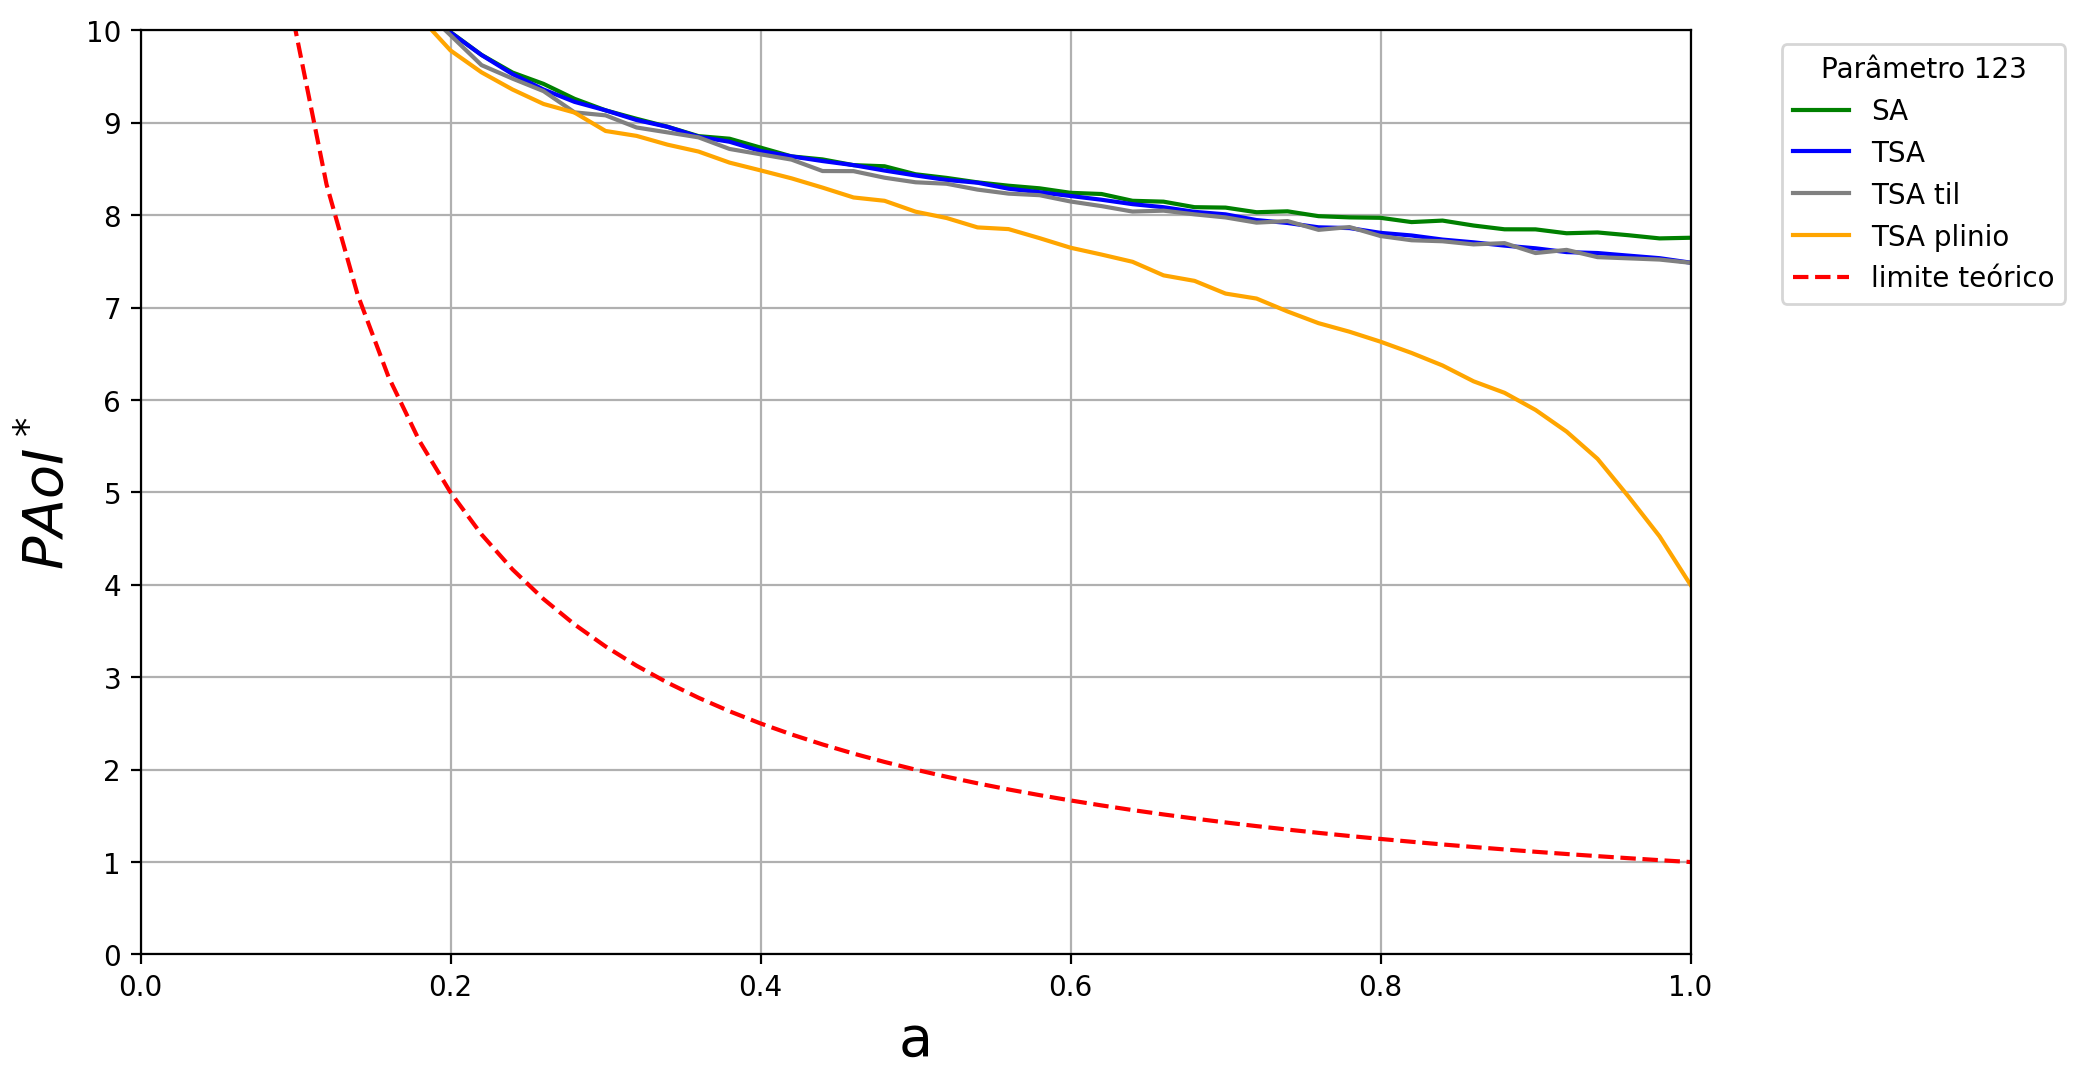

In [142]:
opt_PAoI3_SA = optimize_metric(make_metric_func(PAoI_sim3[:,:,0]))
opt_PAoI3_TSA = optimize_metric_grid(make_metric_func(PAoI_sim3))
opt_PAoI3_TSA_til = optimize_metric_grid(make_metric_func(PAoI_til_sim3))
opt_PAoI3_TSA_plinio = optimize_metric_grid(make_metric_func(PAoI_plinio_sim3))

# opt_PAoI_TSA = optimize_metric_grid(make_metric_func(PAoI_TSA))

limite_teorico_PAoI = np.vectorize(lambda a: 1/a)

plt.figure(figsize=(10, 6))
# plt.plot(A_DOMAIN, opt_PAoI_TSA["metric_opt"],
        #  color='blue', linestyle='--', lw=2, label="TSA")
plt.plot(A_DOMAIN, opt_PAoI3_SA["metric_opt"],
         color='green', linestyle='-', lw=1.5, label="SA")
plt.plot(A_DOMAIN, opt_PAoI3_TSA["metric_opt"],
         color='blue', linestyle='-', lw=1.5, label="TSA")
plt.plot(A_DOMAIN, opt_PAoI3_TSA_til["metric_opt"],
         color='gray', linestyle='-', lw=1.5, label="TSA til")
plt.plot(A_DOMAIN, opt_PAoI3_TSA_plinio["metric_opt"],
         color='orange', linestyle='-', lw=1.5, label="TSA plinio")
plt.plot(A_DOMAIN, limite_teorico_PAoI(A_DOMAIN),
        color='red', linestyle='--', lw=1.5,  label='limite teórico')
plt.ylim(4, 6)
plt.xlim(0, 1)
plt.ylabel("$PAoI^*$", fontsize=20)
plt.xlabel("a", fontsize=20)
plt.legend(title = f"Parâmetro {123}", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yticks(np.arange(0, 11, 1))
plt.show()

In [142]:
np.shape(AAoI_sim3[:,:])

(50, 49, 10)

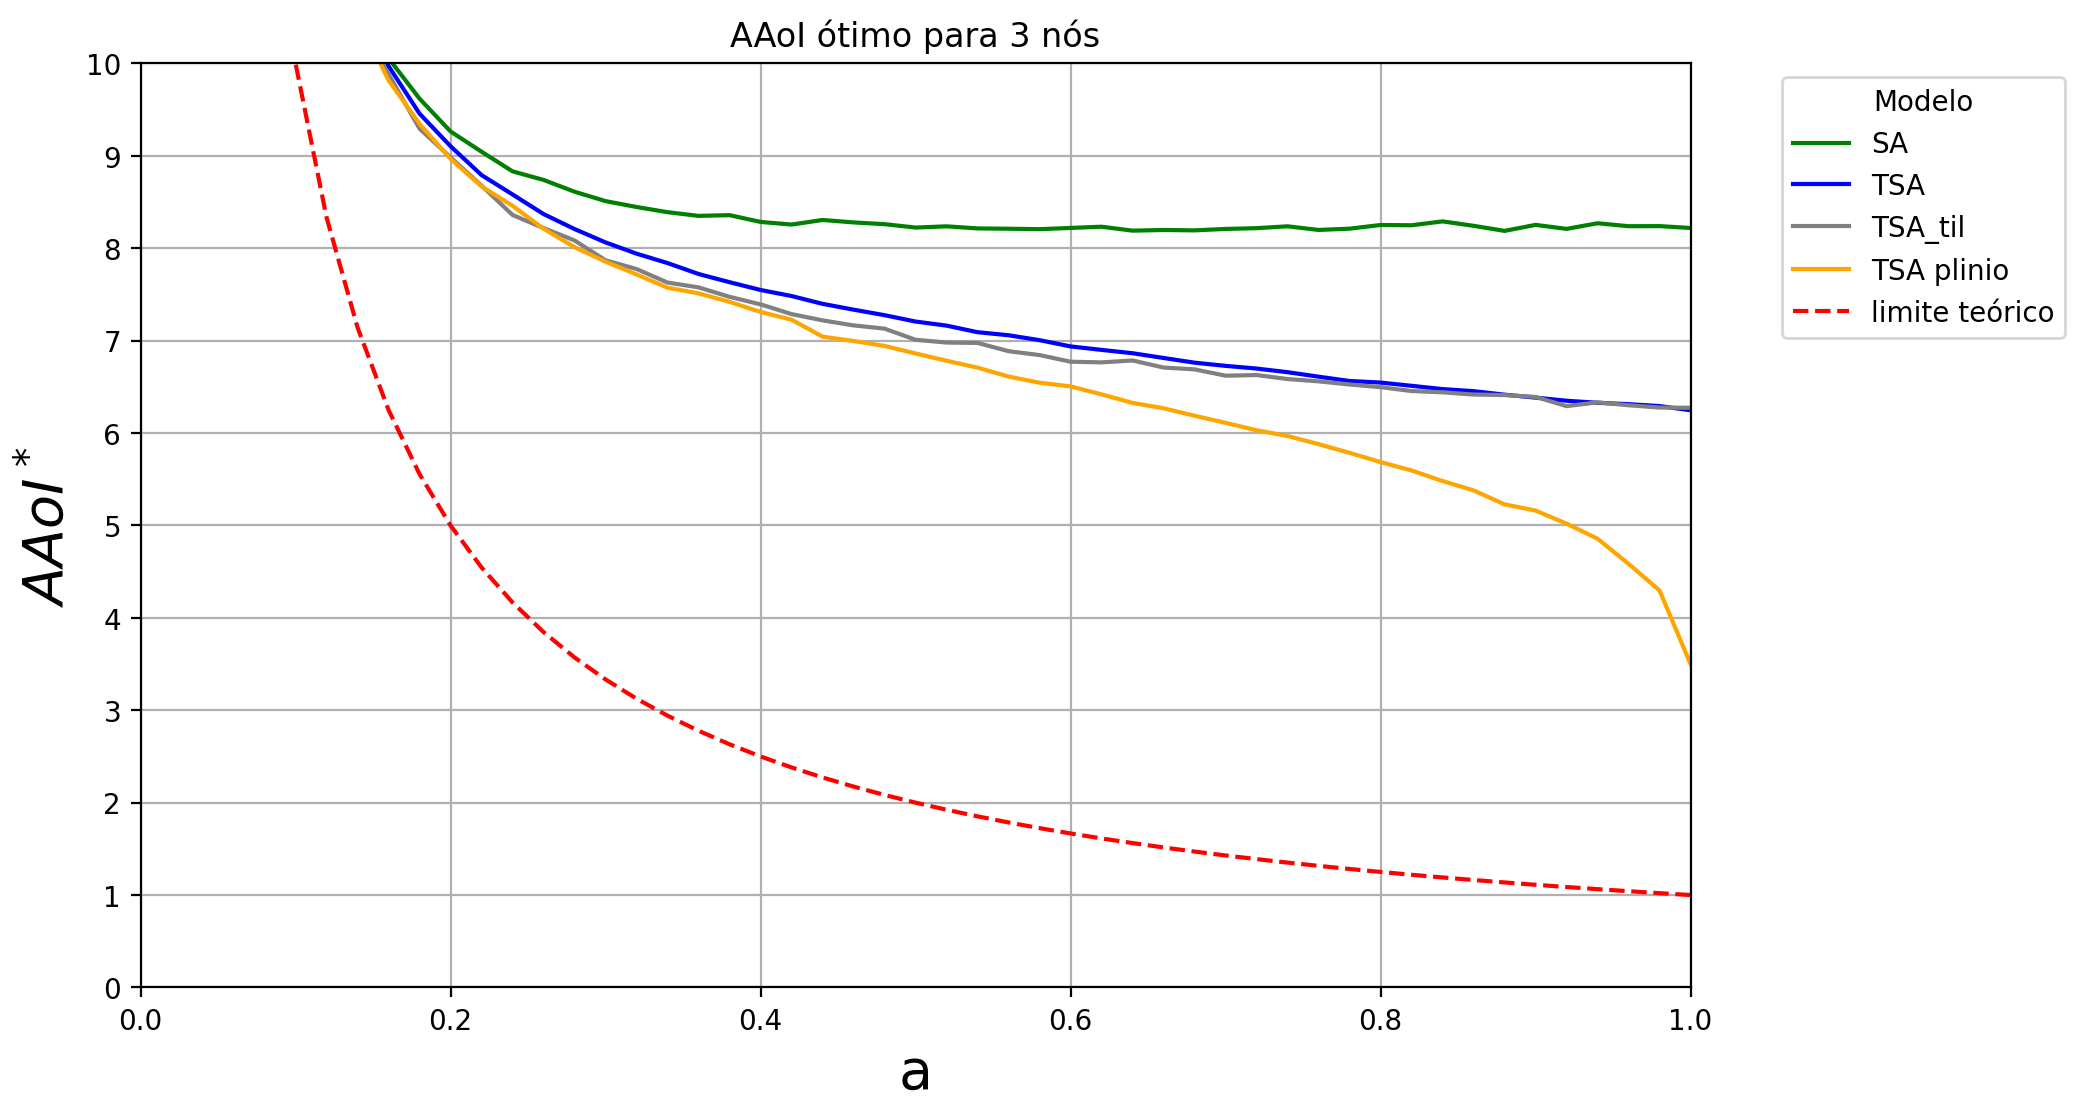

In [143]:
# AAoI_PAoI_sim_3 = np.load("data/AAoI_PAoI_sim_3.npy", allow_pickle=True).item()
# AAoI_sim3, PAoI_sim3 = AAoI_PAoI_sim_3.values()

opt_AAoI3_SA = optimize_metric(make_metric_func(AAoI_sim3[:,:,0]))
opt_AAoI3_TSA = optimize_metric_grid(make_metric_func(AAoI_sim3))
opt_AAoI3_TSA_til = optimize_metric_grid(make_metric_func(AAoI_til_sim3))
opt_AAoI3_TSA_plinio = optimize_metric_grid(make_metric_func(AAoI_plinio_sim3))

limite_teorico_AAoI = np.vectorize(lambda a: 1/a)

plt.figure(figsize=(10, 6))
plt.plot(A_DOMAIN, opt_AAoI3_SA["metric_opt"],
         color='green', linestyle='-', lw=1.5, label="SA")
plt.plot(A_DOMAIN, opt_AAoI3_TSA["metric_opt"],
         color='blue', linestyle='-', lw=1.5, label="TSA")
plt.plot(A_DOMAIN, opt_AAoI3_TSA_til["metric_opt"],
         color='gray', linestyle='-', lw=1.5, label="TSA_til")
plt.plot(A_DOMAIN, opt_AAoI3_TSA_plinio["metric_opt"],
         color='orange', linestyle='-', lw=1.5, label="TSA plinio")
plt.plot(A_DOMAIN, limite_teorico_AAoI(A_DOMAIN),
color='red', linestyle='--', lw=1.5,  label='limite teórico')
plt.ylim(4, 6)
plt.xlim(0, 1)
plt.ylabel("$AAoI^*$", fontsize=20)
plt.xlabel("a", fontsize=20)
plt.legend(title = f"Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.title("AAoI ótimo para 3 nós")
plt.yticks(np.arange(0, 11, 1))
plt.show()

In [ ]:
AAoI_SA_sim = np.load("data/AAoI_sim_data.npy")
AAoI_TSA_sim = np.load("data/TSA_AAoI_PAoI_sim.npy")[0]
AAoI_TSA_til_sim = np.load("data/TSA_AAoI_PAoI_til_sim.npy")[0]

opt_AAoI = optimize_metric(make_metric_func(AAoI_SA_sim))
opt_PAoI3 = optimize_metric(make_metric_func(AAoI_PAoI_sim["AAoI"]))
# opt_PAoI_TSA = optimize_metric_grid(make_metric_func(PAoI_TSA))
# opt_PAoI_TSA_til = optimize_metric_grid(make_metric_func(PAoI_TSA_til))

limite_teorico_PAoI = np.vectorize(lambda a: 1/a + 1)

plt.figure(figsize=(10, 6))
# plt.plot(A_DOMAIN, opt_PAoI_TSA["metric_opt"],
        #  color='blue', linestyle='--', lw=2, label="TSA")
# plt.plot(A_DOMAIN, opt_PAoI_TSA_til["metric_opt"],
        #  color='gray', linestyle='--', lw=2, label="TSA til")
plt.plot(A_DOMAIN, opt_PAoI["metric_opt"],
         color='green', linestyle='--', lw=1.5, label="SA")
plt.plot(A_DOMAIN, opt_PAoI3["metric_opt"],
         color='blue', linestyle='--', lw=1.5, label="SA3")
plt.plot(A_DOMAIN, limite_teorico_PAoI(A_DOMAIN),
color='red', linestyle='--', lw=1.5,  label='limite teórico')
plt.ylim(4, 6)
plt.xlim(0, 1)
plt.ylabel("$PAoI^*$", fontsize=20)
plt.xlabel("a", fontsize=20)
plt.legend(title = f"Parâmetro {123}", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yticks(np.arange(0, 21, 1))
plt.show()

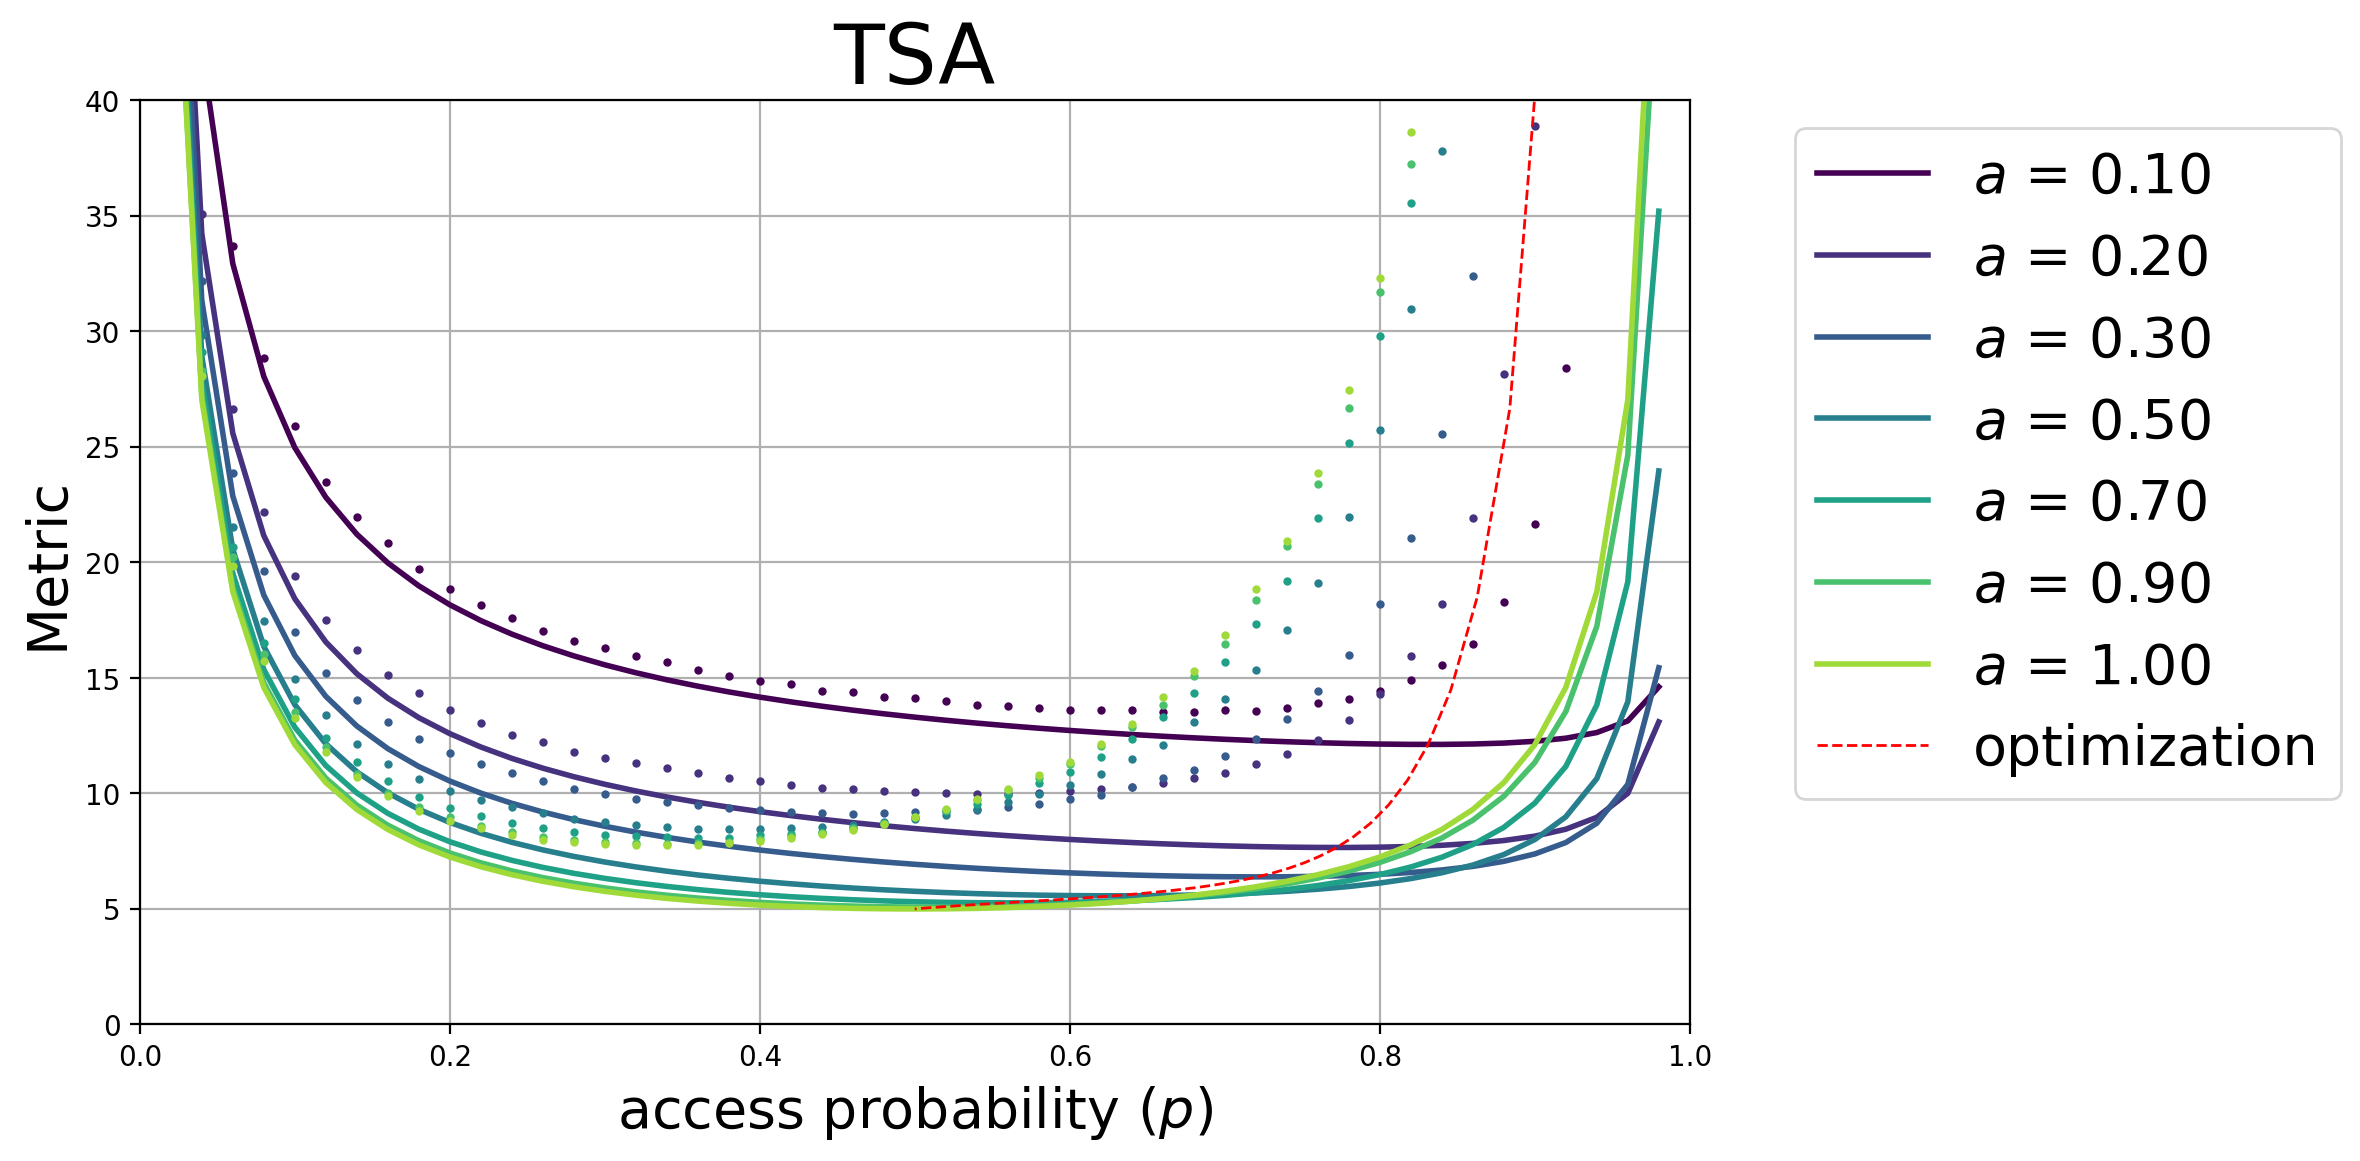

In [37]:
compare_metric_plot(
    analytical_expr=PAoI_expr,
    simulation_data=PAoI_sim3,
    title="TSA",
    yrange=(0,40)
)

In [68]:
Hetero_TSA_teste = simulate_metric(
    TSA_sim.AAoI_PAoI_sim,
    100000,
    "TSA_teste",
    "numpy"
)

KeyboardInterrupt: 

In [40]:
def arr_prob(gamma, a):
    sum = 0
    for i in range(0, gamma):
        sum += (1-a)**i
    print(1-(1-a)**(gamma-1))
    return a*sum

In [44]:
1-(1-0.1)**(1-1)

0.0

In [43]:
arr_prob(1, 0.1)

0.0


0.1

## Analítico 3 nós

In [ ]:
# Fazer ou não?

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

thr = sp.factor(pi01*p + pi11*p*(1-p))



# L_up

q0, q1 = sp.symbols('q0 q1', real=True)

# 1. Definições auxiliares do Slotted ALOHA (2 nós)
s0 = p               # Sucesso do nó 1 se nó 2 está vazio
s1 = p * (1 - p)     # Sucesso do nó 1 se nó 2 está cheio
s_neighbor = p * (1 - p)  # Sucesso do nó 2 se nó 1 está cheio (simetria)

# 2. Montando o sistema de equações
# q0 = s0 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# Se não houve chegada 'a' no nó 1, o pacote atual continua.
# Se não houve sucesso 's0', ele permanece no buffer.
eq1 = sp.Eq(q0, s0 + (1 - a) * (1 - p) * ((1 - a) * q0 + a * q1))

# q1 = s1 + (Prob de não sair nem ser substituído) * (Prob de transição de estado)
# No estado 1, o vizinho pode ter sucesso (s_neighbor) e não chegar pacote novo para ele (1-a)
cont_prob_1 = (1 - a) * (1 - p * (1 - p))
trans_to_q0 = p * (1 - p) * (1 - a)
eq2 = sp.Eq(q1, p * (1 - p) + cont_prob_1 * (trans_to_q0 * q0 + (1 - trans_to_q0) * q1))

# 3. Resolvendo o sistema
solucao = sp.solve((eq1, eq2), (q0, q1))

# Simplificando os resultados
q0_expr = sp.simplify(solucao[q0])
q1_expr = sp.simplify(solucao[q1])

L_up_expr = sp.simplify(pi10*q0_expr + pi11*q1_expr)


# PAoI e AAoI

PAoI_expr = sp.simplify( (L_up_expr + 1) / thr)

# Teste

In [43]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm  # O '.auto' adapta a barra caso use Jupyter Notebook

def simulate_metric1(metric_func, time: int, name: str = ""):
    """
    Simulate a given metric function over a grid of arrival and sending
    probabilities.
    ...
    """
    print("Iniciando simulação sequencial...")
    
    # Pré-aloca DUAS matrizes de resultados
    sim_data_aaoi = np.zeros((len(A_DOMAIN), len(P_DOMAIN)))
    sim_data_paoi = np.zeros((len(A_DOMAIN), len(P_DOMAIN)))
    
    for i, a in enumerate(tqdm(A_DOMAIN, desc="Progresso (a)")):
        for j, p in enumerate(P_DOMAIN):
            # Desempacota os dois retornos da simulação
            aaoi, paoi = metric_func(arrival_prob=a, send_prob=p, time=time)
            
            sim_data_aaoi[i, j] = aaoi
            sim_data_paoi[i, j] = paoi
            
    # Você pode retornar um dicionário para não perder nada
    simulated_data = {"AAoI": sim_data_aaoi, "PAoI": sim_data_paoi}

    # Salva no google drive, se for passado o nome
    if name != "":
        # Sugestão: garantir que o diretório 'data' exista antes de salvar
        import os
        os.makedirs('data', exist_ok=True)
        
        file_path = f'data/{name}.npy'
        np.save(file_path, simulated_data)
        print(f"Dados salvos em '{file_path}'.")

    return simulated_data

In [42]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm  # O '.auto' adapta a barra caso use Jupyter Notebook

def simulate_metric_TSA(metric_func, time: int, name: str = ""):
    """
    Simulate a given metric function over a grid of arrival and sending
    probabilities.
    ...
    """
    print("Iniciando simulação sequencial...")
    
    # Pré-aloca DUAS matrizes de resultados
    sim_data_aaoi = np.zeros((len(A_DOMAIN), len(P_DOMAIN), len(T_DOMAIN)))
    sim_data_paoi = np.zeros((len(A_DOMAIN), len(P_DOMAIN), len(T_DOMAIN)))
    
    for i, a in enumerate(tqdm(A_DOMAIN, desc="Progresso (a)")):
        for j, p in enumerate(P_DOMAIN):
            for k, gamma in enumerate(T_DOMAIN):
                # Desempacota os dois retornos da simulação
                aaoi, paoi = metric_func(arrival_prob=a, send_prob=p, threshold=gamma, time=time)
                
                sim_data_aaoi[i, j, k] = aaoi
                sim_data_paoi[i, j, k] = paoi
            
    # Você pode retornar um dicionário para não perder nada
    simulated_data = {"AAoI": sim_data_aaoi, "PAoI": sim_data_paoi}

    # Salva no google drive, se for passado o nome
    if name != "":
        # Sugestão: garantir que o diretório 'data' exista antes de salvar
        import os
        os.makedirs('data', exist_ok=True)
        
        file_path = f'data/{name}.npy'
        np.save(file_path, simulated_data)
        print(f"Dados salvos em '{file_path}'.")

    return simulated_data